In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import xarray as xr
import matplotlib.ticker as ticker


# Read EP flux variable = -($\overline{u'v'}$)j + (${f0 \over \overline{\theta_p}}$ $\overline{v'\theta'}$) k

In [2]:
# import numpy as np
# import dask.array as da
# from dask.diagnostics import ProgressBar

# class AtmosphericDiagnostics:
#     """
#     Perform general atmospheric diagnostics including:
#     - Anomalies
#     - Eddy Momentum Flux (EMF)
#     - Eddy Heat Flux (EHF)
#     - Meridional EMF gradient (dEMF/dy)
#     """

#     def __init__(self, u, v, t, p, z, lat=None, lon=None):
#         """
#         Parameters:
#         - u, v, t, p: Arrays (NumPy or Dask) of shape (time, z, y, x)
#         - lat, lon: Optional 1D arrays for latitude and longitude
#         """
#         self.u = u
#         self.v = v
#         self.t = t
#         self.p = p
#         self.z = z

#         # constant
#         self.g = 9.81

#         self.time_dim, self.z_dim, self.y_dim, self.x_dim = u.shape
#         self.lat = lat if lat is not None else np.linspace(-90, 90, self.y_dim)
#         self.lon = lon if lon is not None else np.linspace(0, 360, self.x_dim)

#     @staticmethod
#     def anomaly(data, axis=-1):
#         """Compute the anomaly by subtracting mean along axis."""
#         mean = np.mean(data, axis=axis, keepdims=True)
#         return data - mean

#     @staticmethod
#     def compute_if_dask(arr):
#         """Compute the result if it's a Dask array."""
#         return arr.compute() if isinstance(arr, da.Array) else arr

#     @staticmethod
#     def EMF_dask(u, v, axis=-1):
#         """Eddy Momentum Flux: u'v' (Dask-compatible)."""
#         u_prime = u - u.mean(axis=axis, keepdims=True)
#         v_prime = v - v.mean(axis=axis, keepdims=True)
#         return u_prime * v_prime
        
#     # @staticmethod    
#     def cal_theta(self):
#         """
#         Compute potential temperature θ = T * (p0 / p)^(R/Cp) using self.t and self.p
    
#         Returns:
#         - theta: potential temperature [K], shape same as self.t
#         """
#         Rd, Cp = 287.0, 1004.0
#         exponent = Rd / Cp
#         # p1d = np.mean(self.p, axis=(0,2,3))
#         theta = self.t * (100000 / self.p) ** exponent
#         return theta

        
#     def EHF_dask(self, t, p, v, axis=-1):
#         theta = self.cal_theta()  
#         theta_mean = theta.mean(axis=axis, keepdims=True)
#         theta_prime = theta - theta_mean
    
#         v_prime = v - v.mean(axis=axis, keepdims=True)
#         # b = (theta_prime / theta_mean) * self.g
#         # b_prime = b - b.mean(axis=axis, keepdims=True)
    
#         return v_prime * theta_prime
#         # return v_prime * b
        

#     def dEMF_dy(self, emf, use_dask=True, progress=True, chunks=(10, 20, 64, 128)):
#         """
#         Efficient + accurate meridional gradient of EMF (∂(u'v')/∂y) with Dask support.
    
#         Parameters:
#         - emf: Array (time, z, y, x), either NumPy or Dask
#         - use_dask: If True, compute using Dask (lazy until .compute())
#         - progress: If True and use_dask is True, show progress bar
#         - chunks: Tuple to use if converting NumPy array to Dask
    
#         Returns:
#         - dEMF_dy: NumPy array if computed, or Dask array if lazy
#         """
#         # Ensure emf is a Dask array
#         emf_dask = da.from_array(emf, chunks=chunks) if not isinstance(emf, da.Array) else emf
    
#         # Compute dy between latitudes in meters
#         R = 6.371e6
#         lat_rad = np.radians(self.lat)
#         dy = np.gradient(lat_rad) * R  # shape (y,)
#         dy_dask = da.from_array(dy, chunks=(chunks[2],))
#         dy_broadcast = dy_dask[None, None, :, None]  # shape (1, 1, y, 1)
    
#         # Compute meridional gradient using Dask
#         d_emf_dy = da.gradient(emf_dask, axis=2) / dy_broadcast
    
#         if use_dask:
#             if progress:
#                 from dask.diagnostics import ProgressBar
#                 print("dEMF_dy progress:")
#                 with ProgressBar():
#                     return d_emf_dy.compute()
#             else:
#                 return d_emf_dy  # Lazy result
#         else:
#             # Fallback to NumPy gradient
#             emf_np = emf.compute() if isinstance(emf, da.Array) else emf
#             dy_np = dy[np.newaxis, :, np.newaxis]
#             return np.gradient(emf_np, axis=2) / dy_np

#     def run_emf_ehf(self, chunks=(10, 20, 64, 128), progress=True):
#         """
#         Convert inputs to Dask, compute EMF and EHF with optional progress bar.
#         Returns computed NumPy arrays: emf, ehf
#         """
#         # Convert to Dask arrays if not already
#         u_dask = da.from_array(self.u, chunks=chunks) if not isinstance(self.u, da.Array) else self.u
#         v_dask = da.from_array(self.v, chunks=chunks) if not isinstance(self.v, da.Array) else self.v
#         t_dask = da.from_array(self.t, chunks=chunks) if not isinstance(self.t, da.Array) else self.t
#         p_dask = da.from_array(self.p, chunks=chunks) if not isinstance(self.p, da.Array) else self.p

#         # Compute EMF & EHF lazily
#         emf_lazy = self.EMF_dask(u_dask, v_dask)
#         ehf_lazy = self.EHF_dask(t_dask, p_dask, v_dask)

#         # Compute with progress bar
#         if progress:
#             print("EMF and EHF progress:")
#             with ProgressBar():
#                 emf = emf_lazy.compute()
#                 ehf = ehf_lazy.compute()
#         else:
#             emf = emf_lazy.compute()
#             ehf = ehf_lazy.compute()

#         return emf, ehf

#     # def Cal_dtheta_dp(self):
#     #     """
#     #     Compute Brunt–Väisälä frequency squared (N²), shape (t, z, y, x)
#     #     N² = g / θ * ∂θ / ∂z, where z increases with index
#     #     """
#     #     theta = self.cal_theta()  # shape (t, z, y, x)
#     #     p = self.p                # shape (t, z, y, x)

#     #     p1d = np.mean(p, axis=(0,2,3))
#     #     dp  = np.gradient(p1d)[np.newaxis,:,np.newaxis]

#     #     theta_prime = np.nanmean(theta, axis=-1)
#     #     dthdp = np.gradient(theta_prime, edge_order=2)[1]/dp # dthdp = d(theta_bar)/dp
#     #     dthdp[dthdp==0] = np.NaN
#     #     dthdp = np.nanmean(dthdp,axis=0)[np.newaxis,:]
        
#     #     return dthdp
#     def Cal_dtheta_dp(self):
#         """
#         Compute vertical gradient of zonal-mean θ over pressure:
#         dθ̄/dp, shape (z, y), based on TEM definition.
#         """
#         theta = self.cal_theta()  # shape (t, z, y, x)
#         p = self.p                # shape (t, z, y, x)
    
#         # Step 1: Compute zonal mean θ and pressure
#         theta_zm = np.nanmean(theta, axis=(0, 3))  # (z, y)
#         p_zm     = np.nanmean(p, axis=(0, 2, 3))   # (z,)
    
#         # Step 2: Compute vertical gradient dθ̄/dp
#         dtheta_dp = np.zeros_like(theta_zm)  # (z, y)
#         for k in range(1, self.z_dim - 1):
#             dtheta_dp[k, :] = (theta_zm[k+1, :] - theta_zm[k-1, :]) / (p_zm[k+1] - p_zm[k-1])
#         # boundaries
#         dtheta_dp[0, :] = (theta_zm[1, :] - theta_zm[0, :]) / (p_zm[1] - p_zm[0])
#         dtheta_dp[-1, :] = (theta_zm[-1, :] - theta_zm[-2, :]) / (p_zm[-1] - p_zm[-2])
    
#         # Avoid division by 0
#         dtheta_dp[dtheta_dp == 0] = np.nan
    
#         return dtheta_dp  # shape (z, y)

#     def f0(self):
#         """
#         Return Coriolis parameter f0 as a function of latitude (shape: (y,))
#         """
#         omega = 7.2921e-5  # Earth's rotation rate in rad/s
#         return 2 * omega * np.sin(np.deg2rad(self.lat))  # shape (y,)

#     # def dtheta_dp(self):
#     #     theta = self.cal_theta()
#     #     dtheta = np.gradient(theta, axis=1)

#     #     dp     = np.gradient(self.p, axis=1)
#     #     dtheta_dp = dtheta / dp
#     #     return dtheta_dp
        
#     # def ep_flux(self, axis=-1, chunks=(10, 20, 64, 128)):
#     #     """
#     #     Compute EP flux components using precomputed EMF and EHF:
#     #     - F_j = -EMF = -u'v'
#     #     - F_k = (f0 / N^2) * EHF = (f0 / N^2) * v'b'
    
#     #     Returns:
#     #     - F_j: ndarray, shape (t, z, y, x)
#     #     - F_k: ndarray, shape (t, z, y, x)
#     #     """
#     #     a = 6.371E6
#     #     # Step 1: Compute EMF and EHF using your method
#     #     emf, ehf = self.run_emf_ehf()
#     #     emf_zm = np.mean(emf, axis=-1)
#     #     ehf_zm = np.mean(ehf, axis=-1)
        
#     #     # Step 2: \partial theta / \partial p
#     #     dtheta_dp = self.Cal_dtheta_dp()

#     #     # Step 3: Compute Coriolis parameter f0
#     #     f0_array = self.f0()[np.newaxis, np.newaxis, :]  # shape (1,1,y)

#     #     # Step 4: Compute EP flux components
#     #     F_j = -emf_zm  # -u'v'
#     #     EHF_dthdp = ehf_zm / dtheta_dp
#     #     F_k = f0_array * EHF_dthdp 
        
#     #     print("Fj.shape:", F_j.shape)
#     #     print("Fk.shape:", F_k.shape)
        
#     #     return F_j, F_k
#     def ep_flux(self, axis=-1, chunks=(10, 20, 64, 128)):
#         """
#         Compute EP flux components using EMF and EHF:
#         - F_j = -u'v' (zonal mean)
#         - F_k = (f0 / dθ̄/dp) * v'θ' (zonal mean EHF)
    
#         Returns:
#         - F_j: ndarray, shape (t, z, y)
#         - F_k: ndarray, shape (t, z, y)
#         """
#         a = 6.371E6  # Earth's radius in meters
    
#         # Step 1: Compute EMF and EHF using your method
#         emf, ehf = self.run_emf_ehf()
#         emf_zm = np.mean(emf, axis=-1)  # shape (t, z, y)
#         ehf_zm = np.mean(ehf, axis=-1)  # shape (t, z, y)
    
#         # Step 2: Compute dθ̄/dp with correct shape (z, y)
#         dtheta_dp = self.Cal_dtheta_dp()  # shape (z, y)
    
#         # Step 3: Coriolis parameter
#         f0_array = self.f0()[np.newaxis, np.newaxis, :]  # shape (1,1,y)
    
#         # Step 4: Compute EP flux components
#         F_j = -emf_zm  # shape (t, z, y)
        
#         # Broadcast dθ̄/dp to (t, z, y)
#         dtheta_dp_3d = dtheta_dp[np.newaxis, :, :]  # (1, z, y)
    
#         # Avoid division by zero
#         with np.errstate(divide='ignore', invalid='ignore'):
#             F_k = f0_array * ehf_zm / dtheta_dp_3d  # shape (t, z, y)
    
#         print("Fj.shape:", F_j.shape)
#         print("Fk.shape:", F_k.shape)
    
#         return F_j, F_k

import numpy as np
import dask.array as da
from dask.diagnostics import ProgressBar

class AtmosphericDiagnostics:
    """
    Perform general atmospheric diagnostics including:
    - Anomalies
    - Eddy Momentum Flux (EMF)
    - Eddy Heat Flux (EHF)
    - Meridional EMF gradient (dEMF/dy)
    - EP Flux computation (Fj, Fk)
    """

    def __init__(self, u, v, t, p, z, lat=None, lon=None):
        self.u = u
        self.v = v
        self.t = t
        self.p = p
        self.z = z
        self.g = 9.81

        self.time_dim, self.z_dim, self.y_dim, self.x_dim = u.shape
        self.lat = lat if lat is not None else np.linspace(-90, 90, self.y_dim)
        self.lon = lon if lon is not None else np.linspace(0, 360, self.x_dim)

    @staticmethod
    def anomaly(data, axis=-1):
        mean = np.mean(data, axis=axis, keepdims=True)
        return data - mean

    @staticmethod
    def compute_if_dask(arr):
        return arr.compute() if isinstance(arr, da.Array) else arr

    @staticmethod
    def EMF_dask(u, v, axis=-1):
        u_prime = u - u.mean(axis=axis, keepdims=True)
        v_prime = v - v.mean(axis=axis, keepdims=True)
        return u_prime * v_prime

    def cal_theta(self):
        Rd, Cp = 287.0, 1004.0
        exponent = Rd / Cp
        theta = self.t * (100000 / self.p) ** exponent
        return theta

    def EHF_dask(self, t, p, v, axis=-1):
        theta = self.cal_theta()
        theta_mean = theta.mean(axis=axis, keepdims=True)
        theta_prime = theta - theta_mean
        v_prime = v - v.mean(axis=axis, keepdims=True)
        return v_prime * theta_prime

    def dEMF_dy(self, emf, use_dask=True, progress=True, chunks=(10, 20, 64, 128)):
        emf_dask = da.from_array(emf, chunks=chunks) if not isinstance(emf, da.Array) else emf
        R = 6.371e6
        lat_rad = np.radians(self.lat)
        dy = np.gradient(lat_rad) * R
        dy_dask = da.from_array(dy, chunks=(chunks[2],))
        dy_broadcast = dy_dask[None, None, :, None]
        d_emf_dy = da.gradient(emf_dask, axis=2) / dy_broadcast

        if use_dask:
            if progress:
                with ProgressBar():
                    return d_emf_dy.compute()
            else:
                return d_emf_dy
        else:
            emf_np = emf.compute() if isinstance(emf, da.Array) else emf
            dy_np = dy[np.newaxis, :, np.newaxis]
            return np.gradient(emf_np, axis=2) / dy_np

    def run_emf_ehf(self, chunks=(10, 20, 64, 128), progress=True):
        u_dask = da.from_array(self.u, chunks=chunks) if not isinstance(self.u, da.Array) else self.u
        v_dask = da.from_array(self.v, chunks=chunks) if not isinstance(self.v, da.Array) else self.v
        t_dask = da.from_array(self.t, chunks=chunks) if not isinstance(self.t, da.Array) else self.t
        p_dask = da.from_array(self.p, chunks=chunks) if not isinstance(self.p, da.Array) else self.p

        emf_lazy = self.EMF_dask(u_dask, v_dask)
        ehf_lazy = self.EHF_dask(t_dask, p_dask, v_dask)

        if progress:
            with ProgressBar():
                emf = emf_lazy.compute()
                ehf = ehf_lazy.compute()
        else:
            emf = emf_lazy.compute()
            ehf = ehf_lazy.compute()

        return emf, ehf

    def Cal_dtheta_dp(self):
        theta = self.cal_theta()
        p = self.p
        theta_zm = np.nanmean(theta, axis=(0, 3))
        p_zm = np.nanmean(p, axis=(0, 2, 3))
        dtheta_dp = np.zeros_like(theta_zm)
        # for k in range(1, self.z_dim - 1):
        #     dtheta_dp[k, :] = (theta_zm[k+1, :] - theta_zm[k-1, :]) / (p_zm[k+1] - p_zm[k-1])
        # dtheta_dp[0, :] = (theta_zm[1, :] - theta_zm[0, :]) / (p_zm[1] - p_zm[0])
        # dtheta_dp[-1, :] = (theta_zm[-1, :] - theta_zm[-2, :]) / (p_zm[-1] - p_zm[-2])
        for k in range(1, self.z_dim - 1):
            dtheta_dp[k, :] = (theta_zm[k-1, :] - theta_zm[k+1, :]) / (p_zm[k-1] - p_zm[k+1])
        
        # boundary (top)
        dtheta_dp[0, :] = (theta_zm[0, :] - theta_zm[1, :]) / (p_zm[0] - p_zm[1])
        # boundary (bottom)
        dtheta_dp[-1, :] = (theta_zm[-2, :] - theta_zm[-1, :]) / (p_zm[-2] - p_zm[-1])
        dtheta_dp[dtheta_dp == 0] = np.nan
        return dtheta_dp

    def f0(self):
        omega = 7.2921e-5
        return 2 * omega * np.sin(np.deg2rad(self.lat))

    def ep_flux(self, axis=-1, chunks=(10, 20, 64, 128)):
        emf, ehf = self.run_emf_ehf()
        emf_zm = np.mean(emf, axis=(0,-1))
        ehf_zm = np.mean(ehf, axis=(0,-1))
        dtheta_dp = self.Cal_dtheta_dp()
        f0_array = self.f0()[np.newaxis, :]
        F_j = -emf_zm
        # dtheta_dp_3d = dtheta_dp[np.newaxis, :, :]
        # with np.errstate(divide='ignore', invalid='ignore'):
        F_k = f0_array * ehf_zm / dtheta_dp
        return F_j, F_k, dtheta_dp


# Read variables

In [16]:
PR = 0
u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u.dat"
v_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/v/PR{PR}_500_20000day_6hourly_v.dat"

t_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/t/PR{PR}_500_20000day_6hourly_t.dat"

p_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat"
ps_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/ps/PR{PR}_500_20000day_6hourly_ps.dat"

z_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/z/PR{PR}_500_20000day_6hourly_z.dat"


In [17]:
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])

with h5py.File(v_file, "r") as ds:
    v = np.asarray(ds["v"][:])

with h5py.File(t_file, "r") as ds:
    t = np.asarray(ds["t"][:])

with h5py.File(p_file, "r") as ds:
    p = np.asarray(ds["p"][:])

with h5py.File(z_file, "r") as ds:
    z = np.asarray(ds["z"][:])

In [80]:
# with h5py.File(p_file, "r") as ds:
#     p = np.asarray(ds["p"][:])

In [82]:
p.mean(axis=(0,2,3)) / 100

array([ 18.441574,  73.7663  , 124.48062 , 174.85344 , 225.11688 ,
       275.3312  , 325.51932 , 375.69168 , 425.8539  , 476.00925 ,
       526.1596  , 576.3064  , 626.4503  , 676.59204 , 726.7321  ,
       776.87085 , 827.0084  , 877.14514 , 927.2809  , 977.4161  ],
      dtype=float32)

In [242]:
out_nc = Dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/Dycore_500_20000day_6hourly_u.nc", "w", format="NETCDF4")


array([1.00000000e+00, 5.26410526e+03, 1.05272105e+04, 1.57903158e+04,
       2.10534211e+04, 2.63165263e+04, 3.15796316e+04, 3.68427368e+04,
       4.21058421e+04, 4.73689474e+04, 5.26320526e+04, 5.78951579e+04,
       6.31582632e+04, 6.84213684e+04, 7.36844737e+04, 7.89475789e+04,
       8.42106842e+04, 8.94737895e+04, 9.47368947e+04, 1.00000000e+05])

In [83]:
# from netCDF4 import Dataset

# # 開啟舊的 dat 檔
# infile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat"
# outfile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/Dycore_500_20000day_6hourly_u.nc"

# with Dataset(infile, "r") as src, Dataset(outfile, "w") as dst:
#     # 複製維度並改名
#     dim_map = {
#         "phony_dim_0": "time",
#         "phony_dim_1": "level",
#         "phony_dim_2": "latitude",
#         "phony_dim_3": "longitude"
#     }
#     for old_dim in src.dimensions:
#         new_dim = dim_map.get(old_dim, old_dim)
#         dst.createDimension(new_dim, len(src.dimensions[old_dim]))

#     # 複製變數，修正維度名稱
#     for name, var in src.variables.items():
#         new_dims = tuple(dim_map.get(dim, dim) for dim in var.dimensions)
#         out_var = dst.createVariable(name, var.datatype, new_dims)
#         out_var[:] = var[:]
#         # 複製屬性
#         for attr in var.ncattrs():
#             out_var.setncattr(attr, var.getncattr(attr))

#     # 複製 global attributes
#     for attr in src.ncattrs():
#         dst.setncattr(attr, src.getncattr(attr))
###########################################################################################
from netCDF4 import Dataset
import numpy as np
import h5py
from numpy.polynomial.legendre import leggauss

# === Input and Output Paths ===
# infile  = "/data92/PeterChang/.../PR0_500_20000day_6hourly_v.dat"
infile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat"
outfile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/Dycore_500_20000day_6hourly_u.nc"
# outfile = "/data92/PeterChang/.../Dycore_500_20000day_6hourly_v.nc"
# p_file  = "/data92/PeterChang/.../PR0_500_20000day_6hourly_p.dat"  # pressure in Pa
PR = 0
p_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/p/PR{PR}_500_20000day_6hourly_p.dat"

# === Read pressure file and compute vertical levels in hPa ===
with h5py.File(p_file, "r") as ds:
    p = np.asarray(ds["p"][:])   # shape: [time, level, lat, lon]
lev = np.mean(p, axis=(0, 2, 3)) / 100.0  # convert to hPa

# === Generate latitude and longitude ===
n_theta = 64
n_lambda = 128

mu, _ = leggauss(n_theta)
latitudes = np.arcsin(mu) * (180.0 / np.pi)          # Gaussian latitudes in degrees
longitudes = np.linspace(0, 360 - 360/n_lambda, n_lambda)  # Uniform longitudes

# === Convert .dat to .nc with dimension and coordinate fix ===
with Dataset(infile, "r") as src, Dataset(outfile, "w") as dst:
    # Define dimensions
    dst.createDimension("time", src.dimensions["phony_dim_0"].size)
    dst.createDimension("level", len(lev))
    dst.createDimension("latitude", len(latitudes))
    dst.createDimension("longitude", len(longitudes))

    # Define coordinate variables
    time_var = dst.createVariable("time", "f4", ("time",))
    level_var = dst.createVariable("level", "f4", ("level",))
    lat_var = dst.createVariable("latitude", "f4", ("latitude",))
    lon_var = dst.createVariable("longitude", "f4", ("longitude",))

    # Fill coordinate variables
    time_var[:] = np.arange(len(src.dimensions["phony_dim_0"]))
    level_var[:] = lev
    lat_var[:] = latitudes
    lon_var[:] = longitudes

    # Add metadata
    level_var.units = "hPa"
    level_var.long_name = "pressure_level"
    level_var.standard_name = "air_pressure"
    level_var.positive = "down"

    lat_var.units = "degrees_north"
    lat_var.standard_name = "latitude"
    lon_var.units = "degrees_east"
    lon_var.standard_name = "longitude"

    time_var.units = "hours since 1979-01-01 00:00:00"
    time_var.standard_name = "time"

    # Copy variable (e.g. "v")
    for name, var in src.variables.items():
        if name in ["phony_dim_0", "phony_dim_1", "phony_dim_2", "phony_dim_3"]:
            continue  # skip fake dims
        out_var = dst.createVariable(name, var.datatype, ("time", "level", "latitude", "longitude"))
        out_var[:] = var[:]
        for attr in var.ncattrs():
            out_var.setncattr(attr, var.getncattr(attr))

    # Global attributes
    for attr in src.ncattrs():
        dst.setncattr(attr, src.getncattr(attr))

print("✅ Conversion complete:", outfile)


✅ Conversion complete: /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/Dycore_500_20000day_6hourly_u.nc


In [87]:
from netCDF4 import Dataset
import numpy as np
import h5py
from numpy.polynomial.legendre import leggauss
import os

def convert_dat_to_nc(varname, PR=0):
    """
    Convert Dycore .dat file to .nc with real coordinates.
    Parameters:
        varname: "u", "v", or "t"
        PR: precipitation efficiency (0, 10, ..., 50)
    """
    base_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}"
    infile  = os.path.join(base_path, varname, f"PR{PR}_500_20000day_6hourly_{varname}.dat")
    outfile = os.path.join(base_path, varname, f"Dycore_500_20000day_6hourly_{varname}.nc")
    p_file  = os.path.join(base_path, "p", f"PR{PR}_500_20000day_6hourly_p.dat")

    print(f"Processing {varname} for PR{PR}")

    # === Read pressure data ===
    with h5py.File(p_file, "r") as ds:
        p = np.asarray(ds["p"][:])
    lev = np.mean(p, axis=(0, 2, 3)) / 100.0  # hPa

    # === Latitude and longitude ===
    n_theta = 64
    n_lambda = 128
    mu, _ = leggauss(n_theta)
    latitudes = np.arcsin(mu) * (180.0 / np.pi)
    longitudes = np.linspace(0, 360 - 360/n_lambda, n_lambda)

    # === Convert dat to nc ===
    with Dataset(infile, "r") as src, Dataset(outfile, "w") as dst:
        dst.createDimension("time", src.dimensions["phony_dim_0"].size)
        dst.createDimension("level", len(lev))
        dst.createDimension("latitude", len(latitudes))
        dst.createDimension("longitude", len(longitudes))

        # Coordinates
        time_var = dst.createVariable("time", "f4", ("time",))
        level_var = dst.createVariable("level", "f4", ("level",))
        lat_var = dst.createVariable("latitude", "f4", ("latitude",))
        lon_var = dst.createVariable("longitude", "f4", ("longitude",))

        time_var[:] = np.arange(len(src.dimensions["phony_dim_0"]))
        level_var[:] = lev
        lat_var[:] = latitudes
        lon_var[:] = longitudes

        # Metadata
        level_var.units = "hPa"
        level_var.standard_name = "air_pressure"
        level_var.long_name = "pressure_level"
        level_var.positive = "down"

        lat_var.units = "degrees_north"
        lat_var.standard_name = "latitude"

        lon_var.units = "degrees_east"
        lon_var.standard_name = "longitude"

        time_var.units = "hours since 1979-01-01 00:00:00"
        time_var.standard_name = "time"

        # Data variable
        for name, var in src.variables.items():
            if name.startswith("phony"):
                continue
            out_var = dst.createVariable(name, var.datatype, ("time", "level", "latitude", "longitude"))
            out_var[:] = var[:]
            for attr in var.ncattrs():
                out_var.setncattr(attr, var.getncattr(attr))

        # Global attributes
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

    print(f"✅ {varname} converted → {outfile}")

# === Apply to u, v, t ===
for var in ["v", "t"]:
    convert_dat_to_nc(varname=var, PR=0)


Processing v for PR0
✅ v converted → /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/Dycore_500_20000day_6hourly_v.nc
Processing t for PR0
✅ t converted → /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/Dycore_500_20000day_6hourly_t.nc


In [284]:
from netCDF4 import Dataset

# === 修改這兩行為 v 或 t 檔案路徑 ===
infile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/PR0_500_20000day_6hourly_v.dat"
outfile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/Dycore_500_20000day_6hourly_v.nc"

with Dataset(infile, "r") as src, Dataset(outfile, "w") as dst:
    # 複製維度並改名
    dim_map = {
        "phony_dim_0": "time",
        "phony_dim_1": "level",
        "phony_dim_2": "latitude",
        "phony_dim_3": "longitude"
    }
    for old_dim in src.dimensions:
        new_dim = dim_map.get(old_dim, old_dim)
        dst.createDimension(new_dim, len(src.dimensions[old_dim]))

    # 複製變數，修正維度名稱
    for name, var in src.variables.items():
        new_dims = tuple(dim_map.get(dim, dim) for dim in var.dimensions)
        out_var = dst.createVariable(name, var.datatype, new_dims)
        out_var[:] = var[:]
        # 複製屬性
        for attr in var.ncattrs():
            out_var.setncattr(attr, var.getncattr(attr))

    # 複製 global attributes
    for attr in src.ncattrs():
        dst.setncattr(attr, src.getncattr(attr))


In [285]:
from netCDF4 import Dataset

# === 設定 input/output 檔案路徑（針對 T 溫度變數）===
infile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/PR0_500_20000day_6hourly_t.dat"
outfile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/Dycore_500_20000day_6hourly_t.nc"

# === 開啟舊檔並建立新檔 ===
with Dataset(infile, "r") as src, Dataset(outfile, "w") as dst:
    # 維度重新命名映射
    dim_map = {
        "phony_dim_0": "time",
        "phony_dim_1": "level",
        "phony_dim_2": "latitude",
        "phony_dim_3": "longitude"
    }

    # 建立新維度
    for old_dim in src.dimensions:
        new_dim = dim_map.get(old_dim, old_dim)
        dst.createDimension(new_dim, len(src.dimensions[old_dim]))

    # 複製變數並重命名維度
    for name, var in src.variables.items():
        new_dims = tuple(dim_map.get(dim, dim) for dim in var.dimensions)
        out_var = dst.createVariable(name, var.datatype, new_dims)
        out_var[:] = var[:]
        # 複製原有屬性
        for attr in var.ncattrs():
            out_var.setncattr(attr, var.getncattr(attr))

    # 複製 global attributes（如果有）
    for attr in src.ncattrs():
        dst.setncattr(attr, src.getncattr(attr))


<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): time(78000), level(20), latitude(64), longitude(128)
    variables(dimensions): float32 time(time), float32 level(level), float32 latitude(latitude), float32 longitude(longitude), float32 u(time, level, latitude, longitude)
    groups: 


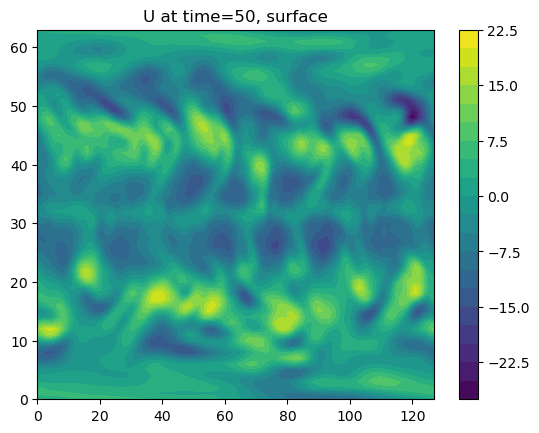

[ 18.428064  73.71226  124.389114 174.76202  225.07178  275.16132
 325.25848  375.61874  425.43405  475.8721   525.82214  575.92175
 626.0489   676.0595   726.5415   776.6981   826.4571   876.28015
 926.67236  977.1867  ]


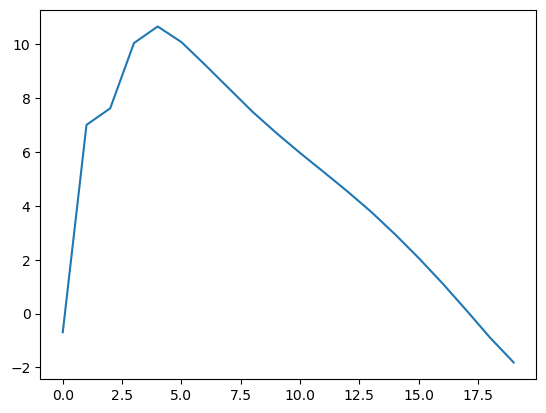

In [94]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt

infile = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/Dycore_500_20000day_6hourly_u.nc"
ds = Dataset(infile)
print(ds)
# ds = Dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc")
# ds = Dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat")
# print(ds.variables)
u = ds.variables["u"]
level = ds.variables["level"][:]
# print(p.mean(axis=(0,2,3)))
u_plot = u[-1, -1, :, :]  # [time, level, lat, lon]

plt.figure()
plt.contourf(u_plot, levels=21)
plt.colorbar()
plt.title("U at time=50, surface")
plt.show()


# with h5py.File(r"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc", "r") as ds:
print(level)
plt.figure()
plt.plot(u[-100:,:,:,:].mean(axis=(0,2,3)))

(78000, 20, 64, 128)


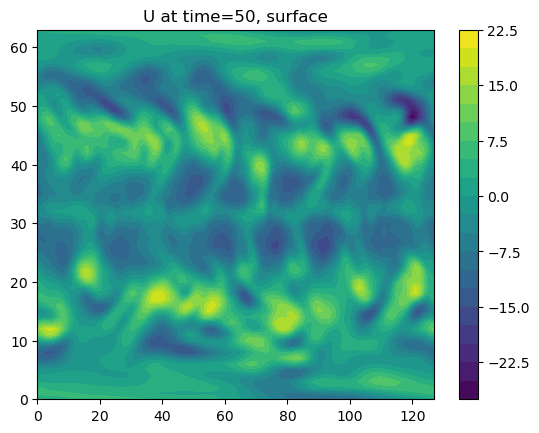

[ 18.428064  73.71226  124.389114 174.76202  225.07178  275.16132
 325.25848  375.61874  425.43405  475.8721   525.82214  575.92175
 626.0489   676.0595   726.5415   776.6981   826.4571   876.28015
 926.67236  977.1867  ]


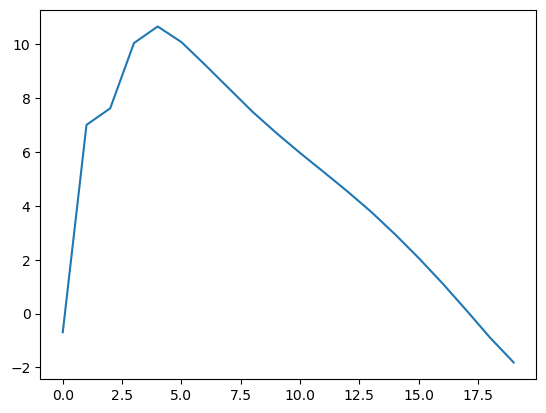

In [108]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt

ds = Dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc")
u = ds.variables["u"]
level = ds.variables["level"][:]
print(u.shape)
u_plot = u[-1, -1, :, :]  # [time, level, lat, lon]

plt.figure()
plt.contourf(u_plot, levels=21)
plt.colorbar()
plt.title("U at time=50, surface")
plt.show()


# with h5py.File(r"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc", "r") as ds:
print(level)
plt.figure()
plt.plot(u[-100:,:,:,:].mean(axis=(0,2,3)))

(78000, 37, 73, 144)


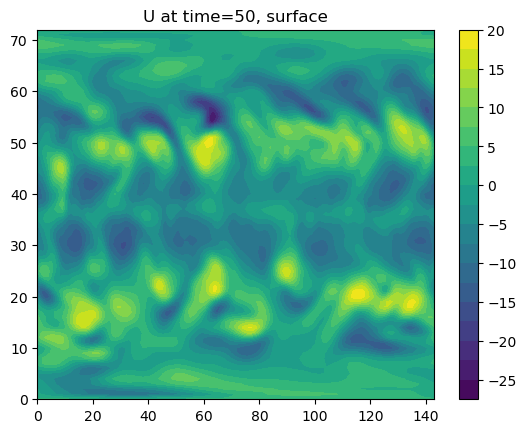

[ 18.5   44.64  70.85  97.06 123.28 149.49 175.7  201.91 228.13 254.34
 280.55 306.76 332.97 359.19 385.4  411.61 437.82 464.04 490.25 516.46
 542.67 568.89 595.1  621.31 647.52 673.74 699.95 726.16 752.37 778.59
 804.8  831.01 857.22 883.44 909.65 935.86 962.08]


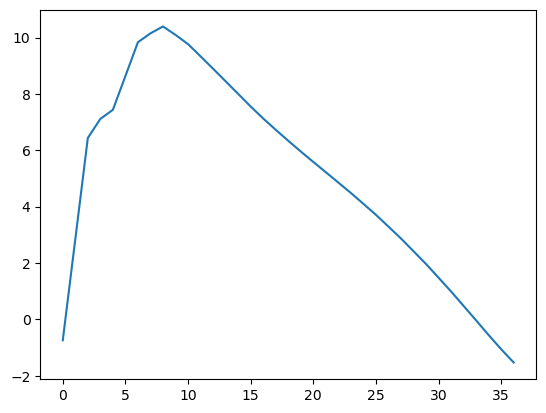

In [109]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt

ds = Dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u_regrid.nc")
u = ds.variables["u"]
level = ds.variables["level"][:]
print(u.shape)
u_plot = u[-1, -1, :, :]  # [time, level, lat, lon]

plt.figure()
plt.contourf(u_plot, levels=21)
plt.colorbar()
plt.title("U at time=50, surface")
plt.show()


# with h5py.File(r"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc", "r") as ds:
print(level)
plt.figure()
plt.plot(u[-100:,:,:,:].mean(axis=(0,2,3)))

(78000, 37, 73, 144)


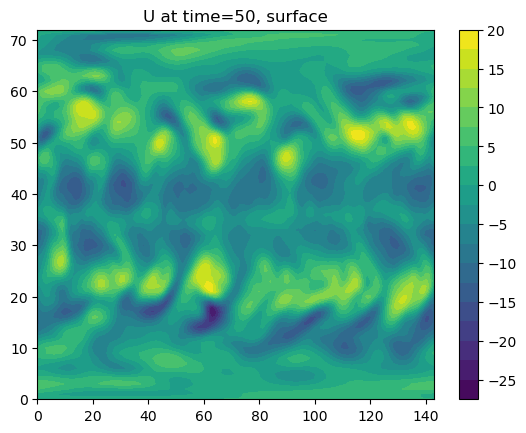

[ 18.5   44.64  70.85  97.06 123.28 149.49 175.7  201.91 228.13 254.34
 280.55 306.76 332.97 359.19 385.4  411.61 437.82 464.04 490.25 516.46
 542.67 568.89 595.1  621.31 647.52 673.74 699.95 726.16 752.37 778.59
 804.8  831.01 857.22 883.44 909.65 935.86 962.08]


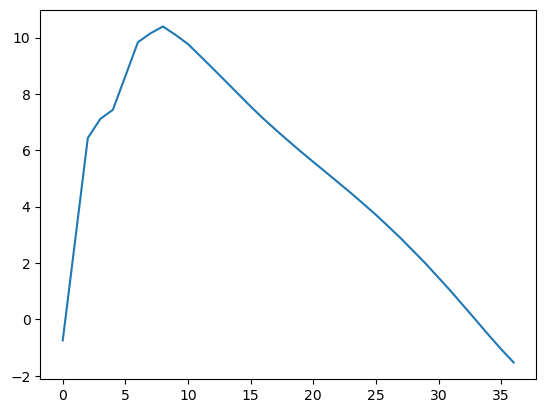

In [110]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt

ds = Dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u_final.nc")
u = ds.variables["u"]
level = ds.variables["level"][:]
print(u.shape)
u_plot = u[-1, -1, :, :]  # [time, level, lat, lon]

plt.figure()
plt.contourf(u_plot, levels=21)
plt.colorbar()
plt.title("U at time=50, surface")
plt.show()


# with h5py.File(r"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc", "r") as ds:
print(level)
plt.figure()
plt.plot(u[-100:,:,:,:].mean(axis=(0,2,3)))

In [ ]:
from netCDF4 import Dataset
import numpy as np

ds = Dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u_regrid.nc")
u = ds.variables["u"][:]
print("u NaN ratio:", np.isnan(u).sum() / u.size)

ds = Dataset("Dycore_500_20000day_6hourly_v_regrid.nc")
v = ds.variables["v"][:]
print("v NaN ratio:", np.isnan(v).sum() / v.size)

ds = Dataset("Dycore_500_20000day_6hourly_t_regrid.nc")
t = ds.variables["t"][:]
print("t NaN ratio:", np.isnan(t).sum() / t.size)


In [296]:
from netCDF4 import Dataset
import numpy as np

def rebuild_coords(nc_path):
    print(f"Rebuilding coordinates in: {nc_path}")
    with Dataset(nc_path, "r+") as ds:
        dims = ds.dimensions

        # Add time if missing
        if "time" not in ds.variables:
            time = ds.createVariable("time", "f4", ("time",))
            time[:] = np.arange(len(dims["time"])) * 6  # 6-hourly
            time.units = "hours since 1979-01-01 00:00:00"
            time.calendar = "gregorian"
            time.standard_name = "time"
            time.long_name = "time"
            time.axis = "T"

        # Add level
        if "level" not in ds.variables:
            lev = ds.createVariable("level", "f4", ("level",))
            lev[:] = np.linspace(1000, 10, len(dims["level"]))  # or adjust!
            lev.units = "hPa"
            lev.standard_name = "air_pressure"
            lev.long_name = "pressure_level"
            lev.axis = "Z"

        # Add latitude
        if "latitude" not in ds.variables:
            lat = ds.createVariable("latitude", "f4", ("latitude",))
            lat[:] = np.linspace(-90, 90, len(dims["latitude"]))
            lat.units = "degrees_north"
            lat.standard_name = "latitude"
            lat.long_name = "latitude"
            lat.axis = "Y"

        # Add longitude
        if "longitude" not in ds.variables:
            lon = ds.createVariable("longitude", "f4", ("longitude",))
            lon[:] = np.linspace(0, 360, len(dims["longitude"]), endpoint=False)
            lon.units = "degrees_east"
            lon.standard_name = "longitude"
            lon.long_name = "longitude"
            lon.axis = "X"

        print("  -> All coordinates rebuilt.")

# 執行
rebuild_coords("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc")
rebuild_coords("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_v.nc")
rebuild_coords("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_t.nc")

# 執行
# for var in ["u", "v", "t"]:
    # fix_header(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_{var}.nc")


Rebuilding coordinates in: /data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_u.nc
  -> All coordinates rebuilt.
Rebuilding coordinates in: /data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_v.nc
  -> All coordinates rebuilt.
Rebuilding coordinates in: /data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/data/Dycore_500_20000day_6hourly_t.nc
  -> All coordinates rebuilt.


# Jucker method EP flux 

In [370]:
lat = np.linspace(90,-90,64)
t.shape

(78000, 20, 64, 128)

In [371]:
# import aostools_functions as ac
import sys
import importlib

sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac
importlib.reload(ac)  # ← 強制重新載入

lat = np.linspace(90,-90,64)

# print(z.shape)
start_idx = 50000
end_idx   = 52000

p_1d = p[start_idx:end_idx].mean(axis=(0,2,3))
print(p_1d.shape)
ep1,ep2, dthdp, theta_zm = ac.ComputeEPfluxDiv(lat,p_1d/100,u[start_idx:end_idx],v[start_idx:end_idx],t[start_idx:end_idx])


(20,)


In [372]:
print(np.array(ep1.mean(axis=0)).max(), np.array(ep1.mean(axis=0)).min())
print(np.array(ep2.mean(axis=0)).max(), np.array(ep2.mean(axis=0)).min())


11.900893 -19.780222
0.008685594255539822 -0.06677099942250456


In [374]:
a0 = 6376.0e3
lat = np.linspace(90,-90,64)
cosphi = np.cos(np.deg2rad(lat))
time_len = u[start_idx:end_idx].shape[0]
time_coord = np.arange(time_len)  # or use your actual time values if available

f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": p_1d/100,
                          "latitude": lat},
                  name='f1')

f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": p_1d/100,
                          "latitude": lat},
                  name='f2')

F_phi = a0*cosphi*f1
F_p = a0*cosphi*f2

In [375]:
def CorrectAspect(x,y):
	# x-coordinate in kilometers = a*phi
	delta_x = 6.4e3*np.deg2rad(x[-1]-x[0])
	# delta_y = y[-1] - y[0]
	delta_y = max(y) - min(y)
	# figure aspect ratio
	width,height = GetAxSize(plt.gcf(),plt.gca())
	return delta_y/height,delta_x/width

In [376]:
def GetAxSize(fig,ax,dpi=False):
	"""get width and height of a given axis.
	   output is in inches if dpi=False, in dpi if dpi=True
	"""
	bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
	width, height = bbox.width, bbox.height
	if dpi:
		width *= fig.dpi
		height *= fig.dpi
	return width, height

In [377]:
def Baldwin(F_phi,F_p,pres='level',lat='latitude',xlim=[-90,90]):
	# Baldwin et al JAS (1985), Figure 6E
	# F_phi = a*cosphi*(-u'v')
	# F_p   = a*cosphi*(f*v'theta'/theta_p)
	# log(p) coordinates. Note here that
	#  they say they use ln(p) as vertical coordinate,
	#  but in fact they use log10(p)
	#  They do not say what value they use for H either,
	#   so we have to guess here that it's the same as Palmer (1981)
	H = 6.4e3
	p0 = 1000.
	z = -H*np.log(F_p[pres]/p0)
	# They use theta_z instead of theta_p, so we need to convert
	F_z = -F_p*H/p0
	# Then, they multiply by exp(z/H) = p0/0
	# Fhat_phi = F_phi*exp(z/H) = F_phi*p0/p
	# Fhat_p   = F_z*exp(z/H) = F_z*p0/p
	# in addition,
	factr = p0/F_p[pres]
	# also correct for aspect ratio
	dx,dy = CorrectAspect(xlim,z*1.e-3)
	return factr*dx*F_phi,factr*dy*F_z

In [22]:
def set_size(w,h, ax=None):
	""" w, h: width, height in inches """
	if not ax: ax=plt.gca()
	l = ax.figure.subplotpars.left
	r = ax.figure.subplotpars.right
	t = ax.figure.subplotpars.top
	b = ax.figure.subplotpars.bottom
	figw = float(w)/(r-l)
	figh = float(h)/(t-b)
	ax.figure.set_size_inches(figw, figh)

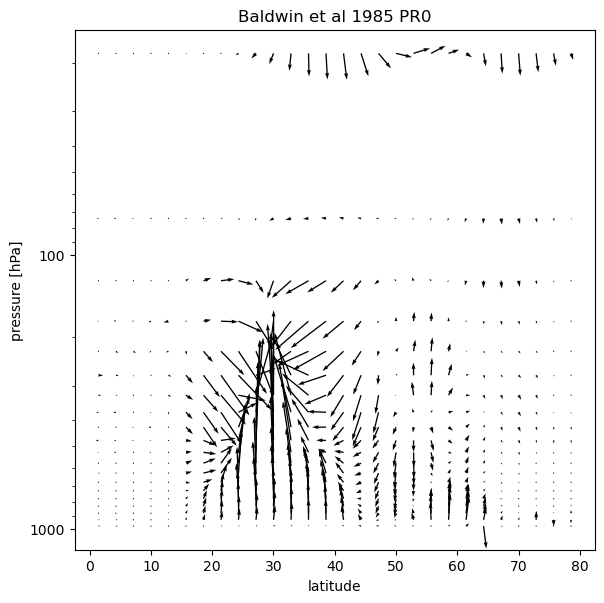

In [380]:
Fx = {}
Fy = {}
scale = "log"
# Baldwin et al 1985, Figure 6:
method = 'Baldwin'
quiv_args = {'angles':'uv','scale_units':'inches','linewidths':1,'edgecolors':'k','color':'none'}

# f1,f2,F_phi,F_p,div1,div2 = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1,divs=True)
lat = f1.sel(latitude=slice(80,0)).latitude
# pres = np.array([50,70,100,150,200,300,400,500,700,850])
# pres = np.array([10,25,50,70,100,150,200,225,250,270,300,350,400,450,500,550,600,625,650,700,725,750,800,825,850,900,1000])
pres = f1.level
fig,ax = plt.subplots()
set_size(5.2,5.2,ax)
width,height = GetAxSize(fig,ax)

# Reference method
# Fx[method],Fy[method] = Baldwin(F_phi.sel(latitude=lat,level=pres, method='nearest'),F_p.sel(latitude=lat,level=pres, method='nearest'),xlim=[0,80])
# ax.quiver(lat,pres,Fx[method].mean(dim="time"),Fy[method].mean(dim="time"),scale=8e9,**quiv_args)
# Jucker (2020) method
# print(f1)
_,_, dx, dy, delta_x, delta_y,  = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,
                          f1.sel(level=pres).level,
                          f1.sel(latitude=lat,level=pres).mean(dim='time'),
                          f2.sel(latitude=lat,level=pres).mean(dim='time'),
                          fig,ax,yscale=scale)
ax.get_children()[1].set_facecolor('r')
# if scale == 'linear':
#     ax.invert_yaxis()
plt.title(f'Baldwin et al 1985 PR{PR}')
ax.set_xlabel('latitude')
ax.set_ylabel('pressure [hPa]')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
# fig.savefig('figures/Baldwin85.{0}.pdf'.format(scale),bbox_inches='tight')

In [381]:
test = f1.sel(level=pres).level
test

<xarray.DataArray 'level' (level: 20)>
array([ 18.428478,  73.71391 , 124.3924  , 174.72934 , 224.95694 , 275.13544 ,
       325.28818 , 375.4251  , 425.55176 , 475.67114 , 525.7862  , 575.8967  ,
       626.0053  , 676.1113  , 726.21655 , 776.31885 , 826.41986 , 876.5218  ,
       926.62305 , 976.7236  ], dtype=float32)
Coordinates:
  * level    (level) float32 18.43 73.71 124.4 174.7 ... 826.4 876.5 926.6 976.7

In [382]:
np.max(test)

<xarray.DataArray 'level' ()>
array(976.72357178)

In [383]:
delta_y

<xarray.DataArray 'level' (level: 20)>
array([-0.07107058, -0.01776764, -0.01052896, -0.00749572, -0.0058221 ,
       -0.00476028, -0.00402635, -0.00348864, -0.0030777 , -0.00275342,
       -0.00249098, -0.00227423, -0.00209219, -0.00193714, -0.00180349,
       -0.00168709, -0.00158481, -0.00149423, -0.00141344, -0.00134093])
Coordinates:
  * level    (level) float32 18.43 73.71 124.4 174.7 ... 826.4 876.5 926.6 976.7

In [384]:
delta_x

<xarray.DataArray 'latitude' ()>
array(3.86215995)

In [385]:
		dy = y_sign*height/y/np.log(np.max(y)/np.min(y))


NameError: name 'y_sign' is not defined

<xarray.DataArray (latitude: 28, level: 20)>
array([[ 7.68002592e+14,  6.63536156e+14,  6.80115366e+14,
         5.14897580e+14,  3.29448901e+14,  3.21680872e+14,
         9.83224464e+14,  3.61054963e+15,  7.51602261e+15,
         8.55274946e+15,  5.80309856e+15,  2.81438374e+15,
         9.32680122e+14, -1.88841746e+14, -9.25577214e+14,
        -3.51798626e+15, -8.44139441e+15, -1.76097593e+16,
         1.99678850e+16,  1.95900346e+14],
       [ 1.43710381e+15,  1.35089151e+15,  1.47715044e+15,
         1.73346675e+15,  1.47400935e+15,  2.48503259e+15,
         2.35754707e+15,  3.12645757e+15,  7.75086206e+15,
         9.26518460e+15,  6.20273798e+15,  2.30841217e+15,
        -1.01040988e+14, -8.16300914e+14, -2.20849813e+14,
        -7.35944303e+14, -3.54093715e+15, -7.68245747e+15,
         3.85251523e+16,  2.25102597e+14],
       [ 2.19167031e+15,  2.03440957e+15,  2.93642651e+15,
         2.86872444e+15,  2.76592929e+15,  5.50631345e+15,
         7.48132188e+15,  6.88622496e+15,  9.00475881e+15,
         8.02518924e+15,  5.70834961e+15,  2.76298535e+15,
         7.95763752e+14, -6.25718680e+14, -1.52011717e+15,
        -3.49588271e+15, -7.37094348e+15, -1.06884960e+16,
...
        -1.98631037e+14,  2.91135279e+15,  2.74547191e+15,
         6.75083802e+14,  6.65098740e+14,  6.18257960e+14,
         5.93687874e+14, -1.24808309e+14, -2.39808125e+15,
         5.93114612e+14, -1.92278113e+15, -2.68939969e+15,
        -5.00600711e+15, -4.36742935e+15, -2.62306279e+15,
        -1.45429622e+15, -6.90562772e+13],
       [ 1.30272196e+13, -6.95004676e+13,  1.17731860e+14,
        -5.68729594e+14,  2.69680706e+15,  1.06366482e+15,
         4.28423633e+14,  8.67494770e+14,  1.53964218e+15,
         3.16174759e+14, -5.86584861e+14, -6.22330331e+14,
        -1.57042422e+15, -4.31958100e+14,  1.31825642e+15,
        -1.30483854e+15, -1.89251035e+15, -1.49530140e+15,
        -6.61505457e+14, -9.88798599e+11],
       [ 2.04600941e+12, -1.16800583e+12,  3.67596211e+13,
        -1.51729887e+14,  3.47564642e+14,  2.74288671e+14,
         2.50672610e+14,  6.67127386e+14,  7.23204891e+14,
         2.27054125e+13, -2.01730931e+14, -2.54801077e+14,
        -4.61673975e+14,  1.06892427e+13,  5.98564388e+14,
        -1.09100229e+14, -3.34230517e+14, -3.14462976e+14,
        -1.14042943e+14,  4.54684630e+12]])
Coordinates:
  * latitude  (latitude) float64 78.57 75.71 72.86 70.0 ... 7.143 4.286 1.429
  * level     (level) float32 18.43 73.71 124.4 174.7 ... 876.5 926.6 976.7

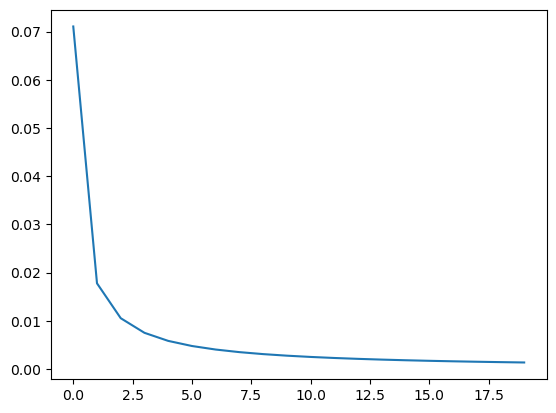

In [386]:
plt.figure()
# plt.plot(dy*pres)
# plt.plot(height/pres/np.log(np.max(pres)/np.min(pres))* ep2[:,:,32].mean(axis=0))
plt.plot(height/pres/np.log(np.max(pres)/np.min(pres)))

dy

In [387]:
def Andrews(F_phi,F_p,pres='level',lat='latitude',xlim=[-90,90]):
	# Andrews et al JAS (1983)
	#  F_phi = a*cosphi*(-u'v' + ...)
	#  F_p   = a*cosphi*(-u'w' + ...)
	p0 =1013.25
	# note that they don't use H, or set H=1. That doesn't work.
	#  so we use the same H as all others here.
	H = 6.4e3
	z = -H*np.log(F_p[pres]/p0)
	# "To represent the vector F in a rectangular
	#  plot with phi and z as coordinates, Fphi and Fz
	#  are separately stretched in an obvious way."
	# They do not say what this obvious way is.
	# We give them the benefit of the doubt and do this correctly
	dx,dy = CorrectAspect([-90,90],z*1e-3)
	# What they do say is the following scaling:
	Fhat_phi = F_phi*F_p[pres]/p0
	Fhat_p   = -H*F_p/p0
	# note that this is equivalent to only rescaling F_p by -H/p
	# Fhat_phi = F_phi
	# Fhat_p   = -H*F_p/F_p[pres]
	return (dx*Fhat_phi).transpose(),(dy*Fhat_p).transpose(),z

(64, 20, 2000)


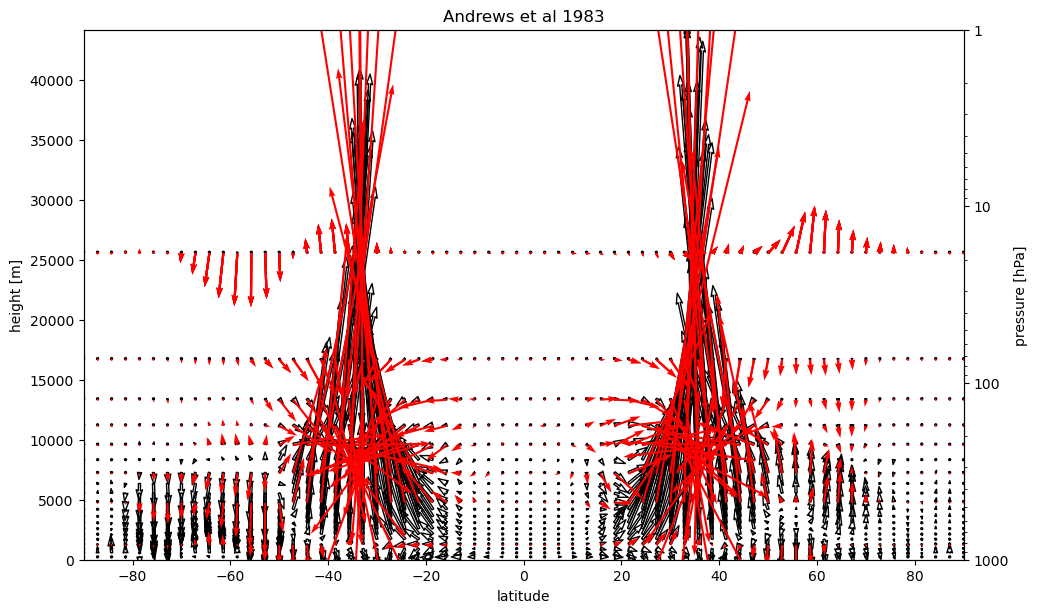

In [385]:
Fx = {}
Fy = {}
method = 'Andrews'
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = f1.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
Fx[method],Fy[method],z = Andrews(F_phi,F_p)
print(Fx[method].shape)
# _,_ = ac.PlotEPfluxArrows(
#     f1.latitude,
#     f1.level.sel(level=pres, method='nearest'),
#     f1.sel(level=pres, latitude=lat, method='nearest').mean(dim='time'),
#     f2.sel(level=pres, latitude=lat, method='nearest').mean(dim='time'),
#     fig, ax,
#     xlim=[0, 80], ylim=[1000, 50], yscale=scale
# )
if scale == 'log':
    ax.quiver(lat,z,Fx[method].mean(dim="time").T,Fy[method].mean(dim="time").T,scale=2e8,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,
                                  f1.level.sel(level=pres, method='nearest'),
                                  f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=6e14)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')
else:
    ax.quiver(lat,pres,Fx[method],Fy[method],scale=3e9,**quiv_args)
    # Jucker (2020) method
    _,_ = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,f1.sel(level=pres).level,f1.sel(latitude=lat,level=pres),f2.sel(latitude=lat,level=pres),fig,ax,xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=False,scale=1e15)
    ax.get_children()[1].set_facecolor('r')
plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
# ax.set_xlim([0,80])
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


In [41]:
import h5py
import numpy as np
import xarray as xr
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

# --- Step 1: 資料讀取 ---
def load_hdf5_variable(file_path, var, start_idx, end_idx):
    print(f"Reading variable '{var}' from {file_path}...")
    with h5py.File(file_path, "r") as ds:
        data = np.asarray(ds[var][start_idx:end_idx])
    print(f"Done reading '{var}'. Shape = {data.shape}")
    return data

# --- Step 2: 計算 EP flux ---
def compute_ep_flux(u, v, t, p, lat):
    print("Computing zonal mean pressure...")
    p_1d = p.mean(axis=(0, 2, 3))

    print("Running EP flux computation (Jucker method)...")
    ep1, ep2, div1, div2 = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)

    print("Wrapping results into xarray DataArrays...")
    time_len = u.shape[0]
    time_coord = np.arange(time_len)
    level_vals = np.round(p_1d / 100, 1)

    f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f1')
    f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f2')

    print("EP flux computation finished.\n")
    return f1, f2


In [42]:
# 設定 PR 實驗與資料區間
PR = 10
start_idx = 50000
end_idx = 70000
lat = np.linspace(90, -90, 64)

# 設定資料夾
base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}"

# 載入資料（含進度顯示）
u = load_hdf5_variable(f"{base_dir}/u/PR{PR}_500_20000day_6hourly_u.dat", "u", start_idx, end_idx)
v = load_hdf5_variable(f"{base_dir}/v/PR{PR}_500_20000day_6hourly_v.dat", "v", start_idx, end_idx)
t = load_hdf5_variable(f"{base_dir}/t/PR{PR}_500_20000day_6hourly_t.dat", "t", start_idx, end_idx)
p = load_hdf5_variable(f"{base_dir}/p/PR{PR}_500_20000day_6hourly_p.dat", "p", start_idx, end_idx)




Reading variable 'u' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/u/PR10_500_20000day_6hourly_u.dat...
Done reading 'u'. Shape = (20000, 20, 64, 128)
Reading variable 'v' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/v/PR10_500_20000day_6hourly_v.dat...
Done reading 'v'. Shape = (20000, 20, 64, 128)
Reading variable 't' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/t/PR10_500_20000day_6hourly_t.dat...
Done reading 't'. Shape = (20000, 20, 64, 128)
Reading variable 'p' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR10/p/PR10_500_20000day_6hourly_p.dat...
Done reading 'p'. Shape = (20000, 20, 64, 128)


In [43]:
# 計算 EP flux
f1, f2 = compute_ep_flux(u, v, t, p, lat)

Computing zonal mean pressure...
Running EP flux computation (Jucker method)...
Wrapping results into xarray DataArrays...
EP flux computation finished.



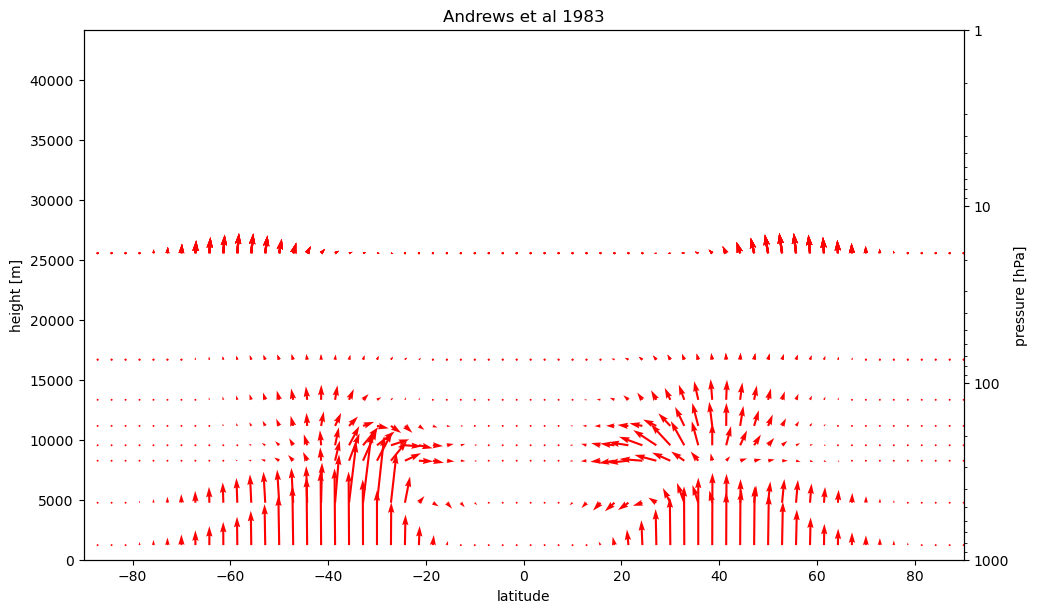

In [44]:
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = F_phi.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
scale = "log"
if scale == 'log':
    # ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e9,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(f1.sel(latitude=lat).latitude,
                                  f1.level.sel(level=pres, method='nearest'),
                                  -f1.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  -f2.sel(latitude=lat,level=pres, method='nearest').mean(dim='time'),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=3e15)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


In [68]:
PR = 0
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")

In [69]:
time_idx_array_positive

array([ 1090,  1091,  1092, ..., 77560, 77561, 77562])

In [45]:
import h5py
import numpy as np
import xarray as xr
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

def load_hdf5_variable(file_path, var, start_idx, end_idx):
    print(f"Reading variable '{var}' from {file_path}...")
    with h5py.File(file_path, "r") as ds:
        data = np.asarray(ds[var][start_idx:end_idx])
    print(f"Done reading '{var}'. Shape = {data.shape}")
    return data

def compute_ep_flux(u, v, t, p, lat):
    p_1d = p.mean(axis=(0, 2, 3))

    print("Running EP flux computation (Jucker method)...")
    ep1, ep2, div1, div2 = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)

    print("Wrapping results into xarray DataArrays...")
    time_len = u.shape[0]
    time_coord = np.arange(time_len)
    level_vals = np.round(p_1d / 100, 1)

    f1 = xr.DataArray(ep1, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f1')
    f2 = xr.DataArray(ep2, dims=["time", "level", "latitude"],
                      coords={"time": time_coord, "level": level_vals, "latitude": lat}, name='f2')

    print("EP flux computation finished.\n")
    return f1, f2

def process_PR_case(pr, lat, start_idx=50000, end_idx=70000):
    base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{pr}"
    print(f"\n========== Start processing PR = {pr} ==========")
    u = load_hdf5_variable(f"{base_dir}/u/PR{pr}_500_20000day_6hourly_u.dat", "u", start_idx, end_idx)
    v = load_hdf5_variable(f"{base_dir}/v/PR{pr}_500_20000day_6hourly_v.dat", "v", start_idx, end_idx)
    t = load_hdf5_variable(f"{base_dir}/t/PR{pr}_500_20000day_6hourly_t.dat", "t", start_idx, end_idx)
    p = load_hdf5_variable(f"{base_dir}/p/PR{pr}_500_20000day_6hourly_p.dat", "p", start_idx, end_idx)

    return compute_ep_flux(u, v, t, p, lat)

# 設定緯度與時間範圍
lat = np.linspace(90, -90, 64)
start_idx = 50000
end_idx = 70000

# PR=0 baseline
F_phi_base, F_p_base = process_PR_case(pr=0, lat=lat, start_idx=start_idx, end_idx=end_idx)

# 要比較的實驗 PR 值
PR_list = range(10, 20, 10)

# 儲存差異結果
diffs = {}

for pr in PR_list:
    F_phi_cmp, F_p_cmp = process_PR_case(pr=pr, lat=lat, start_idx=start_idx, end_idx=end_idx)

    # 內插至 PR=0 的 pressure level，以避免 shape mismatch
    F_phi_cmp_interp = F_phi_cmp.interp(level=F_phi_base.level, method="nearest")
    F_p_cmp_interp   = F_p_cmp.interp(level=F_p_base.level,   method="nearest")

    diff_phi = F_phi_cmp_interp - F_phi_base
    diff_p   = F_p_cmp_interp   - F_p_base

    diffs[pr] = (diff_phi, diff_p)

    print(f"✓ PR={pr} vs PR=0 difference computed.\n{'-'*40}")



========== Start processing PR = 0 ==========
Reading variable 'u' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat...
Done reading 'u'. Shape = (20000, 20, 64, 128)
Reading variable 'v' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/PR0_500_20000day_6hourly_v.dat...
Done reading 'v'. Shape = (20000, 20, 64, 128)
Reading variable 't' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/PR0_500_20000day_6hourly_t.dat...
Done reading 't'. Shape = (20000, 20, 64, 128)
Reading variable 'p' from /data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/p/PR0_500_20000day_6hourly_p.dat...
Done reading 'p'. Shape = (20000, 20, 64, 128)
Running EP flux computation (Jucker method)...
Wrapping results into xarray DataArrays...
EP flux

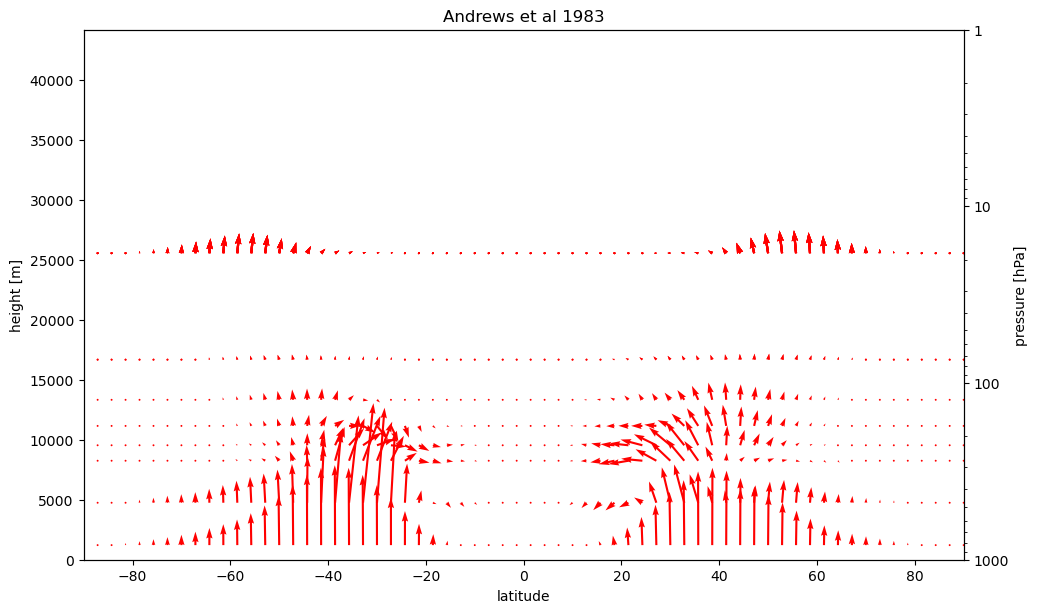

In [65]:
# f1,f2,F_phi,F_p = ReadERA(slice('1979-01-05','1979-03-03'),pskip=1)
pres = np.array([850,500,300,200,150,100,70,50,30,20,10,7,5,2])[::-1]
# pres = F_p.sel(level=slice(1,850)).level
lat = F_phi_base.latitude
# pres = np.array([50,70,100,150,200,250,300,400,500,700,850])
fig,ax = plt.subplots()
set_size(8.8,5.3,ax)
# Reference method
scale = "log"
if scale == 'log':
    # ax.quiver(lat,z,-Fx[method].mean(dim="time").T,-Fy[method].mean(dim="time").T,scale=2e9,**quiv_args)
    # Jucker (2020) method
    _,_,axp = ac.PlotEPfluxArrows(F_phi_cmp_interp.sel(latitude=lat).latitude,
                                  F_phi_cmp_interp.level.sel(level=pres, method='nearest'),
                                  -F_phi_cmp_interp.sel(latitude=lat,level=pres, method='nearest').mean(dim='time') - (-F_phi_base.sel(latitude=lat,level=pres, method='nearest').mean(dim='time')),
                                  -F_p_cmp_interp.sel(latitude=lat,level=pres, method='nearest').mean(dim='time') - (-F_p_base.sel(latitude=lat,level=pres, method='nearest').mean(dim='time')),
                                  fig,ax,
                                  xlim=[-90,90],ylim=[1000,1],yscale=scale,newax=True,scale=3e15)
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0,6.4e3*np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('Andrews et al 1983')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
		# fig.savefig('figures/Andrews83.{0}.pdf'.format(scale),bbox_inches='tight')


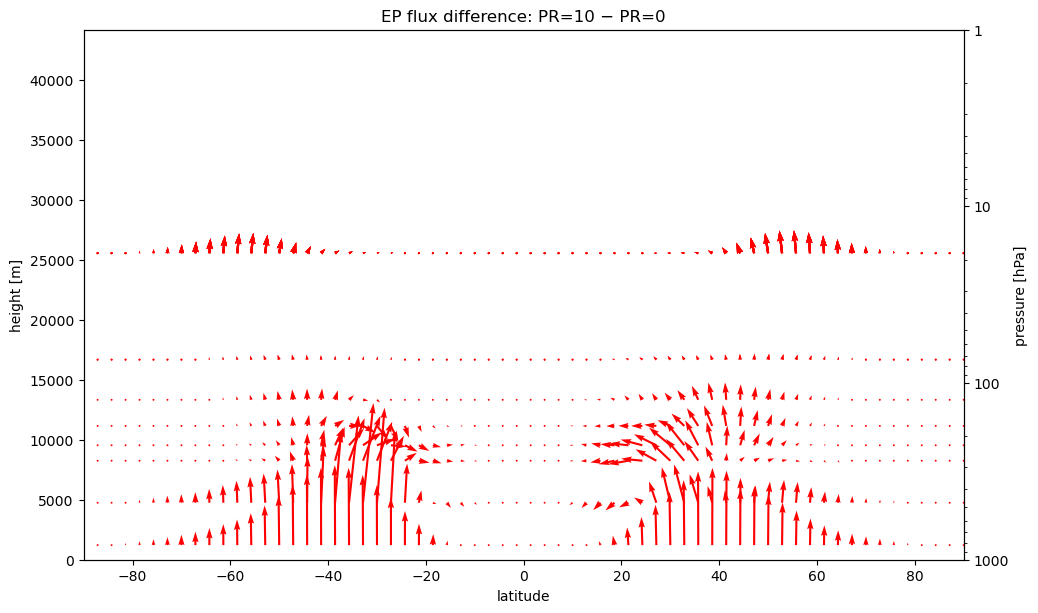

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pres = np.array([850, 500, 300, 200, 150, 100, 70, 50, 30, 20, 10, 7, 5, 2])[::-1]
lat = diffs[10][0].latitude  # 或 f1.latitude

fig, ax = plt.subplots()
set_size(8.8, 5.3, ax)
scale = "log"

# 取出差值資料
ep1_diff = diffs[10][0].sel(latitude=lat, level=pres, method='nearest').mean(dim='time')
ep2_diff = diffs[10][1].sel(latitude=lat, level=pres, method='nearest').mean(dim='time')

# 確保維度對齊（展平）
yy, xx = xr.broadcast(ep1_diff.level, ep1_diff.latitude)




if scale == 'log':
    _, _, axp = ac.PlotEPfluxArrows(
        xx.values, yy.values,
        -ep1_diff.values, -ep2_diff.values,
        fig, ax,
        xlim=[-90, 90],
        ylim=[1000, 1],
        yscale='log',
        newax=True,
        scale=3e15
    )
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 6.4e3 * np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('EP flux difference: PR=10 − PR=0')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())


## Test PC1 > std and < std time index 

In [ ]:
import numpy as np
import xarray as xr
import h5py

# Constants
lat = np.linspace(90, -90, 64)
lags_5_20 = range(15 * 4, 15 * 4+1, 1)  # lags 15–25 days
lags_30_60 = range(90 * 4, 90 * 4+1, 1)  # lags 90–100 days
PR_list = [0, 10]

# Load all variables only once per PR
def load_all_variables(pr):
    base_dir = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{pr}"
    def load_var(var):
        with h5py.File(f"{base_dir}/{var}/PR{pr}_500_20000day_6hourly_{var}.dat", "r") as ds:
            return np.asarray(ds[var][:])
    return {
        "u": load_var("u"),
        "v": load_var("v"),
        "t": load_var("t"),
        "p": load_var("p"),
    }

# Wrapper to compute EP flux using provided arrays
def compute_ep_flux(u, v, t, p, lat):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
    import aostools_functions as ac
    p_1d = p.mean(axis=(0, 2, 3))
    ep1, ep2  = ac.ComputeEPfluxDiv(lat, p_1d / 100, u, v, t)
    level_vals = np.round(p_1d / 100, 1)
    return xr.DataArray(ep1, dims=["time", "level", "latitude"],
                        coords={"time": np.arange(u.shape[0]), "level": level_vals, "latitude": lat}), \
           xr.DataArray(ep2, dims=["time", "level", "latitude"],
                        coords={"time": np.arange(u.shape[0]), "level": level_vals, "latitude": lat})

# Composite EP flux for a specific PR
def composite_ep_flux(data, time_idx_array, lags):
    f1_all, f2_all = [], []
    u, v, t, p = data["u"], data["v"], data["t"], data["p"]
    for lag in lags:
        valid_idx = time_idx_array + lag
        valid_idx = valid_idx[(valid_idx >= 0) & (valid_idx < u.shape[0])]
        if len(valid_idx) == 0:
            continue
        f1, f2 = compute_ep_flux(u[valid_idx], v[valid_idx], t[valid_idx], p[valid_idx], lat)
        f1_all.append(f1.mean("time"))
        f2_all.append(f2.mean("time"))
    return xr.concat(f1_all, dim="lag").mean("lag"), xr.concat(f2_all, dim="lag").mean("lag")

# Storage
same_pr_ep_diff = {}
final_diff_vs_pr0 = {}

for pr in PR_list:
    print(f"Loading data for PR={pr}...")
    data = load_all_variables(pr)

    time_idx_pos = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{pr}.npy")
    time_idx_neg = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{pr}.npy")

    print(f"--> Computing EP+ composite for PR={pr}")
    ep1_pos, ep2_pos         = composite_ep_flux(data, time_idx_pos, lags_5_20)
    ep1_far_pos, ep2_far_pos = composite_ep_flux(data, time_idx_pos, lags_30_60)
    
    # interpolate to ep1_far_pos.level
    ep1_pos_interp = ep1_pos.interp(level=ep1_far_pos.level, method="nearest")
    ep2_pos_interp = ep2_pos.interp(level=ep2_far_pos.level, method="nearest")
    
    EP_plus   = ep1_pos_interp - ep1_far_pos
    EP_plus_p = ep2_pos_interp - ep2_far_pos
    print(ep1_pos_interp.shape, ep1_far_pos.shape, EP_plus.shape)

    print(f"--> Computing EP- composite for PR={pr}")
    ep1_neg, ep2_neg         = composite_ep_flux(data, time_idx_neg, lags_5_20)
    ep1_far_neg, ep2_far_neg = composite_ep_flux(data, time_idx_neg, lags_30_60)

    # interpolate to ep1_far_pos.level
    ep1_neg_interp = ep1_neg.interp(level=ep1_far_neg.level, method="nearest")
    ep2_neg_interp = ep2_neg.interp(level=ep2_far_neg.level, method="nearest")
    
    EP_minus   = ep1_neg_interp - ep1_far_neg
    EP_minus_p = ep2_neg_interp - ep2_far_neg
 
    # interpolate to ep1_far_pos.level
    EP_plus_interp   = EP_plus.interp(level=EP_minus.level, method="nearest")
    EP_plus_p_interp = EP_plus_p.interp(level=EP_minus_p.level, method="nearest")
    
    diff_phi = EP_plus_interp - EP_minus
    diff_p   = EP_plus_p_interp - EP_minus_p
    print(diff_phi.shape, EP_plus_interp.shape, EP_minus.shape)
    same_pr_ep_diff[pr] = (diff_phi, diff_p)

    # === Save EP flux diff results ===
    save_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff.nc"
    print(f"\nSaving EP flux diff to {save_path}...")
    
    # 將所有 PR 的資料整理進 Dataset
    ds_out = xr.Dataset()
    for pr in same_pr_ep_diff:
        ds_out[f"EP_phi_diff_PR{pr}"] = same_pr_ep_diff[pr][0]
        ds_out[f"EP_p_diff_PR{pr}"]   = same_pr_ep_diff[pr][1]
    
    # 儲存為 NetCDF
    ds_out.to_netcdf(save_path)
    print("✓ Save complete.")




Loading data for PR=0...
--> Computing EP+ composite for PR=0


In [105]:
# # Difference from PR=0
# for pr in PR_list:
#     if pr == 0:
#         continue
#     diff_vs_pr0_phi = same_pr_ep_diff[pr][0].interp_like(same_pr_ep_diff[0][0]) - same_pr_ep_diff[0][0]
#     diff_vs_pr0_p   = same_pr_ep_diff[pr][1].interp_like(same_pr_ep_diff[0][1]) - same_pr_ep_diff[0][1]
#     final_diff_vs_pr0[pr] = (diff_vs_pr0_phi, diff_vs_pr0_p)

In [106]:
# # Read vars
# ds = xr.open_dataset("/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff.nc")
# diff_phi_pr10 = ds["EP_phi_diff_PR10"]
# diff_p_pr10   = ds["EP_p_diff_PR10"]



In [114]:
# final_diff_vs_pr0

{10: (<xarray.DataArray (level: 20, latitude: 64)>
  array([[-3.8516947 , -3.23973083, -2.6589179 , ..., -0.99085236,
          -0.45372963,  0.06197524],
         [-1.93421799, -1.50063115, -1.1260221 , ...,  0.12778568,
           0.20422363,  0.09035873],
         [-1.30833197, -1.09333616, -0.96419317, ...,  0.23661375,
          -0.01366401, -0.48415327],
         ...,
         [-0.12254799, -0.15582364, -0.28727569, ...,  0.4062733 ,
           0.11694629, -0.45112983],
         [-0.08480896, -0.13370002, -0.28826914, ...,  0.42214258,
           0.12026978, -0.5048875 ],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]])
  Coordinates:
    * latitude  (latitude) float64 90.0 87.14 84.29 81.43 ... -84.29 -87.14 -90.0
    * level     (level) float32 18.4 73.7 124.4 174.7 ... 826.3 876.4 926.5 976.6,
  <xarray.DataArray (level: 20, latitude: 64)>
  array([[-2.37349350e-05, -5.24656825e-05, -7.94330759e-05, ...,
           3.0293

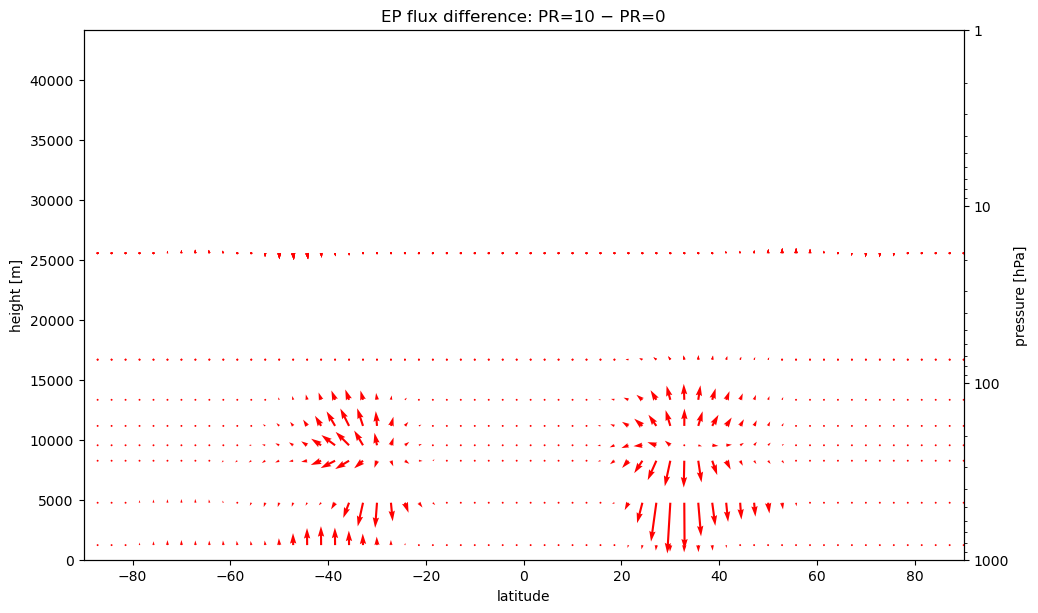

In [115]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

pres = np.array([850, 500, 300, 200, 150, 100, 70, 50, 30, 20, 10, 7, 5, 2])[::-1]
lat = same_pr_ep_diff[10][0].latitude  # 或 f1.latitude

fig, ax = plt.subplots()
set_size(8.8, 5.3, ax)
scale = "log"

# 取出差值資料
ep1_diff = same_pr_ep_diff[10][0].sel(latitude=lat, level=pres, method='nearest')
ep2_diff = same_pr_ep_diff[10][1].sel(latitude=lat, level=pres, method='nearest')
# 確保維度對齊（展平）
yy, xx = xr.broadcast(ep1_diff.level, ep1_diff.latitude)

if scale == 'log':
    _, _, axp = ac.PlotEPfluxArrows(
        xx.values, yy.values,
        -ep1_diff.values, -ep2_diff.values,
        fig, ax,
        xlim=[-90, 90],
        ylim=[1000, 1],
        yscale='log',
        newax=True,
        scale=3e15
    )
    axp.get_children()[0].set_facecolor('r')
    axp.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 6.4e3 * np.log(1000))
    ax.set_ylabel('height [m]')

plt.title('EP flux difference: PR=10 − PR=0')
ax.set_xlabel('latitude')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())


In [43]:
ep1_diff.values.min()

-1.1920928999487046e-07

In [49]:
ep2_diff.values.max()

2.220446049250313e-16

## Jucker EP flux batch

In [72]:
PR

50

In [102]:
import numpy as np
import xarray as xr
import h5py
import sys
import os
from tqdm import tqdm

# 匯入 Jucker 的工具
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

# === 設定參數 ===
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
chunk_size = 1000
a0 = 6376.0e3
lat_vals = np.linspace(90, -90, 64)
cosphi = np.cos(np.deg2rad(lat_vals))

# === 建立空間儲存區 ===
all_ep1 = []
all_ep2 = []
all_p_1d = []

# === 分段處理 ===
for start_idx in tqdm(range(0, 78000, chunk_size)):
    end_idx = min(start_idx + chunk_size, 78000)
    print(f"Processing: {start_idx} ~ {end_idx}")

    # 計算平均壓力 (ps、p為4D: time, level, lat, lon)
    p_1d = p[start_idx:end_idx].mean(axis=(0, 2, 3))

    # 計算 EP flux
    ep1, ep2 = ac.ComputeEPfluxDiv(lat_vals, p_1d / 100,
                                   u[start_idx:end_idx],
                                   v[start_idx:end_idx],
                                   t[start_idx:end_idx])
    
    all_ep1.append(ep1)  # shape: (time_chunk, level, lat)
    all_ep2.append(ep2)
    all_p_1d.append(p_1d)

# === 合併所有時間段 ===
ep1_all = np.concatenate(all_ep1, axis=0)
ep2_all = np.concatenate(all_ep2, axis=0)
time_len = ep1_all.shape[0]
time_coord = np.arange(time_len)
level_coord = np.mean(np.stack(all_p_1d), axis=0) / 100  # hPa

# === 存成 xarray ===
f1 = xr.DataArray(ep1_all, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": level_coord,
                          "latitude": lat_vals},
                  name="f1")

f2 = xr.DataArray(ep2_all, dims=["time", "level", "latitude"],
                  coords={"time": time_coord,
                          "level": level_coord,
                          "latitude": lat_vals},
                  name="f2")







  0%|                                                    | 0/78 [00:00<?, ?it/s]

Processing: 0 ~ 1000


  1%|▌                                           | 1/78 [00:12<16:10, 12.60s/it]

Processing: 1000 ~ 2000


  3%|█▏                                          | 2/78 [00:18<10:42,  8.45s/it]

...

 97%|█████████████████████████████████████████▉ | 76/78 [04:19<00:04,  2.26s/it]

Processing: 76000 ~ 77000


 99%|██████████████████████████████████████████▍| 77/78 [04:21<00:02,  2.19s/it]

Processing: 77000 ~ 78000


100%|███████████████████████████████████████████| 78/78 [04:23<00:00,  3.38s/it]


In [103]:
# 建立 Dataset，f1, f2 已經是 DataArray，不需再指定 shape
ds_out = xr.Dataset({
    "f1": f1,
    "f2": f2
})

# 儲存為 .nc 檔案（建議使用 .nc 而非 .h5，與 xarray 相容性較佳）
save_path = os.path.join(save_dir, f"ep_flux_PR{PR}.h5")
ds_out.to_netcdf(save_path)
print(f"✓ Saved to {save_path}")

✓ Saved to /data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/ep_flux_PR50.h5


# Check $N^2$

In [74]:
# Function to read data from HDF5
def Read_var_simple(var, PR):
    str_var = str(var)
    common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
    last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
    with h5py.File(common_path + last_path, 'r') as file:
        data = np.asarray(file[str_var][:])
    return data

In [80]:
N_square_all = np.zeros((6, 78000, 20, 64))
i = 0
g = 9.81
# Read zonal mean variables
for PR in range(0, 60, 10):
    theta_zonal_mean_all = Read_var_simple("theta", PR)
    dtheta_all           = Read_var_simple("dtheta", PR)
    dz_all               = Read_var_simple("dz", PR)
    # v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
    # EMF_all              = Read_var_simple("EMF", PR)
    
    # Calculate N squared
    dthetadz_all = dtheta_all / dz_all
    N_square_all[i] = g / theta_zonal_mean_all * dthetadz_all
    i += 1

KeyboardInterrupt: 

In [77]:
N_square_all.shape

(6, 78000, 20, 64)

In [146]:
def plot_contourf_near0_fixcolorbar_fig2_3(X, Y ,var_near0, axs, cbar_lim, shading_levels = 9, least_levels = 4, near0white = True, my_cmap = 'coolwarm'):
    from matplotlib.colors import ListedColormap
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    #####
    import matplotlib.colors as colors
    # a, antialiased = 0.6, True
#     a, antialiased = 0.7, True
    a, antialiased = 0.9, True
    # a, antialiased = 1, False
    
    my_cmap = plt.colormaps[my_cmap]  
    
    # create random data with cbar_lim
    rngdata = np.random.uniform(low=cbar_lim[0], high=cbar_lim[1], size=(len(Y),len(X)))
    
    # make sure the min and Max value are included
    rngdata[0,0] = cbar_lim[0]
    rngdata[-1,-1] = cbar_lim[1]

    # get contour levels with random data
    cs = axs.contourf(X, Y, rngdata, levels = 11, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels_rng = cs.levels.copy()
    plt.gca().clear()
    
    cs = axs.contourf(X, Y, var_near0, levels = auto_levels_rng, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels2 = cs.levels.copy()
    # cbar = add_colorbar(cs)#plt.colorbar()
    #plt.show()

    if ~((np.min(auto_levels2) >= 0) | (np.max(auto_levels2) <= 0)):
        plt.gca().clear()
        
        try:
            cbar.remove()
        except:
            pass
        
        # check levels of both ends
        # if either end has contour levels less than 'least_levels', create custom levels
        if ((len(np.where(auto_levels2 > 0)[0]) < least_levels) | (len(np.where(auto_levels2 < 0)[0]) < least_levels)):
            cs = plt.contourf(X,Y,var_near0, norm=TwoSlopeNorm(0), levels = np.linspace(auto_levels_rng.min(), auto_levels_rng.max(), 100))
            auto_levels1 = cs.levels.copy()
        #     plt.colorbar()
        #     plt.show()
            plt.gca().clear()
            if (len(np.where(auto_levels2 > 0)[0]) > len(np.where(auto_levels2 < 0)[0])):
                   custom_levels = np.concatenate((np.linspace(np.min(auto_levels1), 0, least_levels+1), 
                                    auto_levels2[auto_levels2 > 0]))

            else:
                   custom_levels = np.concatenate((auto_levels2[auto_levels2 < 0], 
                                               np.linspace(0,np.max(auto_levels1),least_levels+1)))

            #custom_levels = np.unique(custom_levels)
            custom_levels_bar = custom_levels
        else:

            custom_levels = auto_levels2
            custom_levels_bar = custom_levels

        # create white shading around 0
        if near0white:
            custom_lower = custom_levels[custom_levels < 0]
            dlevel_lower = custom_lower[1] - custom_lower[0]
            custom_lower_near0 = np.concatenate((custom_lower, [0 - dlevel_lower/5]))

            custom_upper = custom_levels[custom_levels > 0]
            dlevel_upper = custom_upper[1] - custom_upper[0]
            custom_upper_near0 = np.concatenate(([dlevel_upper/5 - 0] ,custom_upper))

            custom_levels_near0 = np.concatenate((custom_lower_near0, [0], custom_upper_near0))

            mycmap_lower_near0 = my_cmap(np.linspace(0, 0.5, len(custom_levels_near0[custom_levels_near0 < 0])))
            mycmap_upper_near0 = my_cmap(np.linspace(0.5, 1, len(custom_levels_near0[custom_levels_near0 >= 0])))[1:]
            all_colors = np.vstack((mycmap_lower_near0, mycmap_upper_near0))

            all_colors[np.where(custom_levels_near0 == 0)[0]] = [1, 1, 1, 1] # set to white
            all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [1, 1, 1, 1]
            
#             all_colors[np.where(custom_levels_near0 == 0)[0]] = [0.85, 0.85, 0.85, 1] # set to gray
#             all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [0.85, 0.85, 0.85, 1]

            #all_colors[:,0:3] *= a


            mycmap_near0 = colors.LinearSegmentedColormap.from_list('mycmap_near0', all_colors)

            custom_levels = custom_levels_near0
            mycmap = mycmap_near0
        else:
            mycmap = my_cmap


        norm = colors.BoundaryNorm(boundaries=custom_levels, ncolors=256)

        cs = axs.contourf(X, Y, var_near0, levels = custom_levels, cmap=mycmap, norm=norm, alpha = a, antialiased = antialiased)
        # cbar = plt.colorbar(cs, spacing="proportional")
        # cbar = add_colorbar(cs, aspect=8, pad_fraction=0.8)#

#         cbar.set_ticks(custom_levels_bar)
#         ticklabs = cbar.ax.get_yticklabels()
#         cbar.ax.set_yticklabels(ticklabs, fontsize=14)

        # axs.title("$N^2$ difference between L = Dry", fontsize=14)
        # plt.xlabel("Latitude")
        # ax.set_ylabel("Sigma")
        axs.set_ylim([1,0])
        # plt.xlim([0,70])


        
    #####
    return custom_levels, custom_levels_bar, cs

L = Dry, N^2.min(): -6.124469657428794e-05
L = Dry, N^2.max(): 0.0006177863715981209


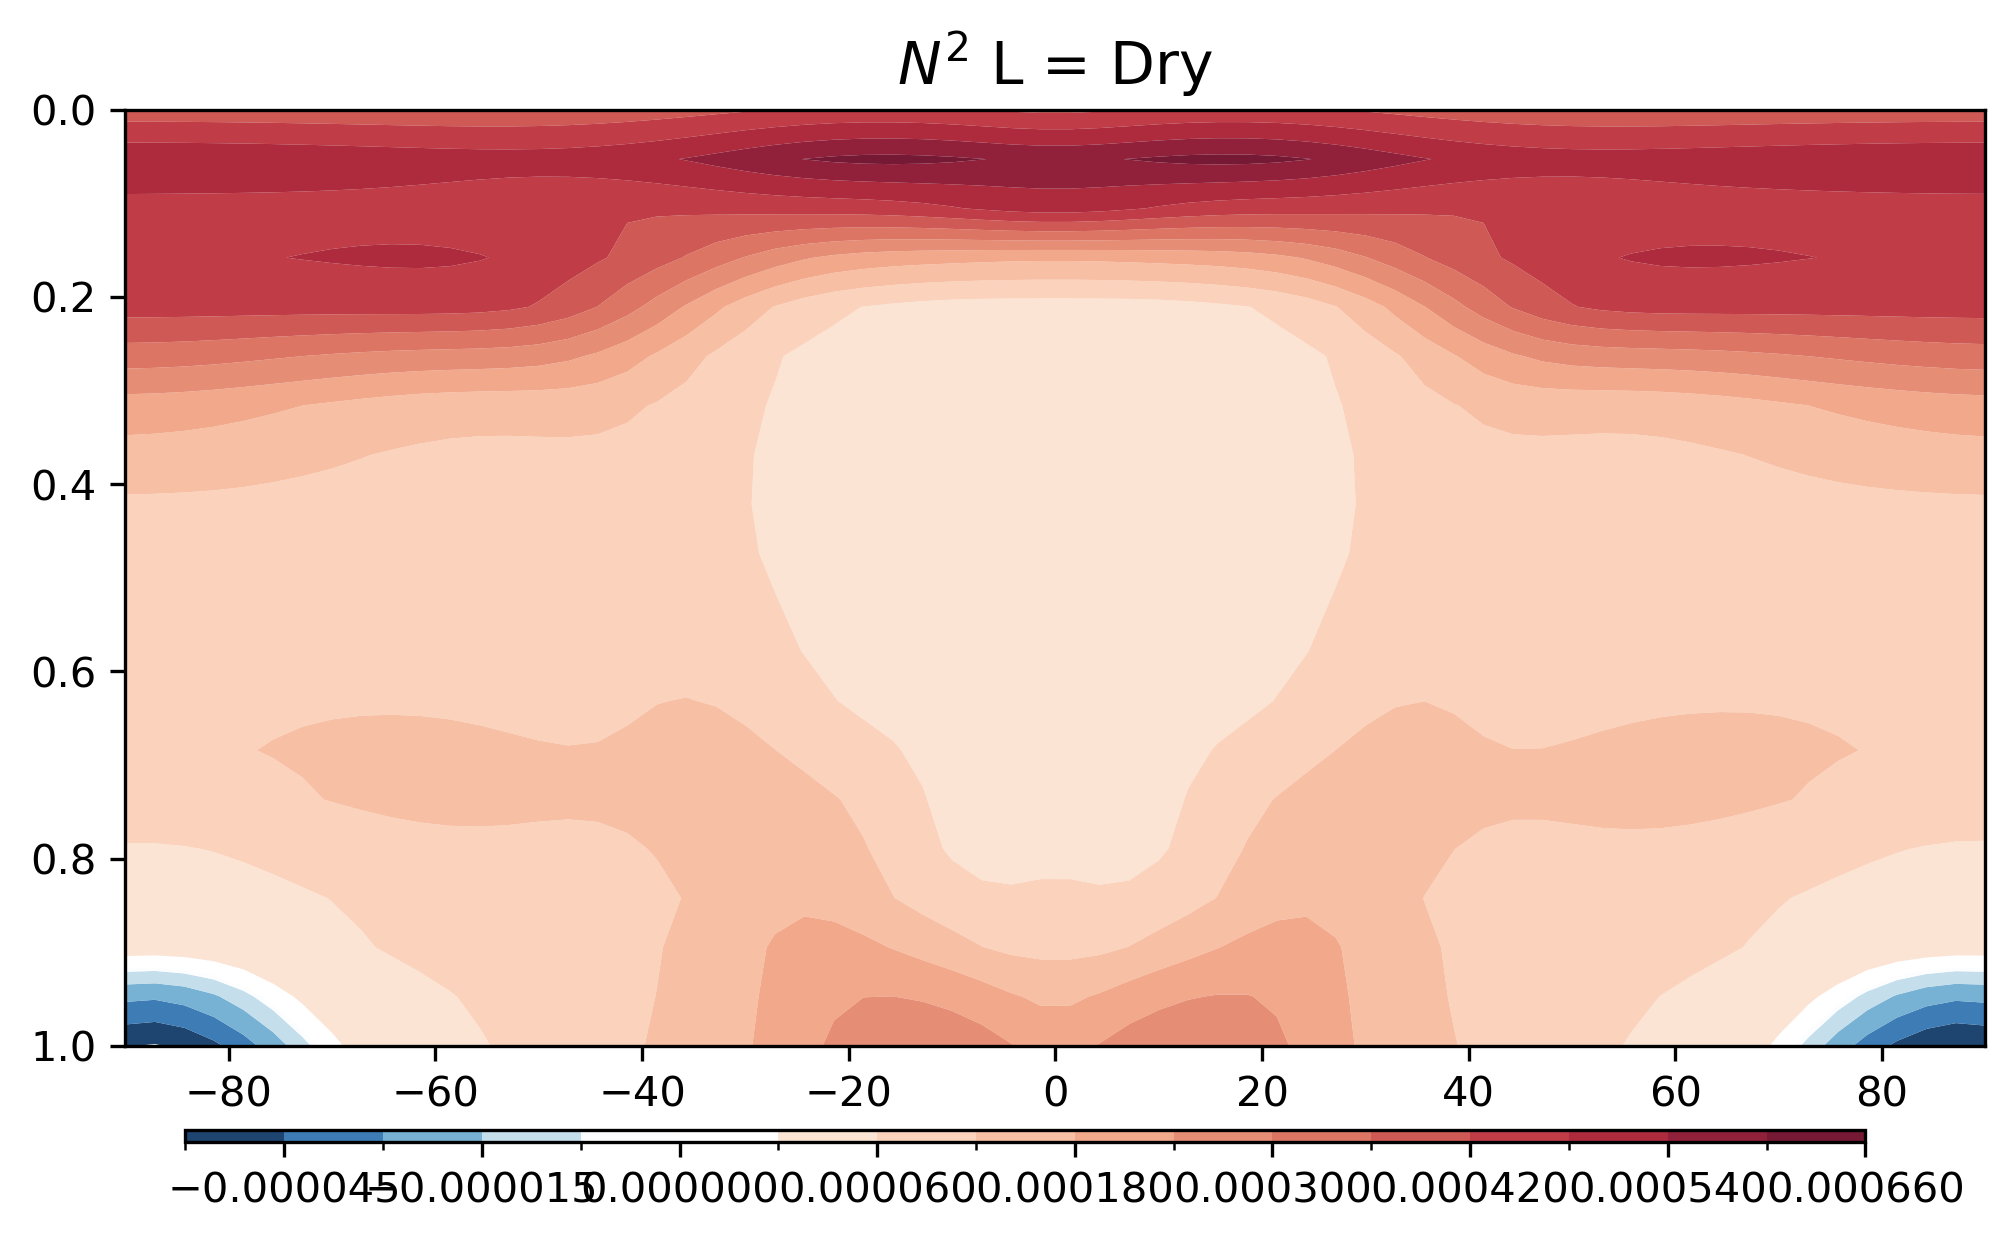

In [174]:
sigma = np.linspace(0,1,20)
y = np.linspace(-90,90,64)
fig, ax = plt.subplots(1, figsize=(8,4), dpi=300.)

# For storing cs to use for colorbar later
cs_for_colorbar = None

_, custom_levels_bar2, cs = plot_contourf_near0_fixcolorbar_fig2_3(
    y, sigma, N_square_all[0,5000*4:].mean(axis=0), ax, 
    cbar_lim=[-5E-5, 6.1E-4],
    my_cmap='RdBu_r'
)
plt.title("$N^2$ L = Dry", fontsize=14)
cs_for_colorbar = cs  # store the last cs

# Add a horizontal colorbar below the last axis
fig.subplots_adjust(bottom=0.1)  # adjust as needed
cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.01])  # [left, bottom, width, height]
fig.colorbar(cs_for_colorbar, cax=cbar_ax, orientation='horizontal')
print("L = Dry, N^2.min():", N_square_all[0,5000*4:].mean(axis=0).min())
print("L = Dry, N^2.max():", N_square_all[0,5000*4:].mean(axis=0).max())


-1.9842596768561763e-05
4.682385210088918e-05
-5.008153503806742e-05
7.510465274876275e-05
-8.391108011026761e-05
9.540901275533246e-05
-0.00010323475817430554
0.0001182973797827431
-0.00012576956493570132
0.00013776118802514737


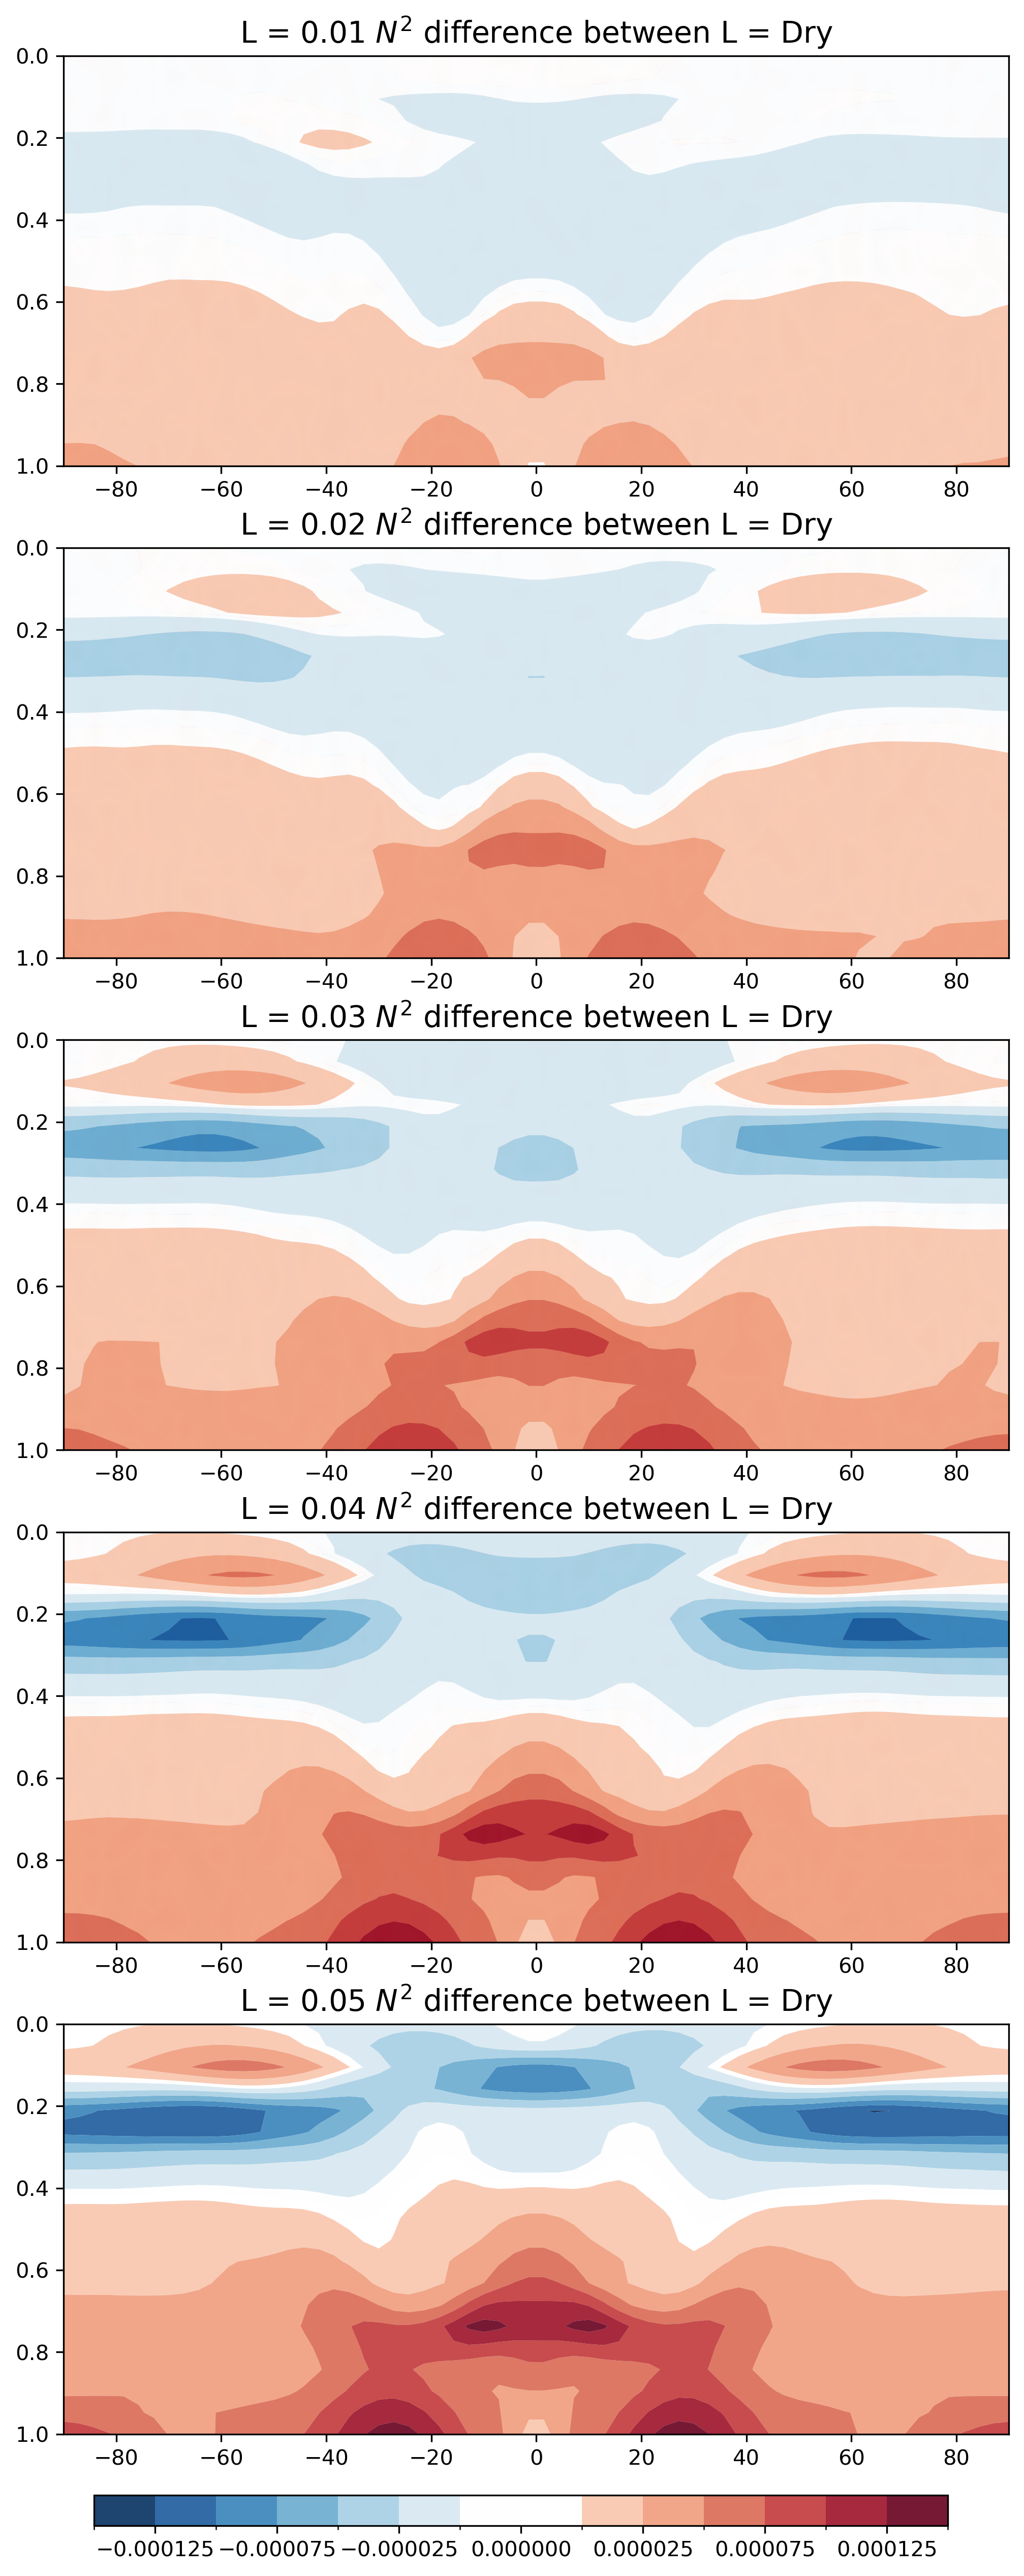

In [175]:
sigma = np.linspace(0,1,20)
y = np.linspace(-90,90,64)
fig, ax = plt.subplots(5, figsize=(8,20), dpi=300.)

# For storing cs to use for colorbar later
cs_for_colorbar = None

for i in range(5):
    N_square_diff = N_square_all[i+1,5000*4:].mean(axis=0) - N_square_all[0,5000*4:].mean(axis=0)
    _, custom_levels_bar2, cs = plot_contourf_near0_fixcolorbar_fig2_3(
        y, sigma, N_square_diff, ax[i], 
        cbar_lim=[-1.5E-4, 1.5E-4],
        my_cmap='RdBu_r'
    )
    ax[i].set_title(f"L = {(i+1)*0.01} $N^2$ difference between L = Dry", fontsize=14)
    cs_for_colorbar = cs  # store the last cs
    print(N_square_diff.min())
    print(N_square_diff.max())
    

# Add a horizontal colorbar below the last axis
fig.subplots_adjust(bottom=0.1)  # adjust as needed
cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.01])  # [left, bottom, width, height]
fig.colorbar(cs_for_colorbar, cax=cbar_ax, orientation='horizontal')


In [44]:
# Constant
f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90,90,64)))
g  = 9.81

In [52]:
ehf.shape

(400, 20, 64, 128)

In [59]:
# EP flux j and k component
F_j =  emf.mean(axis=(0,3)) # np.mean(EMF, axis=(0,3))
F_k = (f0[np.newaxis, np.newaxis, :] * ehf.mean(axis=3) / N_square_test_all).mean(axis=0)

In [60]:
F_j.shape

(20, 64)

(1.0, 0.0)

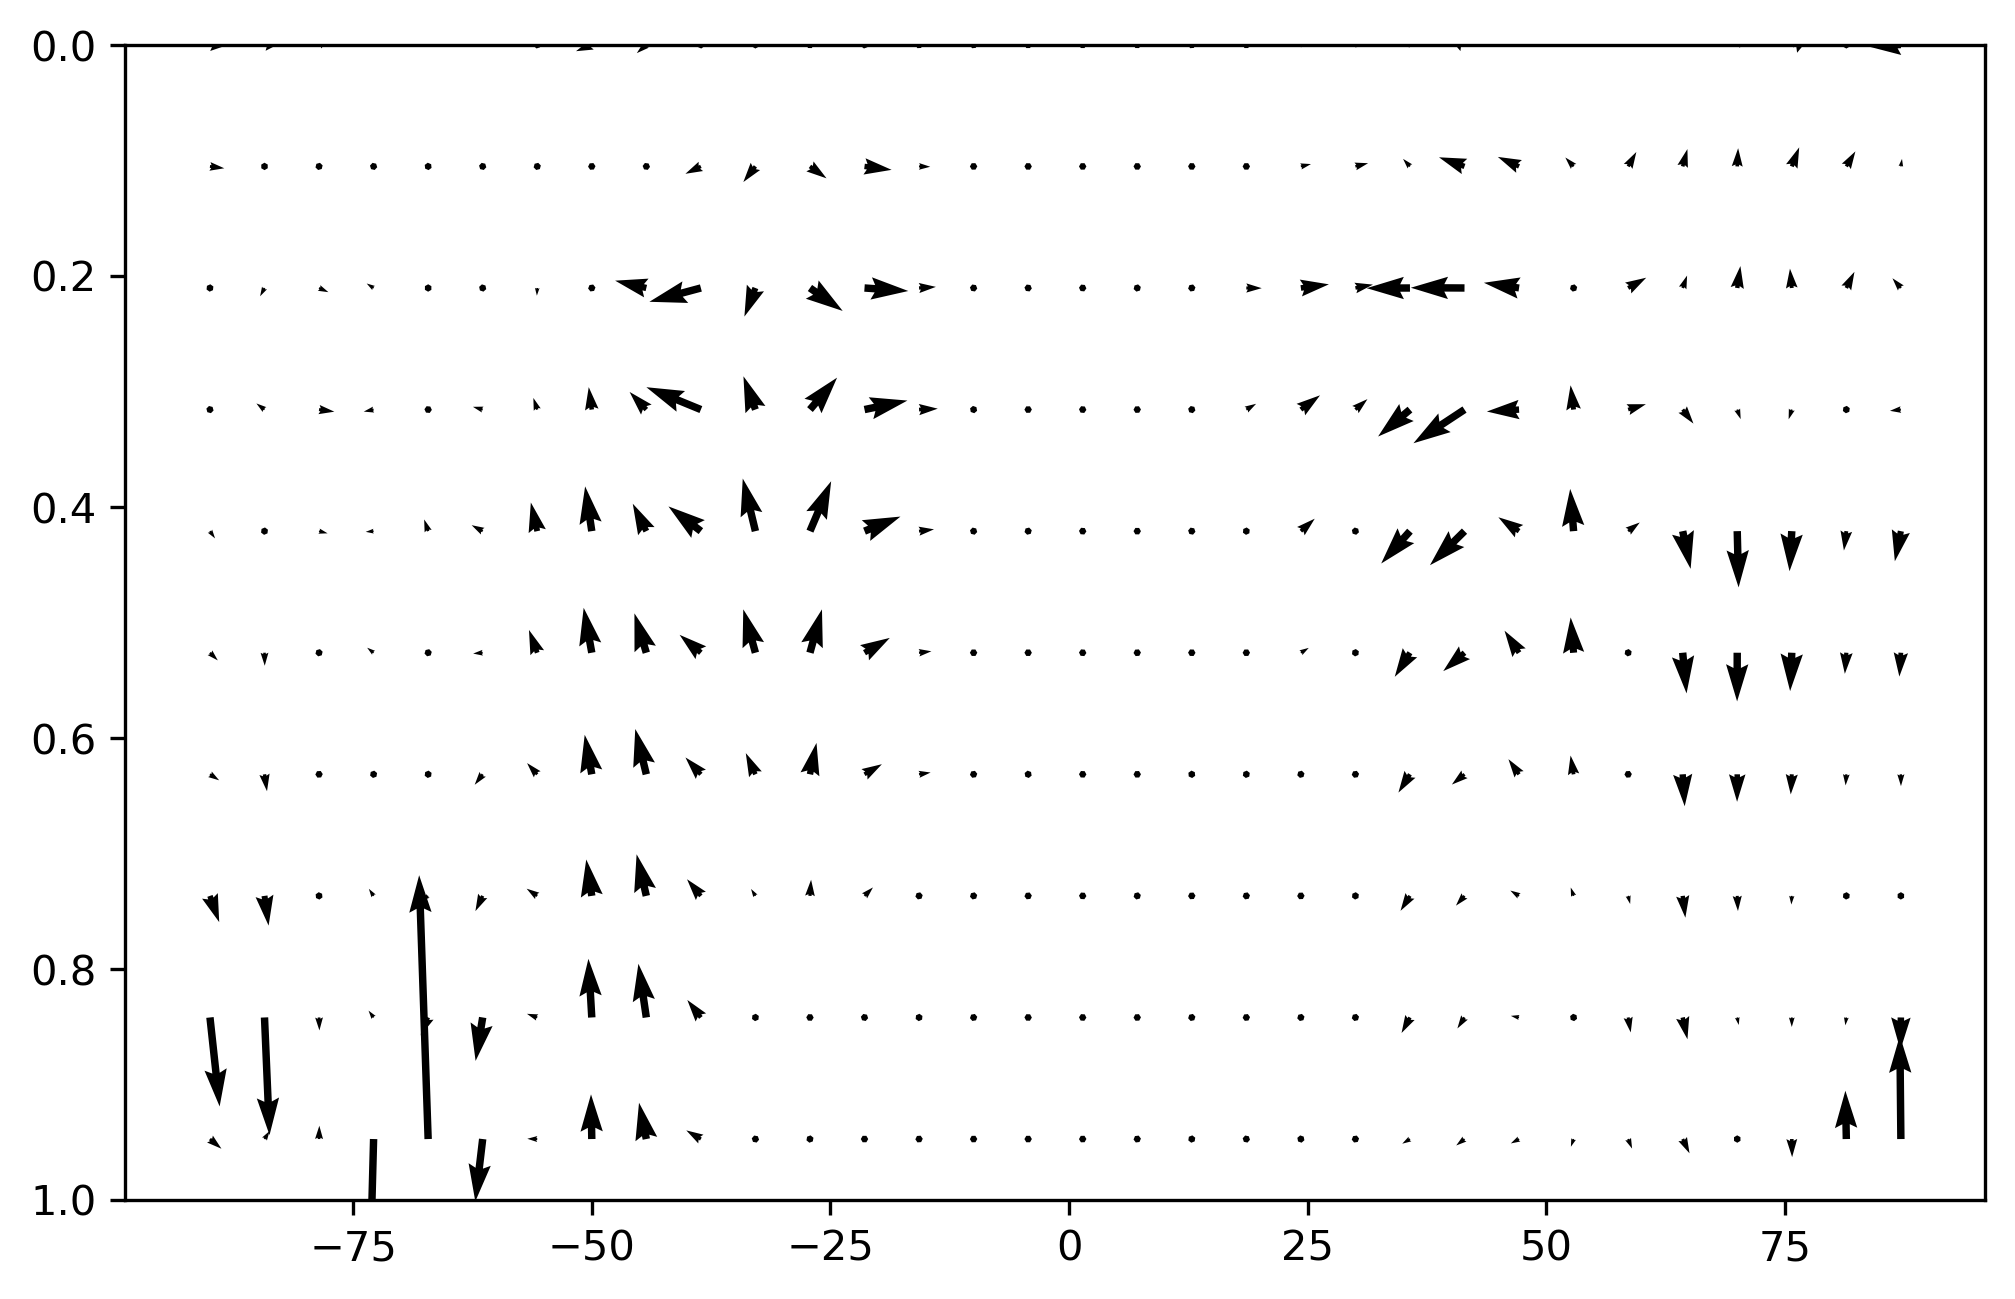

In [61]:
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=300)
y = np.linspace(-90,90,64)
z = np.linspace(0,1,20)
yy, zz = np.meshgrid(y,z)
wind_plt = ax.quiver(yy[::2, ::2], zz[::2, ::2], -F_j[::2, ::2], F_k[::2, ::2],
          color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)
plt.ylim([1,0])

# Cal EP flux again 05/22

In [388]:
PR = 0
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")

In [389]:
time_idx_array_positive[:]

array([ 1090,  1091,  1092, ..., 77560, 77561, 77562])

## EMF and EHF

In [392]:
start_idx = 50000
end_idx   = 52000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
emf_mean, ehf_mean = adiag.run_emf_ehf()
emf_mean.shape

[########################################] | 100% Completed | 413.71 ms
[########################################] | 100% Completed | 2.43 sms


(2000, 20, 64, 128)

Text(0.5, 1.0, "EHF ($\\overline{v'Th'}$)")

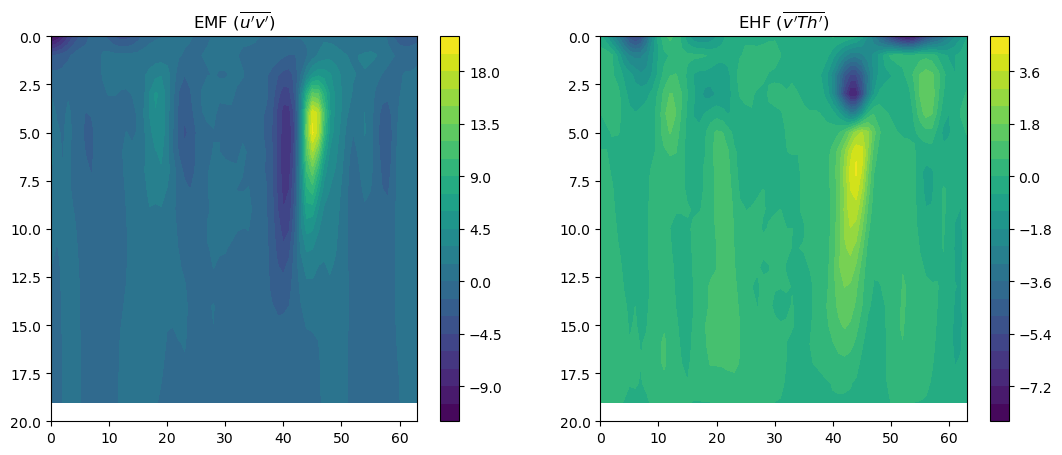

In [393]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(emf_mean.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"EMF ($\overline{u'v'}$)")

cs2 = ax2.contourf(ehf_mean.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title("EHF ($\overline{v'Th'}$)")



## $\theta$ and $\partial \theta$

In [558]:
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
theta = adiag.cal_theta()  
dtheta_dp = adiag.Cal_dtheta_dp() 


In [559]:
dtheta_dp.shape

(20, 64)

Text(0.5, 1.0, '$\\partial \\theta$ / dp')

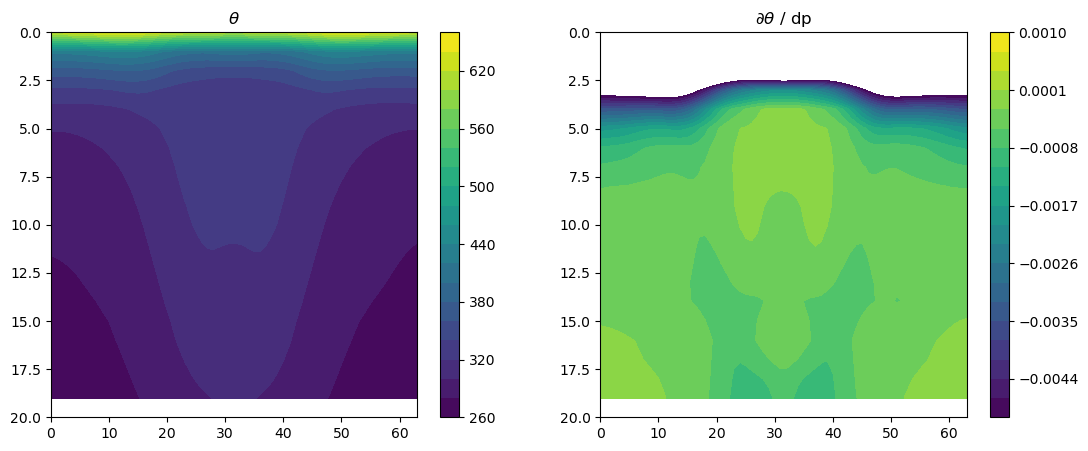

In [560]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(theta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"$\theta$")

cs2 = ax2.contourf(dtheta_dp, levels=np.linspace(-0.005,0.001,21))
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial \theta$ / dp")



In [561]:
# dx_along_axis
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
theta = adiag.cal_theta()  
print(theta.shape)
dtheta, dtheta_zm = adiag.dx_along_axis(theta, axis=1) 


(2000, 20, 64, 128)


AttributeError: 'AtmosphericDiagnostics' object has no attribute 'dx_along_axis'

Text(0.5, 1.0, '$\\partial \\theta$')

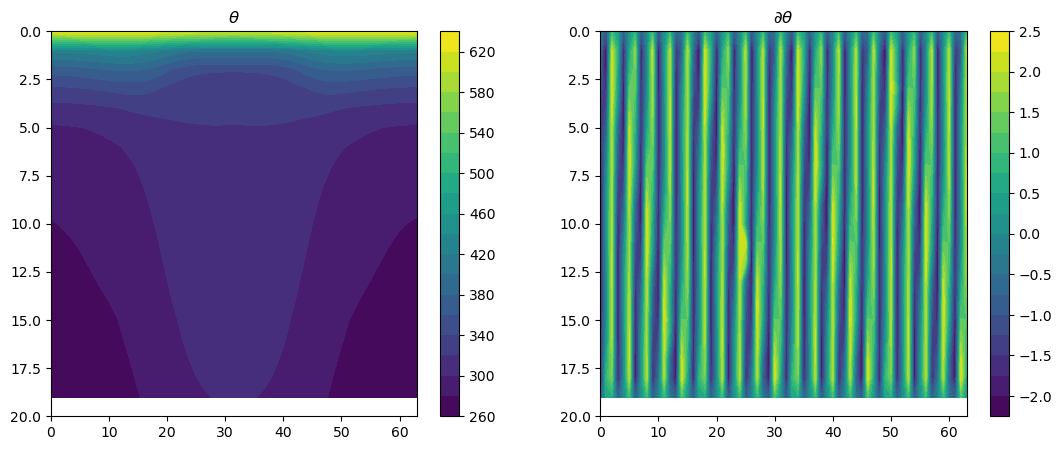

In [30]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(theta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"$\theta$")

cs2 = ax2.contourf(dtheta.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial \theta$")



In [25]:
adiag = AtmosphericDiagnostics(u[2000:4000], v[2000:4000], t[2000:4000], p[2000:4000], z[2000:4000])
dz, dz_zm = adiag.dx_along_axis(z[2000:4000], axis=1) 

Computing ∂(x)/∂(axis 1) ...


Text(0.5, 1.0, '$\\partial z$')

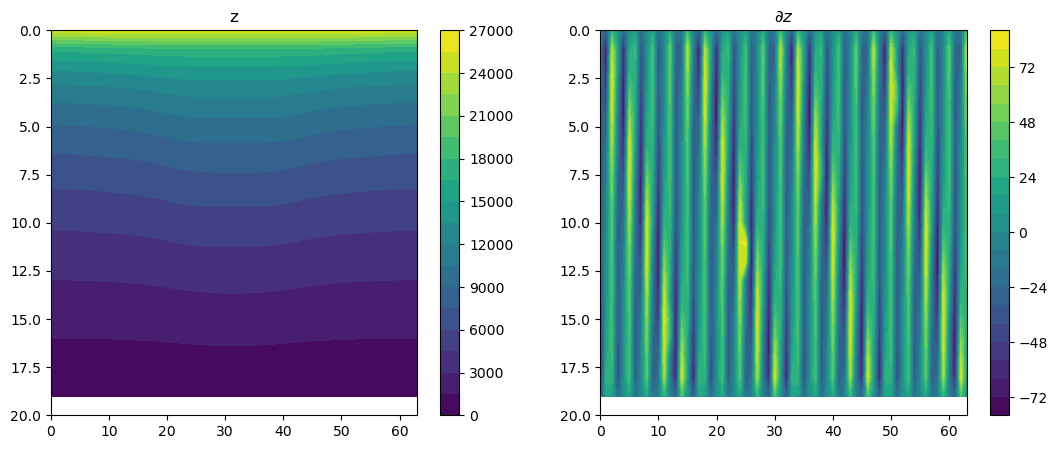

In [26]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(z.mean(axis=(0,3)), levels=21)
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"z")

cs2 = ax2.contourf(dz.mean(axis=(0,3)), levels=21)
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"$\partial z$")



## Cal N2

In [332]:
start_idx = 2000
end_idx   = 4000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
N2 = adiag.Cal_N_square()

AttributeError: 'AtmosphericDiagnostics' object has no attribute 'Cal_N_square'

In [77]:
print(N2.min(), N2.max())

-0.054796669637423495 0.0001746187713322982


In [78]:
f0_array = adiag.f0()[np.newaxis, np.newaxis, :, np.newaxis]
ratio = f0_array / N2

print("N² min/max:", np.nanmin(N2), np.nanmax(N2))
print("f₀/N² min/max/mean:", np.nanmin(ratio), np.nanmax(ratio), np.nanmean(ratio))

ValueError: operands could not be broadcast together with shapes (1,1,64,1) (1,20,64) 

AxisError: axis 3 is out of bounds for array of dimension 3

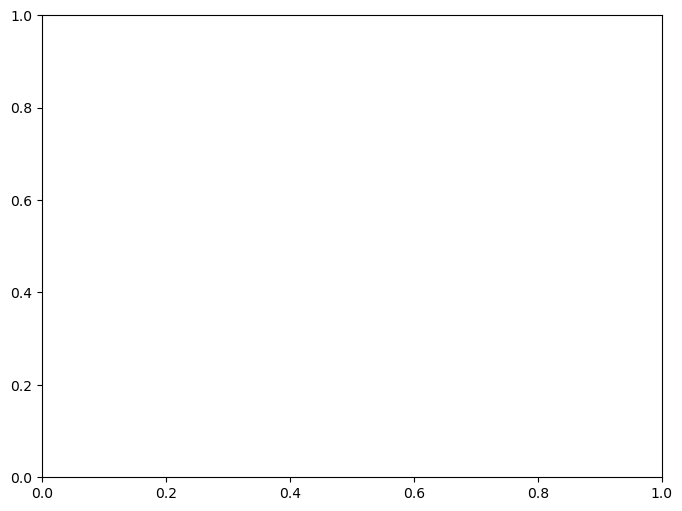

In [79]:
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf(N2.mean(axis=(0,3)), levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title("$N^2$")

In [85]:
N2.shape

(1, 20, 64)

Text(0.5, 1.0, '$f0/N^2$')

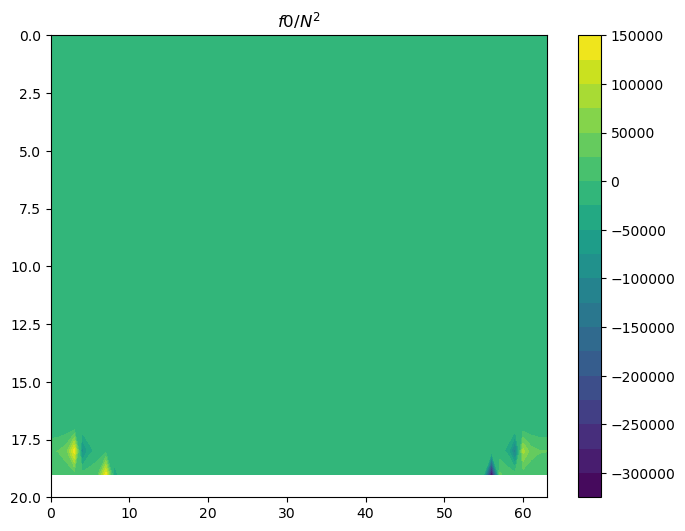

In [88]:
lat = adiag.lat
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf(1/(N2).mean(axis=(0)) , levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title("$f0/N^2$")

## $\partial \theta \over \partial p$

In [1132]:
start_idx = 2000
end_idx   = 4000
adiag = AtmosphericDiagnostics(u[start_idx:end_idx], v[start_idx:end_idx], t[start_idx:end_idx], p[start_idx:end_idx], z[start_idx:end_idx])
dtheta_dp = adiag.dtheta_dp_columnwise()

Text(0.5, 1.0, '$\\frac{\\partial \\theta}{\\partial p}$')

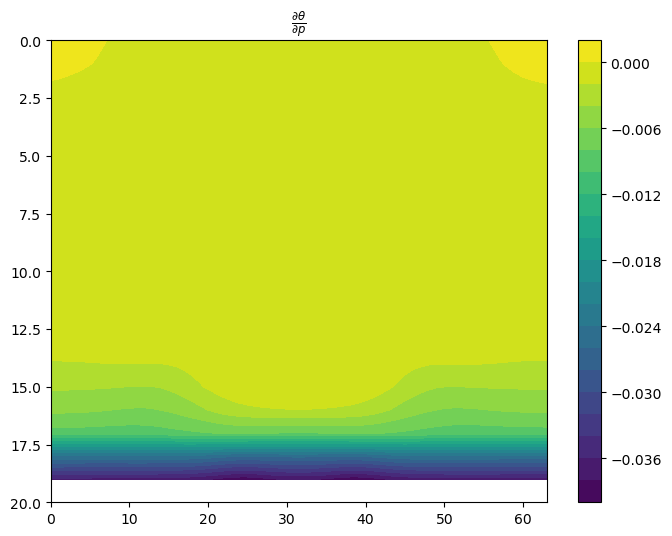

In [1149]:
fig, ax = plt.subplots(dpi=100., figsize=(8,6))
plt.contourf((dtheta_dp).mean(axis=(0,3)) , levels=21)
plt.colorbar()
plt.ylim([20,0])
plt.title(r"$\frac{\partial \theta}{\partial p}$")


# EP flux 

In [394]:
start_idx = 30000
end_idx   = 32000
PR = 0
# with h5py.File(os.path.join(save_dir, f"ep_flux_PR{PR}.h5"), "r") as f:
#     Fj = f["Fj"][:]
#     Fk = f["Fk"][:]
    
time_idx_array_positive = np.load(f"New_PC1_time_idx/PC1_positive_1std_PR{PR}.npz")["time_idx_pos"][:]
time_idx_array_negative = np.load(f"New_PC1_time_idx/PC1_negative_1std_PR{PR}.npz")["time_idx_neg"][:]
# print(time_idx_array_positive.keys())
lag = 15*4
time_idx_array_positive_lag = time_idx_array_positive + lag
time_idx_array_positive_lag = time_idx_array_positive_lag[time_idx_array_positive_lag < 78000]
print(time_idx_array_positive_lag.shape)




(12481,)


In [395]:
time_idx_array_positive

array([[  391,   392,   393, ..., 77217, 77218, 77219]])

In [396]:
u.shape

(78000, 20, 64, 128)

In [397]:
adiag = AtmosphericDiagnostics(u[time_idx_array_positive_lag, :, :, :], 
                               v[time_idx_array_positive_lag, :, :, :], 
                               t[time_idx_array_positive_lag, :, :, :], 
                               p[time_idx_array_positive_lag, :, :, :], 
                               z[time_idx_array_positive_lag, :, :, :])
Fj, Fk, dtheta_dp  = adiag.ep_flux()

[########################################] | 100% Completed | 113.81 s
[########################################] | 100% Completed | 43.22 s


In [613]:
Fk.shape

(20, 64)

In [398]:
Fj_mean = Fj  # shape: (z, y)
Fk_mean = Fk  # shape: (z, y)
Fk_mean.shape

(20, 64)

In [399]:
print(Fj_mean.min(), Fj_mean.max(), Fj_mean.mean())
print(Fk_mean.min(), Fk_mean.max(), Fk_mean.mean())


-6.295452 5.025795 -0.15055051
-0.979912861383172 1.0869773459584906 0.015800663524223733


Text(0.5, 1.0, 'Fk')

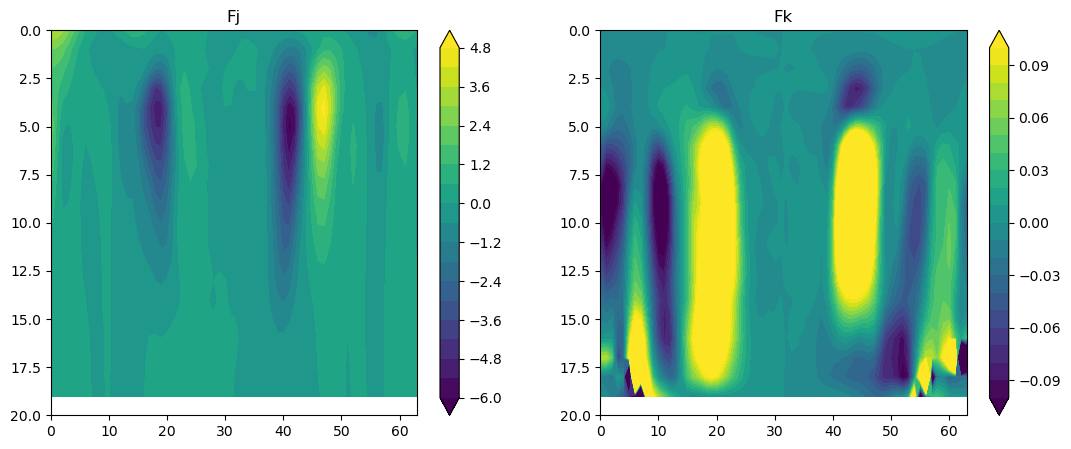

In [401]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf(Fj_mean, levels=21, extend="both")
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"Fj")


from scipy.ndimage import gaussian_filter
sigma = 1  # Standard deviation for the Gaussian kernel
Fk_mean_filtered = gaussian_filter(Fk_mean, sigma=sigma)
cs2 = ax2.contourf(Fk_mean, levels=np.linspace(-0.1,0.1,21), extend="both")
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"Fk")



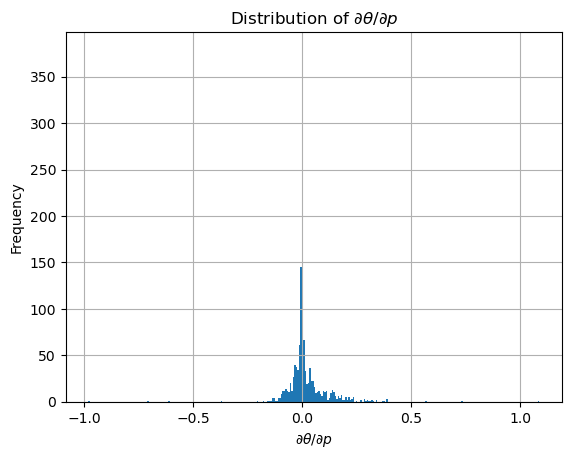

1.0869773459584906

In [402]:
Fk_mean_test = Fk_mean.flatten()
plt.figure()
plt.hist(Fk_mean_test, bins=300)  # 排除 NaN 比較乾淨
plt.xlabel(r"$\partial \theta / \partial p$")
plt.ylabel("Frequency")
plt.title("Distribution of $\\partial \\theta / \\partial p$")
plt.grid(True)
# plt.xlim([-20,20])
plt.show()
Fk_mean.max()

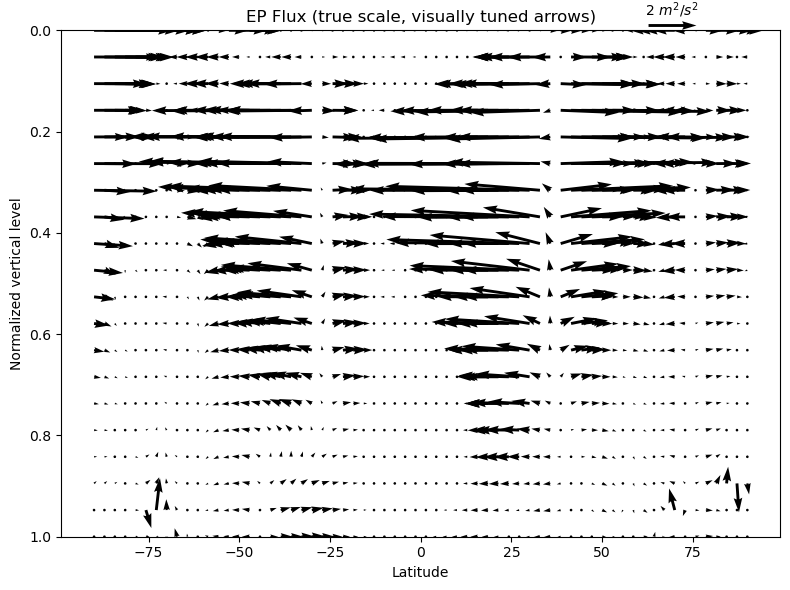

In [403]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt(Fj_mean**2 + Fk_mean**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 15 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)

fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_mean[::, ::], Fk_mean[::, ::],
    color="black", width=4e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

ax.set_ylim([1, 0])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


# Batch calculate EP flux and Save

In [175]:
import os
import h5py
import numpy as np

# 設定儲存資料夾與 PR 名稱
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
# PR = 50  # <-- 請依你的需求設定
batch_size = 10000
n_total = 78000

# 儲存每段的 Fj 與 Fk
Fj_list = []
Fk_list = []

# 分段計算 EP flux
for start_idx in range(0, n_total, batch_size):
    end_idx = min(start_idx + batch_size, n_total)
    print(f"Processing {start_idx} ~ {end_idx}")

    # 初始化這段的 AtmosphericDiagnostics
    adiag = AtmosphericDiagnostics(
        u[start_idx:end_idx],
        v[start_idx:end_idx],
        t[start_idx:end_idx],
        p[start_idx:end_idx],
        z[start_idx:end_idx]
    )

    # 計算 EP flux
    Fj, Fk = adiag.ep_flux()
    Fj_list.append(Fj)
    Fk_list.append(Fk)

# 拼接所有段落結果
Fj_all = np.concatenate(Fj_list, axis=0)
Fk_all = np.concatenate(Fk_list, axis=0)

# 儲存為 HDF5
with h5py.File(os.path.join(save_dir, f"ep_flux_PR{PR}.h5"), "w") as f:
    f.create_dataset("Fj", data=Fj_all)
    f.create_dataset("Fk", data=Fk_all)

print("✅ EP flux 所有分段處理完畢並成功儲存！")


Processing 0 ~ 10000
EMF and EHF progress:
[########################################] | 100% Completed | 1.57 sms
[########################################] | 100% Completed | 1.25 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 10000 ~ 20000
EMF and EHF progress:
[########################################] | 100% Completed | 1.88 sms
[########################################] | 100% Completed | 1.92 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 20000 ~ 30000
EMF and EHF progress:
[########################################] | 100% Completed | 1.94 sms
[########################################] | 100% Completed | 1.48 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 30000 ~ 40000
EMF and EHF progress:
[########################################] | 100% Completed | 1.34 sms
[########################################] | 100% Completed | 1.34 sms
Fj.shape: (10000, 20, 64)
Fk.shape: (10000, 20, 64)
Processing 40000 ~ 50000
EMF and EHF pro

# Calculate EP flux composite with time index lagged of extreme PC 

In [270]:
PR = 0
with h5py.File(os.path.join(save_dir, f"ep_flux_PR{PR}.h5"), "r") as f:
    # print(f.keys())
    Fj = f["f1"][:]
    Fk = f["f2"][:]
    
time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")


In [271]:
Fj.shape

(78000, 20, 64)

In [272]:
def Cal_EOF_PC_for_barotropic(input_data):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF
    # input : (time, y)
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    print("n_component:", n_component)
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    
    # Compute EOFs and PCs
    eof_instance.get()
    
    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

In [273]:
EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(u[:,:,32:].mean(axis=(1,3)))


n_component: 32


In [274]:
# EOF1 *= -1 
# PC1  *= -1 

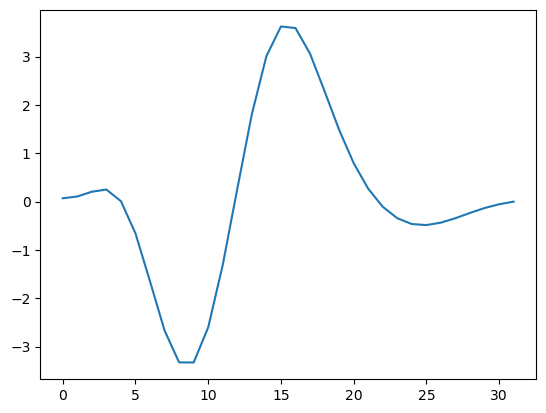

In [275]:
plt.figure()
plt.plot(EOF1)



In [276]:
time_idx_pos_test = np.where(PC1 >  PC1.std() * 1 + PC1.mean())
time_idx_neg_test = np.where(PC1 <  -PC1.std() * 1 + PC1.mean())

In [277]:
time_idx_pos_test[0]

array([  391,   392,   393, ..., 77217, 77218, 77219])

In [278]:
time_idx_pos_test

(array([  391,   392,   393, ..., 77217, 77218, 77219]),)

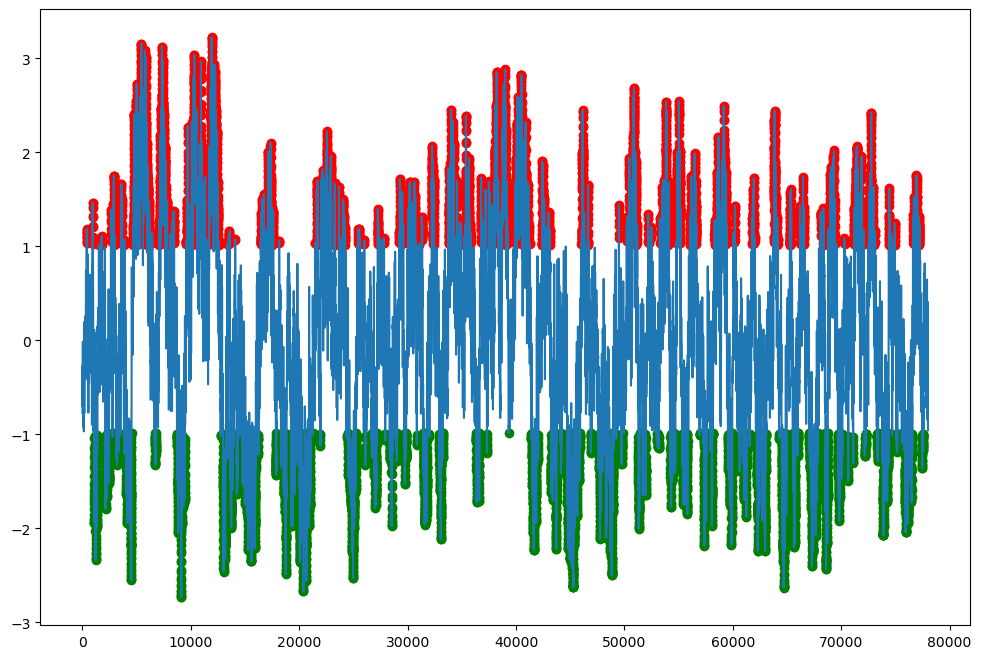

In [279]:
# Select the values from PC1[0] that satisfy the condition
PC1_big = PC1[time_idx_pos_test]
PC1_sml = PC1[time_idx_neg_test]

x = np.linspace(0,360,128)
y = np.linspace(-90,90,64)
xx,yy = np.meshgrid(x,y)
days = np.linspace(0,78000,78000)

# Plot the data
plt.figure(figsize=(12,8), dpi=100.)
plt.plot(days, PC1)
plt.scatter(days[time_idx_pos_test], PC1_big, color="red")
# plt.scatter(days[PC1_big_indices[0]-500], PC1_big, color="Orange")
# plt.scatter(days[PC1_big_indices[0]-50], PC1_50[PC1_big_indices[0]-50], color="Purple")
# plt.scatter(days[PC1_big_indices[0]+100], PC1_50[PC1_big_indices[0]+100], color="Orange")


plt.scatter(days[time_idx_neg_test], PC1_sml, color="green")
plt.show()

In [532]:
u.shape

(78000, 20, 64, 128)

In [170]:
Fk.shape

(78000, 20, 64)

In [110]:
# # Re-import necessary libraries after reset
# import os
# import numpy as np
# import xarray as xr
# import h5py

def load_ep_flux_data(pr, save_dir):
    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        print(f.keys())
        Fj = f["f1"][:]  # (time, level, lat)
        Fk = f["f2"][:]
    return Fj, Fk

def composite_mean(F, time_idx_array, lags):
    # samples = []
    # for idx in time_idx_array:
    #     for lag in lags:
    #         t_idx = idx + lag
    #         t_idx [t_idx<F.shape[0]]
    #         if 0 <= t_idx < F.shape[0]:
    #             samples.append(F[t_idx])

    # print(len(samples))
    # return np.mean(samples, axis=0)
    samples = []
    for lag in lags:
        time_idx_array_lag = time_idx_array + lag
        time_idx_array_lag = time_idx_array_lag[time_idx_array_lag<F.shape[0]]
        samples.append(F[time_idx_array_lag].mean(axis=0))
    print(len(samples))
    return np.mean(samples, axis=0)
    

# Configuration
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"

pr_list = [10]
lags_5_20 = np.arange(10*4, 20*4+1, 1)
lags_30_60 = np.arange(90*4, 100*4+1, 1)

# Output
same_pr_ep_diff = {}

for pr in pr_list:
    print(f"\nLoading EP flux data for PR={pr}...")
    Fj, Fk = load_ep_flux_data(pr, save_dir)

    print(f"Loading time indices for PR={pr}...")
    time_idx_pos = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{pr}.npy")
    time_idx_neg = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{pr}.npy")
    print(time_idx_pos.shape)
    print(time_idx_neg.shape)
    
    print("--> Computing EP+ composite...")
    ep1_pos = composite_mean(Fj, time_idx_pos, lags_5_20)
    ep2_pos = composite_mean(Fk, time_idx_pos, lags_5_20)
    ep1_far_pos = composite_mean(Fj, time_idx_pos, lags_30_60)
    ep2_far_pos = composite_mean(Fk, time_idx_pos, lags_30_60)

    EP_plus   = ep1_pos - ep1_far_pos
    EP_plus_p = ep2_pos - ep2_far_pos

    print("--> Computing EP- composite...")
    ep1_neg = composite_mean(Fj, time_idx_neg, lags_5_20)
    ep2_neg = composite_mean(Fk, time_idx_neg, lags_5_20)
    ep1_far_neg = composite_mean(Fj, time_idx_neg, lags_30_60)
    ep2_far_neg = composite_mean(Fk, time_idx_neg, lags_30_60)

    EP_minus   = ep1_neg - ep1_far_neg
    EP_minus_p = ep2_neg - ep2_far_neg

    diff_phi = EP_plus   - EP_minus
    diff_p   = EP_plus_p - EP_minus_p

    same_pr_ep_diff[pr] = (diff_phi, diff_p)

    # Create xarray Dataset and save
    level = np.linspace(1000, 100000, diff_phi.shape[0])
    lat = np.linspace(-90, 90, diff_phi.shape[1])
    ds = xr.Dataset({
        f"EP_phi_diff_PR{pr}": (["level", "lat"], diff_phi),
        f"EP_p_diff_PR{pr}":   (["level", "lat"], diff_p)
    }, coords={"level": level, "lat": lat})

    save_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR10.nc"
    print(f"Saving composite diff to {save_path}...")
    ds.to_netcdf(save_path)
    print("✓ Save complete.")



Loading EP flux data for PR=10...
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
Loading time indices for PR=10...
(13189,)
(12417,)
--> Computing EP+ composite...
41
41
41
41
--> Computing EP- composite...
41
41
41
41
Saving composite diff to /data92/PeterChang/back_to_master1220/Moist_Dycore/same_pr_ep_diff_PR10.nc...
✓ Save complete.


In [49]:
lags_30_60

array([360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372,
       373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385,
       386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398,
       399, 400])

## Try to plot same pr ep diff

In [111]:
def load_ep_flux_data_same_pr(pr, save_dir):
    with h5py.File(os.path.join(save_dir, f"same_pr_ep_diff_PR{pr}.nc"), "r") as f:
        print(f.keys())
        Fj = f[f"EP_p_diff_PR{pr}"][:]  # (time, level, lat)
        Fk = f[f"EP_phi_diff_PR{pr}"][:]
    return Fj, Fk

In [27]:
def load_ep_flux_data(pr, save_dir):
    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        print(f.keys())
        Fj = f["f1"][:]  # (time, level, lat)
        Fk = f["f2"][:]
        level = f["level"][:]
        time  = f["time"][:]
    return Fj, Fk, level, time

In [113]:
save_dir_same_pr = "/data92/PeterChang/back_to_master1220/Moist_Dycore/"

# pr = 0
Fj_pr0, Fk_pr0   = load_ep_flux_data_same_pr(0, save_dir_same_pr)
Fj_pr10, Fk_pr10 = load_ep_flux_data_same_pr(10, save_dir_same_pr)
Fj_pr20, Fk_pr20 = load_ep_flux_data_same_pr(20, save_dir_same_pr)
Fj_pr30, Fk_pr30 = load_ep_flux_data_same_pr(30, save_dir_same_pr)
Fj_pr40, Fk_pr40 = load_ep_flux_data_same_pr(40, save_dir_same_pr)
Fj_pr50, Fk_pr50 = load_ep_flux_data_same_pr(50, save_dir_same_pr)




<KeysViewHDF5 ['EP_p_diff_PR0', 'EP_phi_diff_PR0', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR10', 'EP_phi_diff_PR10', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR20', 'EP_phi_diff_PR20', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR30', 'EP_phi_diff_PR30', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR40', 'EP_phi_diff_PR40', 'lat', 'level']>
<KeysViewHDF5 ['EP_p_diff_PR50', 'EP_phi_diff_PR50', 'lat', 'level']>


In [28]:
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
Fj_pr0, Fk_pr0, level, time   = load_ep_flux_data(0, save_dir)
Fj_pr10, Fk_pr10, level, time = load_ep_flux_data(10, save_dir)
Fj_pr20, Fk_pr20, level, time = load_ep_flux_data(20, save_dir)
Fj_pr30, Fk_pr30, level, time = load_ep_flux_data(30, save_dir)
Fj_pr40, Fk_pr40, level, time = load_ep_flux_data(40, save_dir)
Fj_pr50, Fk_pr50, level, time = load_ep_flux_data(50, save_dir)

<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>


In [114]:
Fj_pr0.shape

(20, 64)

In [503]:
Fj_mean_pr0 = Fj_pr0.mean(axis=0)
Fk_mean_pr0 = Fk_pr0.mean(axis=0)

Fj_mean_pr10 = Fj_pr10.mean(axis=0)
Fk_mean_pr10 = Fk_pr10.mean(axis=0)

Fj_mean_pr20 = Fj_pr20.mean(axis=0)
Fk_mean_pr20 = Fk_pr20.mean(axis=0)

Fj_mean_pr30 = Fj_pr30.mean(axis=0)
Fk_mean_pr30 = Fk_pr30.mean(axis=0)

Fj_mean_pr40 = Fj_pr40.mean(axis=0)
Fk_mean_pr40 = Fk_pr40.mean(axis=0)

Fj_mean_pr50 = Fj_pr50.mean(axis=0)
Fk_mean_pr50 = Fk_pr50.mean(axis=0)
# Fj_mean = Fj_pr0
# Fk_mean = Fk_pr0



In [500]:
Fj_mean_diff_pr10 = Fj_mean_pr10 - Fj_mean_pr0
Fk_mean_diff_pr10 = Fk_mean_pr10 - Fk_mean_pr0

Fj_mean_diff_pr20 = Fj_mean_pr20 - Fj_mean_pr0
Fk_mean_diff_pr20 = Fk_mean_pr20 - Fk_mean_pr0

Fj_mean_diff_pr30 = Fj_mean_pr30 - Fj_mean_pr0
Fk_mean_diff_pr30 = Fk_mean_pr30 - Fk_mean_pr0

Fj_mean_diff_pr40 = Fj_mean_pr40 - Fj_mean_pr0
Fk_mean_diff_pr40 = Fk_mean_pr40 - Fk_mean_pr0

Fj_mean_diff_pr50 = Fj_mean_pr50 - Fj_mean_pr0
Fk_mean_diff_pr50 = Fk_mean_pr50 - Fk_mean_pr0


In [53]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt(Fj_mean_diff_pr50**2 + Fk_mean_diff_pr50**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 20 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)
      
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_mean_diff_pr50[::, ::], -Fk_mean_diff_pr50[::, ::],
    color="black", width=3e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)
ax.set_yscale("log")
plt.gca().invert_yaxis()
ax.set_xlim([0, 90])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


NameError: name 'Fj_mean_diff_pr50' is not defined

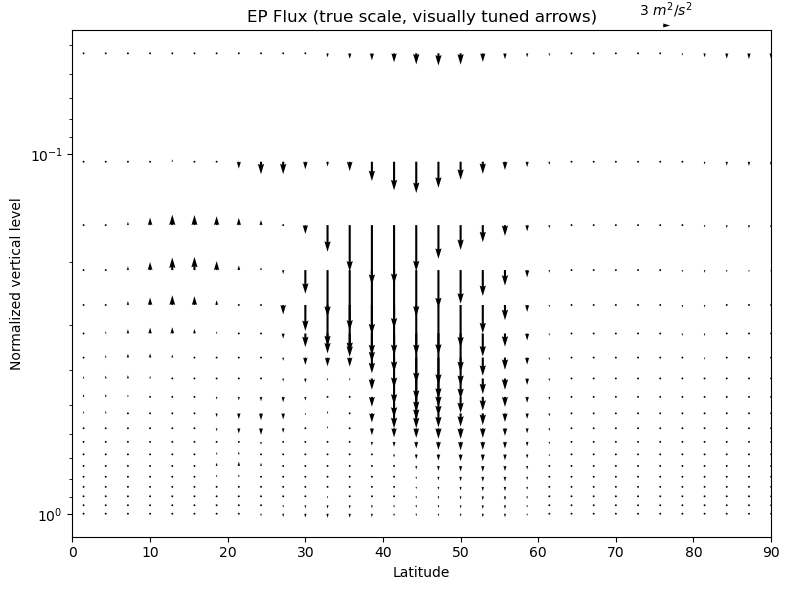

In [115]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt((Fj_pr50 - Fj_pr0)**2 + (Fk_pr50 - Fk_pr0)**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 100 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)
      
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_pr50 - Fj_pr0[::, ::], -(Fk_pr50 - Fk_pr0)[::, ::],
    color="black", width=3e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

ax.set_yscale("log")
plt.gca().invert_yaxis()
ax.set_xlim([0, 90])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


In [613]:
Fj_pr0.shape

(20, 64)

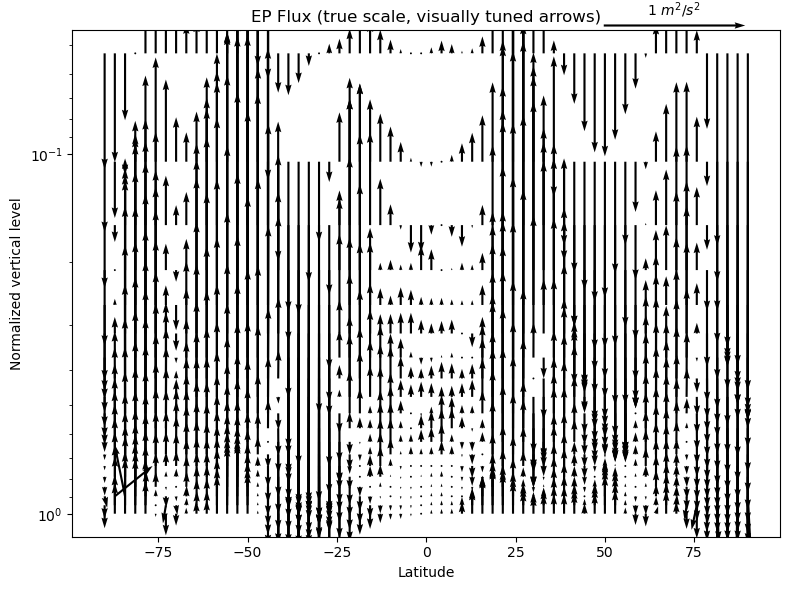

In [119]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt((Fj_pr0[::, ::]**2 + (Fk_pr0[::, ::])**2))
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 5 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)
      
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj_pr0[::, ::], (Fk_pr0)[::, ::],
    color="black", width=3e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

ax.set_yscale("log")
plt.gca().invert_yaxis()
# ax.set_xlim([0, 90])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


In [524]:
Fj_pr0.shape[-2]

20

In [291]:
lat_sel

array([ 1.42857143,  4.28571429,  7.14285714, 10.        , 12.85714286,
       15.71428571, 18.57142857, 21.42857143, 24.28571429, 27.14285714,
       30.        , 32.85714286, 35.71428571, 38.57142857, 41.42857143,
       44.28571429, 47.14285714, 50.        , 52.85714286, 55.71428571,
       58.57142857, 61.42857143, 64.28571429, 67.14285714, 70.        ,
       72.85714286, 75.71428571, 78.57142857])

In [7]:
import sys
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py

# 加入 Jucker 函數庫
# sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
# import aostools_functions as ac
import importlib

sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac
importlib.reload(ac)  # ← 強制重新載入

# === 設定 ===
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
lat = np.linspace(-90, 90, 64)
pres = np.array([10,50,70,100,150,200,250,300,400,500,700,850,1000])

lat_sel = lat[(lat >= 0) & (lat <= 80)]

# === Loop over PR ===
for pr in range(0, 60, 10):
    print(f"Drawing for PR={pr}...")

    # 載入資料EPflux_alltime_PR
    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        print(f.keys())
        # lat = f["latitude"][:]
        Fj = f["f1"][:]  # (time, level, lat)
        Fk = f["f2"][:]
        lev = f["level"][:]  # 儲存在 HDF5 裡的 pressure level

    print(level.shape)
    # 轉成 xarray
    Fj_xr = xr.DataArray(Fj.mean(axis=0), dims=["level", "latitude"],
                         coords={"level": lev, "latitude": lat})
    Fk_xr = xr.DataArray(Fk.mean(axis=0), dims=["level", "latitude"],
                         coords={"level": lev, "latitude": lat})

    # 畫圖
    fig, ax = plt.subplots()
    set_size(5.2, 5.2, ax)

    Fphi_dx, Fp_dy = ac.PlotEPfluxArrows(
        Fj_xr.sel(latitude=lat_sel, level=lev, method='nearest').latitude,
        Fk_xr.sel(level=lev, method='nearest').level,
        Fj_xr.sel(latitude=lat_sel, level=lev, method='nearest'),
        -Fk_xr.sel(latitude=lat_sel, level=lev, method='nearest'),
        fig, ax,
        xlim=[0, 80], ylim=[1000, 50], yscale='log'
    )

    ax.get_children()[1].set_facecolor('r')
    ax.set_title(f"Baldwin et al 1985 — PR={pr}")
    ax.set_xlabel("latitude")
    ax.set_ylabel("pressure [hPa]")
    ax.yaxis.set_major_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    # 如果要儲存：
    # plt.savefig(f"EPflux_PR{pr}.png", dpi=300)
    plt.show()


Drawing for PR=0...
<KeysViewHDF5 ['f1', 'f2', 'latitude', 'level', 'time']>


NameError: name 'level' is not defined

In [301]:
Fphi_dx.shape

(28, 20)

In [304]:
zz.shape

(20, 64)

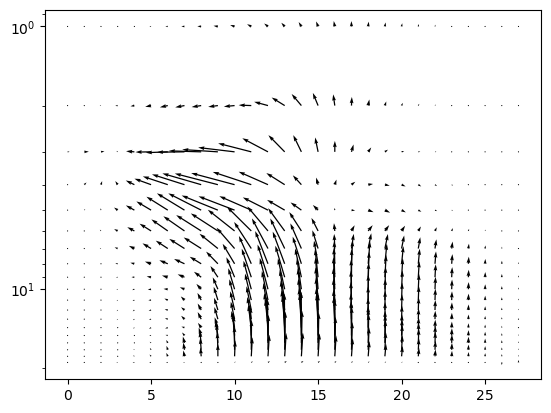

In [323]:
y_new = np.linspace(80,0,28)
z_new = np.linspace(10,1000,20)
yy_new, zz_new = np.meshgrid(y_new, z_new)
quivArgs = {'angles':'uv','scale_units':'inches','pivot':pivot}


fig, ax = plt.subplots()
plt.quiver(Fphi_dx.T, Fp_dy.T, **quivArgs)
ax.set_yscale("log")
plt.gca().invert_yaxis()

In [406]:
# import sys
# import os
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt
# import h5py

# # 加入 Jucker 函數庫
# # sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
# # import aostools_functions as ac
# import importlib

# # sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
# import aostools_functions as ac
# importlib.reload(ac)  # ← 強制重新載入

# # === 設定 ===
# save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
# lat = np.linspace(-90, 90, 64)
# pres = np.array([10,50,70,100,150,200,250,300,400,500,700,850,1000])

# lat_sel = lat[(lat >= 0) & (lat <= 80)]

# y_new = np.linspace(80,0,28)
# z_new = np.linspace(10,1000,20)
# yy_new, zz_new = np.meshgrid(y_new, z_new)




# # === Loop over PR ===
# for pr in range(0, 10, 10):
#     print(f"Drawing for PR={pr}...")

#     # 載入資料
#     with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
#         print(f.keys())
#         # lat = f["latitude"][:]
#         Fj = f["f1"][:]  # (time, level, lat)
#         Fk = f["f2"][:]
#         lev = f["level"][:]  # 儲存在 HDF5 裡的 pressure level

#     print(Fj.shape)
#     # 轉成 xarray
#     Fj_xr = xr.DataArray(Fj.mean(axis=0), dims=["level", "latitude"],
#                          coords={"level": lev, "latitude": lat})
#     Fk_xr = xr.DataArray(Fk.mean(axis=0), dims=["level", "latitude"],
#                          coords={"level": lev, "latitude": lat})

#     # 畫圖
#     fig, ax = plt.subplots()
#     set_size(5.2, 5.2, ax)

#     Fphi_dx, Fp_dy, Fphi, Fp, dx, dy = ac.PlotEPfluxArrows(
#         Fj_xr.sel(latitude=lat_sel, level=lev, method='nearest').latitude,
#         Fk_xr.sel(level=lev, method='nearest').level,
#         Fj_xr.sel(latitude=lat_sel, level=lev, method='nearest'),
#         -Fk_xr.sel(latitude=lat_sel, level=lev, method='nearest'),
#         fig, ax,
#         xlim=[0, 80], ylim=[1000, 50], yscale='log'
#     )
    

#     ax.get_children()[1].set_facecolor('r')
#     ax.set_title(f"Baldwin et al 1985 — PR={pr}")
#     ax.set_xlabel("latitude")
#     ax.set_ylabel("pressure [hPa]")
#     ax.yaxis.set_major_formatter(plt.ScalarFormatter())

#     plt.tight_layout()
#     # 如果要儲存：
#     # plt.savefig(f"EPflux_PR{pr}.png", dpi=300)
#     plt.show()

#     fig, ax = plt.subplots()
#     set_size(5.2, 5.2, ax)
    
#     ax.quiver(Fphi.T*dx, Fp.T*dy, **quivArgs)
#     # ax.set_yscale("log")
#     plt.gca().invert_yaxis()


In [412]:
time_idx_array_positive[0]

array([  391,   392,   393, ..., 77217, 77218, 77219])

Drawing for PR=0...
(78000, 20, 64)


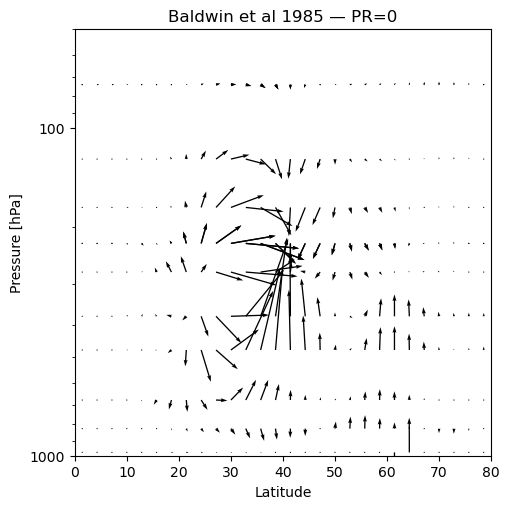

-2450.014112308276 1601.8940105593222


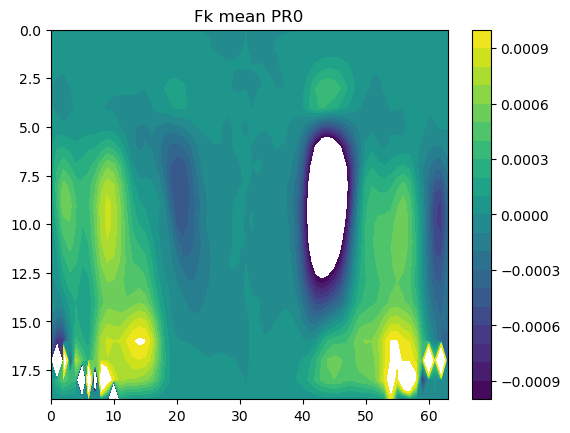

Drawing for PR=10...
(78000, 20, 64)


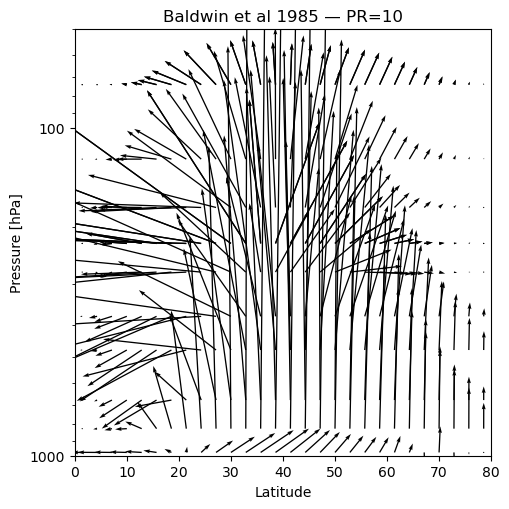

-123.74540698575937 567.2103348854022


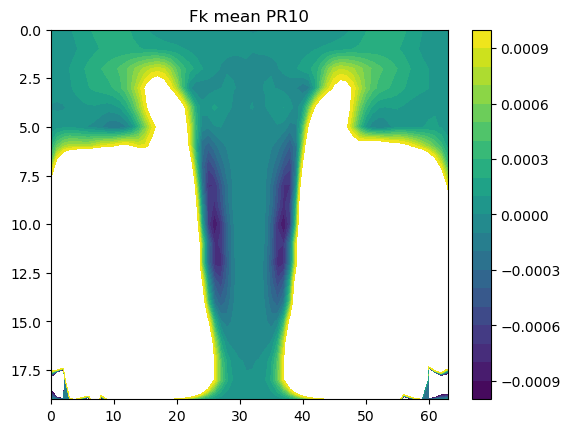

Drawing for PR=20...
(78000, 20, 64)


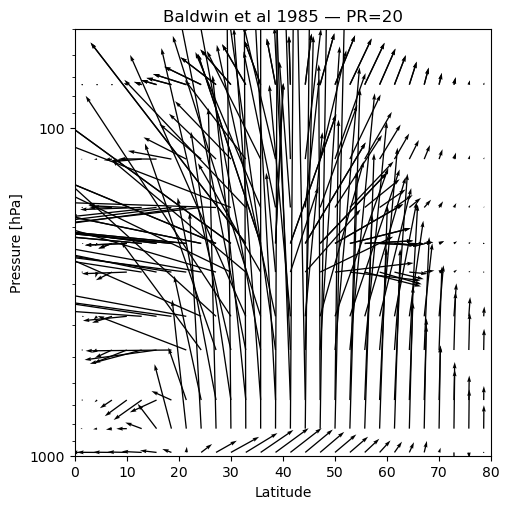

-142.54582148530685 160.52845782296959


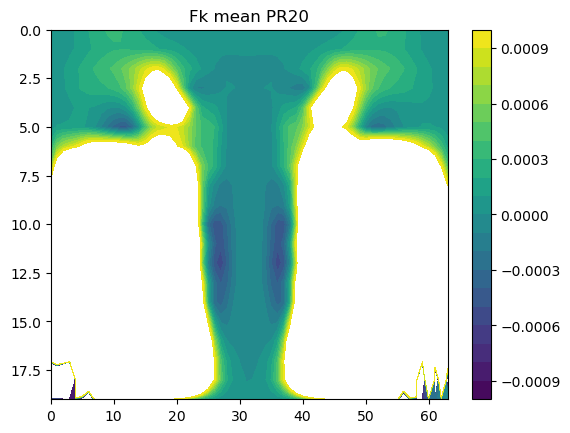

Drawing for PR=30...
(78000, 20, 64)


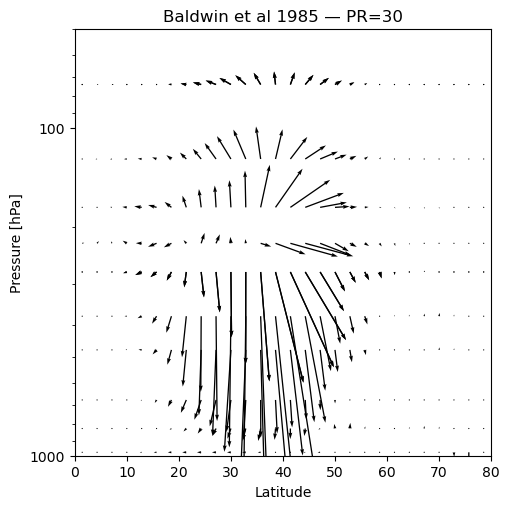

-64.79817555006746 90.17256026647202


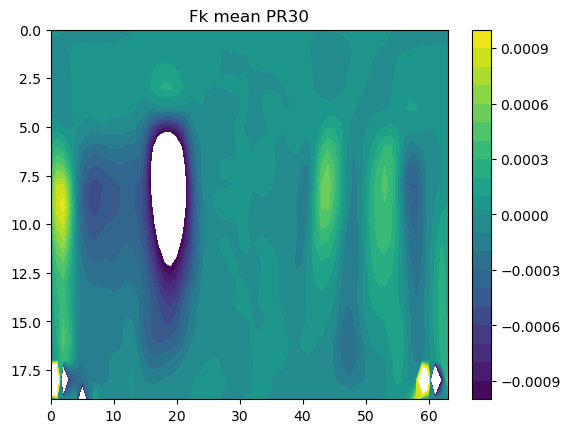

Drawing for PR=40...
(78000, 20, 64)


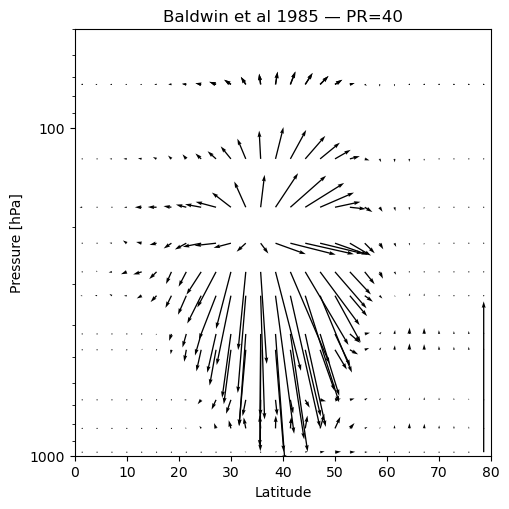

-34.88158526955403 26.054275402489903


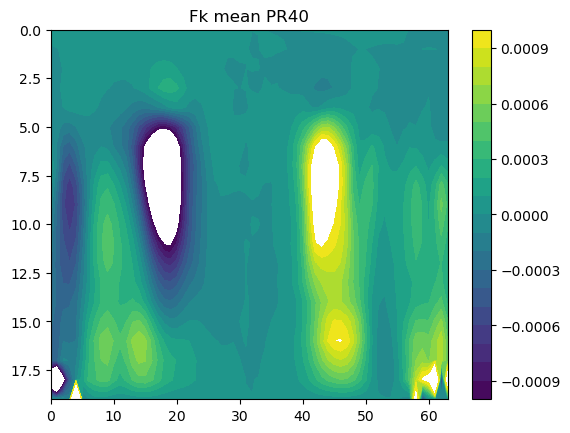

Drawing for PR=50...
(78000, 20, 64)


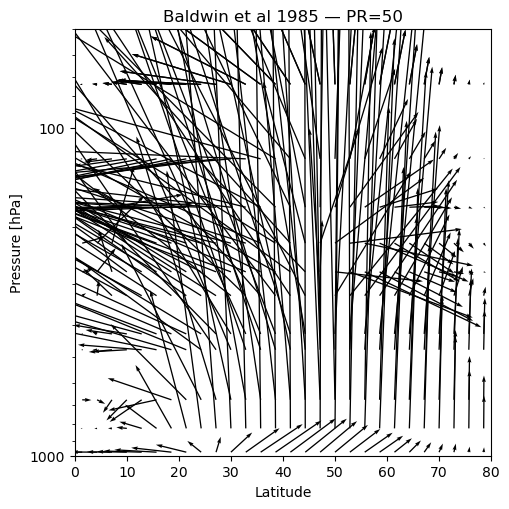

-13.694703158161456 55.61761095975079


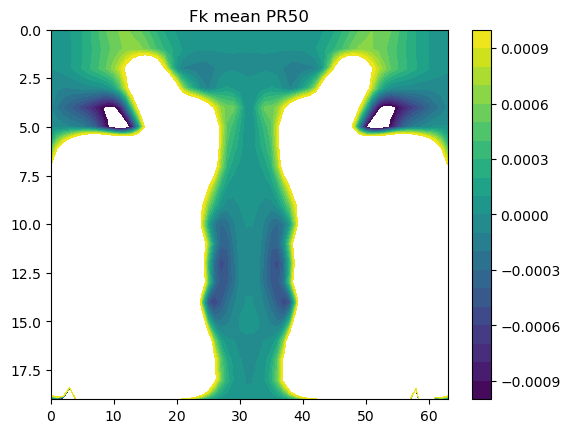

In [413]:
import sys, os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py

sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

def set_size(w, h, ax):
    ax.figure.set_size_inches(w, h)

save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
lat = np.linspace(90, -90, 64)  # 北到南！

pres = np.array([10,50,70,100,150,200,250,300,400,500,700,850,1000])
lat_sel = lat[(lat <= 80) & (lat >= 0)]  # 正確選取北半球

for pr in range(0, 60, 10):
    print(f"Drawing for PR={pr}...")

    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        Fj = f["f1"][:]
        Fk = f["f2"][:]
        level = f["level"][:]
    print(Fj.shape)
    Fj_xr = xr.DataArray(Fj[time_idx_array_positive[0]].mean(axis=0), dims=["level", "latitude"],
                         coords={"level": level, "latitude": lat})
    Fk_xr = xr.DataArray(Fk[time_idx_array_positive[0]].mean(axis=0), dims=["level", "latitude"],
                         coords={"level": level, "latitude": lat})

    Fj_sub = Fj_xr.sel(latitude=lat_sel, level=pres, method='nearest')
    Fk_sub = Fk_xr.sel(latitude=lat_sel, level=pres, method='nearest')

    fig, ax = plt.subplots()
    set_size(5.2, 5.2, ax)

    ac.PlotEPfluxArrows(
        Fj_sub.latitude,
        Fj_sub.level,
        -Fj_sub.transpose("level", "latitude"),
        -Fk_sub.transpose("level", "latitude"),  # 視情況移除 -
        fig, ax,
        xlim=[0, 80], ylim=[1000, 50], yscale='log',
        scale=5e14  # 調整這個大小
    )

    ax.set_title(f"Baldwin et al 1985 — PR={pr}")
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Pressure [hPa]")
    ax.yaxis.set_major_formatter(plt.ScalarFormatter())
    plt.tight_layout()
    plt.show()

    import matplotlib.pyplot as plt
    print(np.nanmin(Fk), np.nanmax(Fk))

    plt.figure()
    plt.contourf(Fk.mean(axis=0), levels=np.linspace(-0.001,0.001,21))  # shape: (level, lat)
    plt.title(f"Fk mean PR{pr}")
    plt.colorbar()
    plt.ylim([19,0])
    plt.show()



[ 18.402777  73.61111  124.21874  174.48558  224.64326  274.752
 324.8345   374.90137  424.9581   475.00797  525.0528   575.0941
 625.1325   675.16876  725.20337  775.2367   825.2686   875.29987
 925.3304   975.3597  ]
Drawing for PR=0...
(78000, 20, 64)


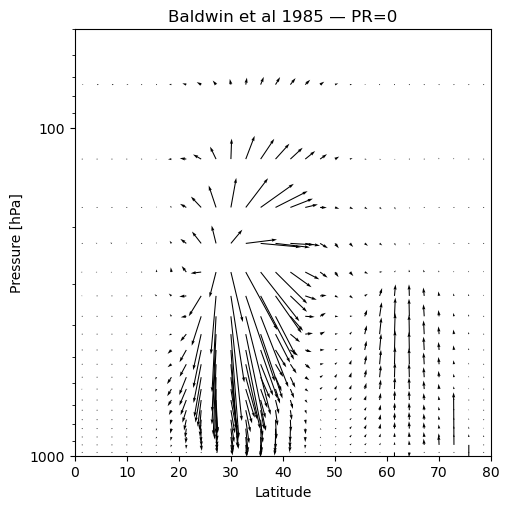

-2450.014112308276 1601.8940105593222


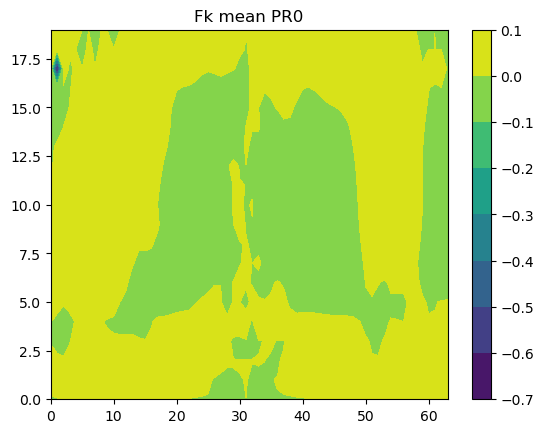

Drawing for PR=10...
(78000, 20, 64)


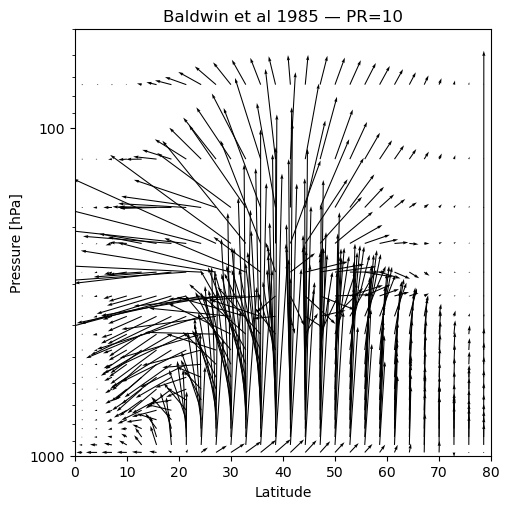

-123.74540698575937 567.2103348854022


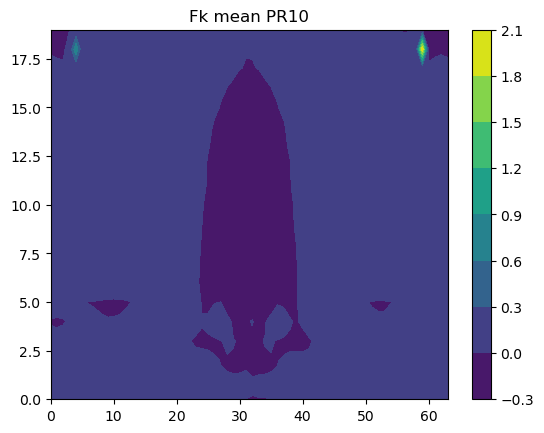

Drawing for PR=20...
(78000, 20, 64)


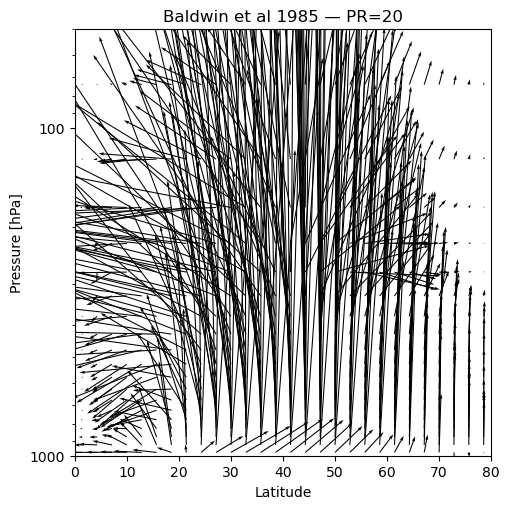

-142.54582148530685 160.52845782296959


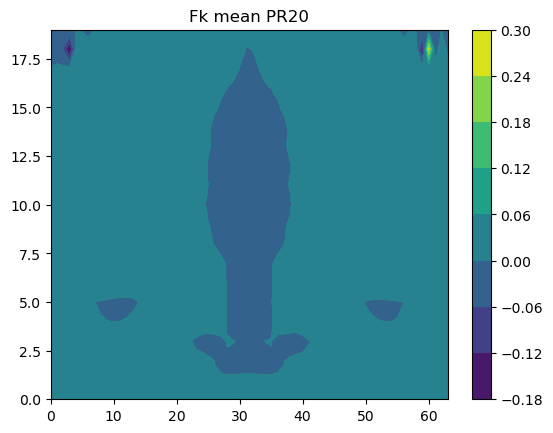

Drawing for PR=30...
(78000, 20, 64)


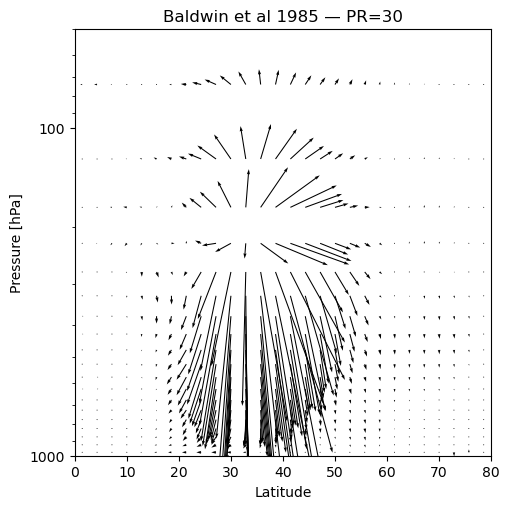

-64.79817555006746 90.17256026647202


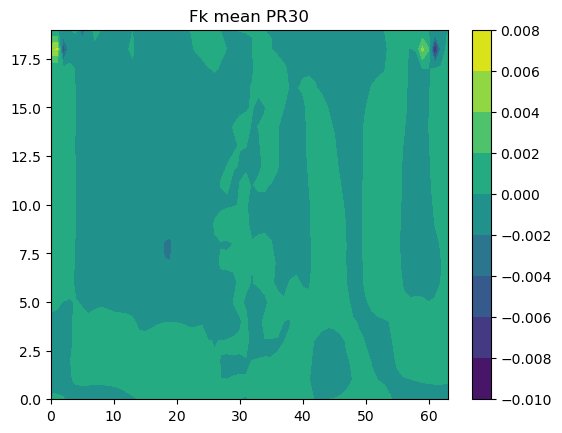

Drawing for PR=40...
(78000, 20, 64)


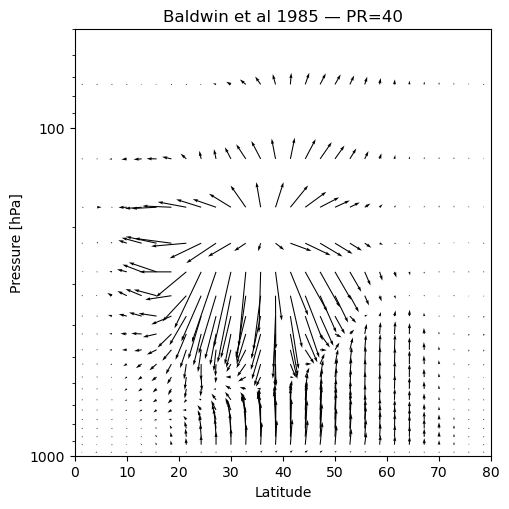

-34.88158526955403 26.054275402489903


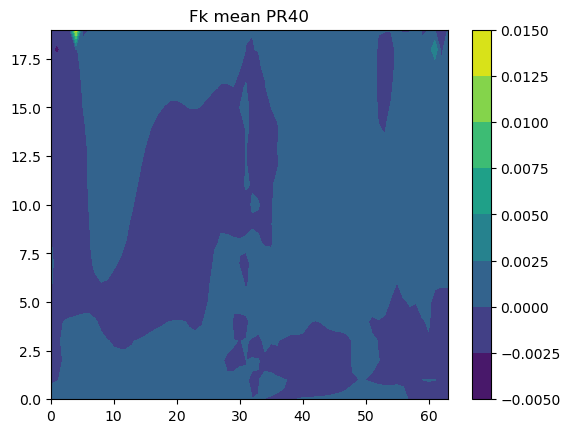

Drawing for PR=50...
(78000, 20, 64)


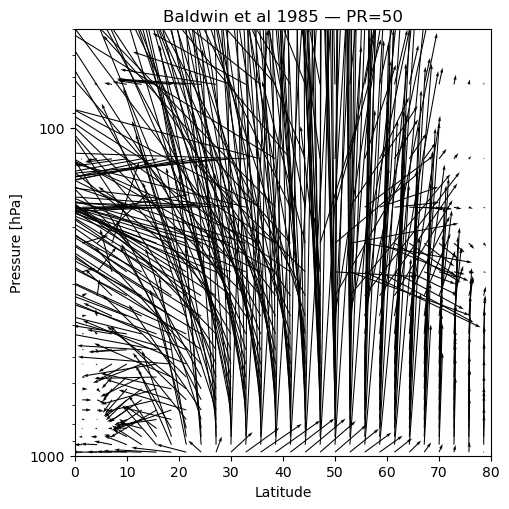

-13.694703158161456 55.61761095975079


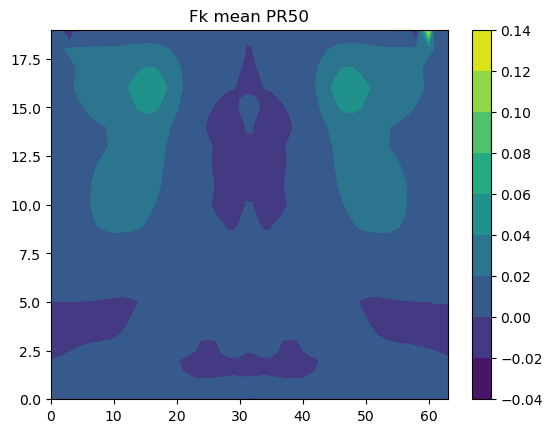

In [369]:
import sys, os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py

# 加入 Jucker 函數庫
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

def set_size(w, h, ax):
    ax.figure.set_size_inches(w, h)

save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
lat = np.linspace(90, -90, 64)  # 北到南！
# pres = np.array([10,50,70,100,150,200,250,300,400,500,700,850,1000])
pres = level  # ← HDF5 裡面的完整 20 層
print(pres)

lat_sel = lat[(lat <= 80) & (lat >= 0)]

for pr in range(0, 60, 10):
    print(f"Drawing for PR={pr}...")

    with h5py.File(os.path.join(save_dir, f"ep_flux_PR{pr}.h5"), "r") as f:
        Fj = f["f1"][:]
        Fk = f["f2"][:]
        level = f["level"][:]
    print(Fj.shape)
    Fj_xr = xr.DataArray(Fj[50000:70000].mean(axis=0), dims=["level", "latitude"],
                         coords={"level": level, "latitude": lat})
    Fk_xr = xr.DataArray(Fk[50000:70000].mean(axis=0), dims=["level", "latitude"],
                         coords={"level": level, "latitude": lat})

    Fj_sub = Fj_xr.sel(latitude=lat_sel, level=pres, method='nearest')
    Fk_sub = Fk_xr.sel(latitude=lat_sel, level=pres, method='nearest')

    fig, ax = plt.subplots()
    set_size(5.2, 5.2, ax)

    # 製作 meshgrid，讓 x/y 和向量大小 shape 一致
    X, Y = np.meshgrid(Fj_sub.latitude.values, Fj_sub.level.values)

    ac.PlotEPfluxArrows(
        x=X,
        y=Y,
        ep1=-Fj_sub.transpose("level", "latitude").values,
        ep2=-Fk_sub.transpose("level", "latitude").values,
        fig=fig,
        ax=ax,
        xlim=[0, 80], ylim=[1000, 50], yscale='log',
        scale=5e14
    )

    ax.set_title(f"Baldwin et al 1985 — PR={pr}")
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Pressure [hPa]")
    ax.yaxis.set_major_formatter(plt.ScalarFormatter())
    plt.tight_layout()
    plt.show()

    # 顯示垂直通量場的樣子方便 debug
    print(np.nanmin(Fk), np.nanmax(Fk))
    plt.figure()
    plt.contourf(Fk.mean(axis=0))  # shape: (level, lat)
    plt.title(f"Fk mean PR{pr}")
    plt.colorbar()
    plt.show()


In [18]:
PR = 0

Fj = np.load(f"EPflux_alltime_PR{PR}.npz")["Fj"][:]
Fk = np.load(f"EPflux_alltime_PR{PR}.npz")["Fk"][:]

# with h5py.File(os.path.join(save_dir, f"ep_flux_PR{PR}.h5"), "r") as f:
#     Fj = f["Fj"][:]
#     Fk = f["Fk"][:]
    
# time_idx_array_positive = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_positive_PR_{PR}.npy")
# time_idx_array_negative = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/time_idx_results/time_idx_negative_PR_{PR}.npy")


In [4]:
Fk.shape

(20, 64)

In [550]:
# # lag = 4.
# # time_idx_pos_test = time_idx_pos_test[:] + lag
# # time_idx_pos_test = time_idx_pos_test[time_idx_pos_test < 78000]
# Fj_test = Fj[:].mean(axis=0)
# Fk_test = Fk[:].mean(axis=0)


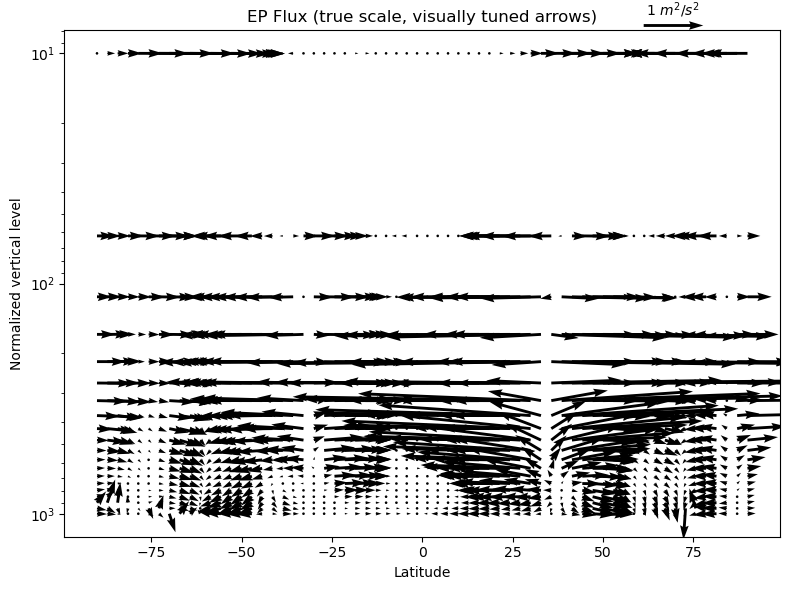

In [26]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt(Fj**2 + Fk**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 12 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(10,1000,20)
yy, zz = np.meshgrid(y, z_nor)

fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    Fj[::, ::], Fk[::, ::],
    color="black", width=4e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

# ax.set_ylim([1, 0])
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


In [552]:
p.shape

(78000, 20, 64, 128)

Drawing for PR=0...
-2.9043276 2.9948785 -0.004633924
-0.37040865 0.27395186 -0.0042904634


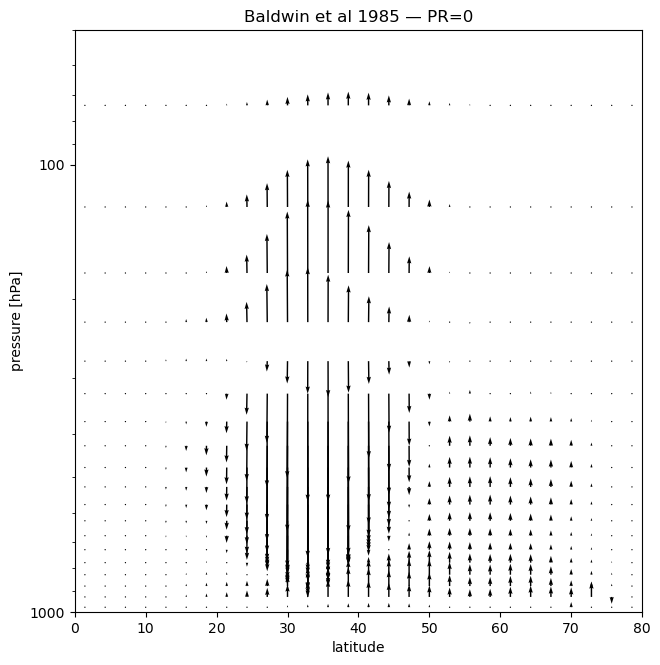

Drawing for PR=10...
-2.9043276 2.9948785 -0.004633924
-0.37040865 0.27395186 -0.0042904634


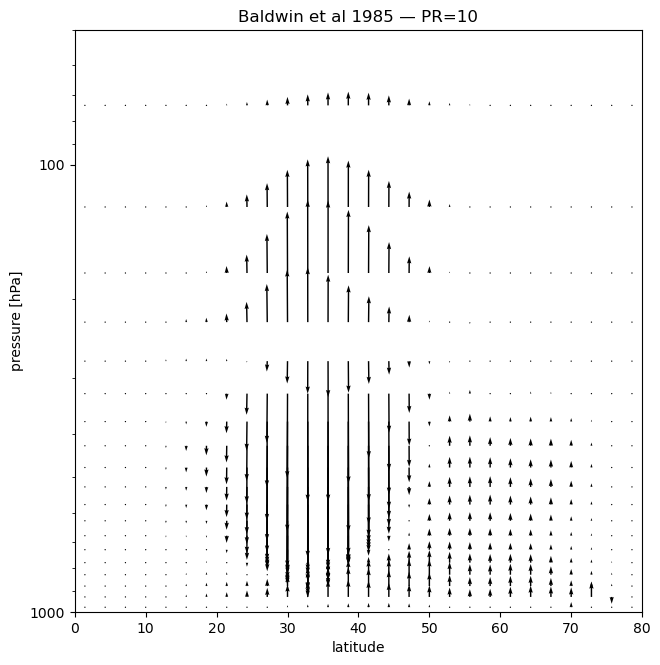

Drawing for PR=20...
-2.9043276 2.9948785 -0.004633924
-0.37040865 0.27395186 -0.0042904634


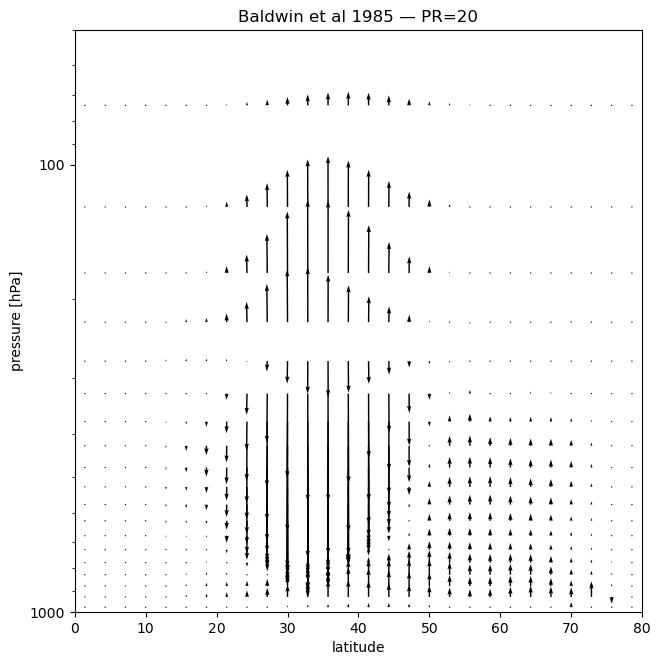

Drawing for PR=30...
-2.9043276 2.9948785 -0.004633924
-0.37040865 0.27395186 -0.0042904634


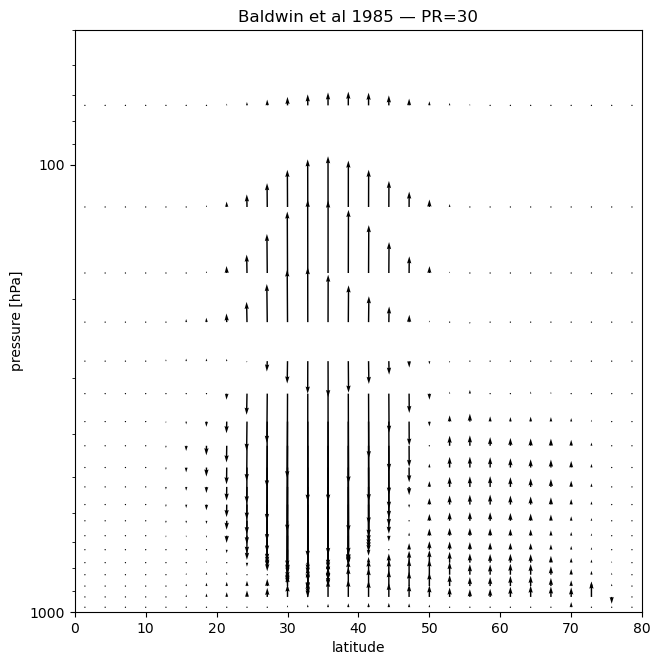

Drawing for PR=40...
-2.9043276 2.9948785 -0.004633924
-0.37040865 0.27395186 -0.0042904634


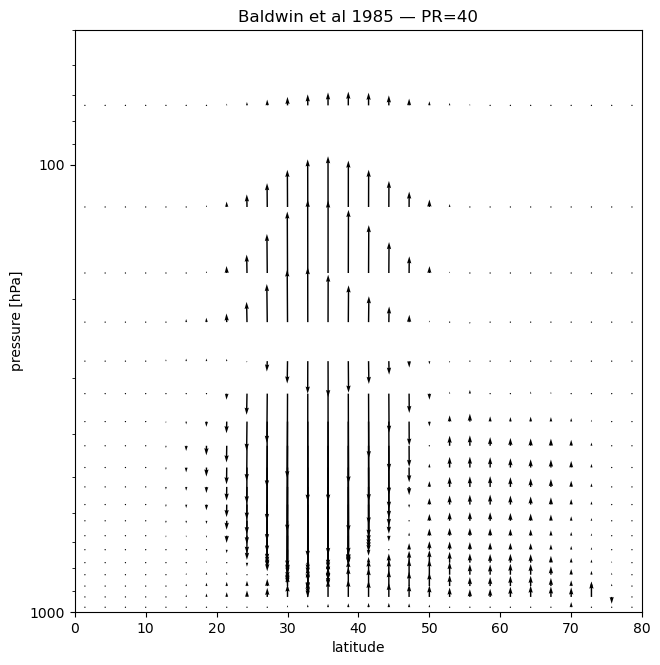

Drawing for PR=50...
-2.9043276 2.9948785 -0.004633924
-0.37040865 0.27395186 -0.0042904634


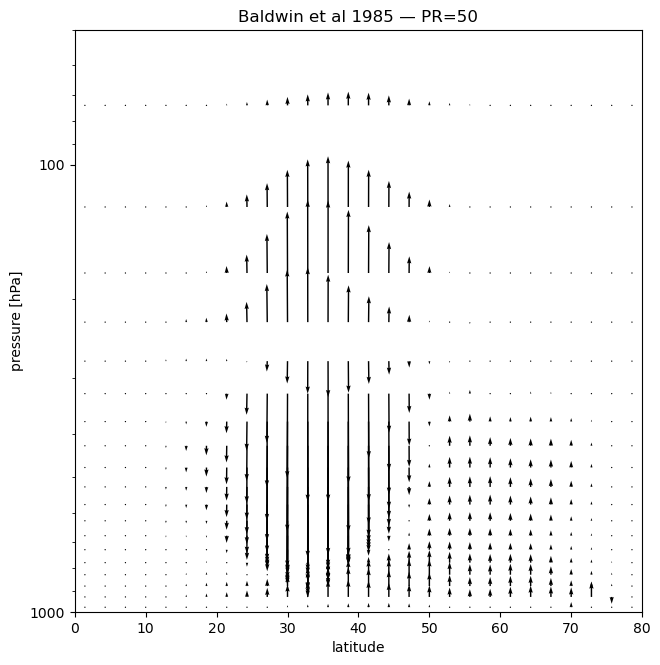

In [23]:
import sys
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py

# 加入 Jucker 函數庫
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac

# === 設定 ===
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/epflux_result_Jucker/"
lat = np.linspace(-90, 90, 64)
pres = p.mean(axis=(0,2,3)) / 100

lat_sel = lat[(lat >= 0) & (lat <= 80)]

# === Loop over PR ===
for pr in range(0, 60, 10):
    print(f"Drawing for PR={pr}...")

    # 載入資料

    # Fj = np.load(f"EP_flux_PR{PR}.npz")["Fj"][:]    

    Fj = np.load(f"EP_flux_mean_PR{PR}.npz")["Fj"][:]
    Fk = np.load(f"EP_flux_mean_PR{PR}.npz")["Fk"][:]
    # level = f["level"][:]  # 儲存在 HDF5 裡的 pressure level
    print(Fj.min(), Fj.max(), Fj.mean())
    print(Fk.min(), Fk.max(), Fk.mean())
    

    # 轉成 xarray
    Fj_xr = xr.DataArray(Fj, dims=["level", "latitude"],
                         coords={"level": pres, "latitude": lat})
    Fk_xr = xr.DataArray(Fk, dims=["level", "latitude"],
                         coords={"level": pres, "latitude": lat})

    # 畫圖
    fig, ax = plt.subplots()
    set_size(5.2, 5.2, ax)

    _, _ = ac.PlotEPfluxArrows(
        Fj_xr.sel(latitude=lat_sel, level=pres, method='nearest').latitude,
        Fk_xr.sel(level=pres, method='nearest').level,
        Fj_xr.sel(latitude=lat_sel, level=pres, method='nearest'),
        Fk_xr.sel(latitude=lat_sel, level=pres, method='nearest'),
        fig, ax,
        xlim=[0, 80], ylim=[1000, 50], yscale='log'
    )

    ax.get_children()[1].set_facecolor('r')
    ax.set_title(f"Baldwin et al 1985 — PR={pr}")
    ax.set_xlabel("latitude")
    ax.set_ylabel("pressure [hPa]")
    ax.yaxis.set_major_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    # 如果要儲存：
    # plt.savefig(f"EPflux_PR{pr}.png", dpi=300)
    plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
PR = 0
Fj_pos = np.load(f"EPflux_positive_lag15_25_PR{PR}.npz")["Fj"][:]
Fk_pos = np.load(f"EPflux_positive_lag15_25_PR{PR}.npz")["Fk"][:]

Fj_neg = np.load(f"EPflux_negative_lag15_25_PR{PR}.npz")["Fj"][:]
Fk_neg = np.load(f"EPflux_negative_lag15_25_PR{PR}.npz")["Fk"][:]


Text(0.5, 1.0, 'Fk')

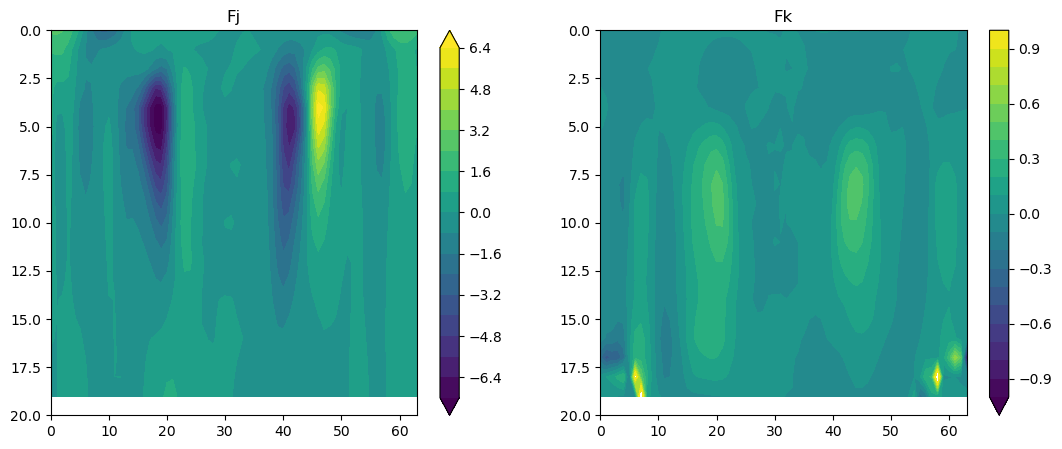

In [19]:
fig, (ax1,ax2) = plt.subplots(1,2, dpi=100, figsize=(13,5))
cs1 = ax1.contourf((Fj_pos-Fj_neg), levels=21, extend="both")
plt.colorbar(cs1)
ax1.set_ylim([20,0])
ax1.set_title(r"Fj")


# from scipy.ndimage import gaussian_filter
# sigma = 1  # Standard deviation for the Gaussian kernel
# Fk_mean_filtered = gaussian_filter(Fk_mean, sigma=sigma)
cs2 = ax2.contourf((Fk_pos - Fk_neg), levels=np.linspace(-1,1,21), extend="min")
plt.colorbar(cs2)
ax2.set_ylim([20,0])
ax2.set_title(r"Fk")



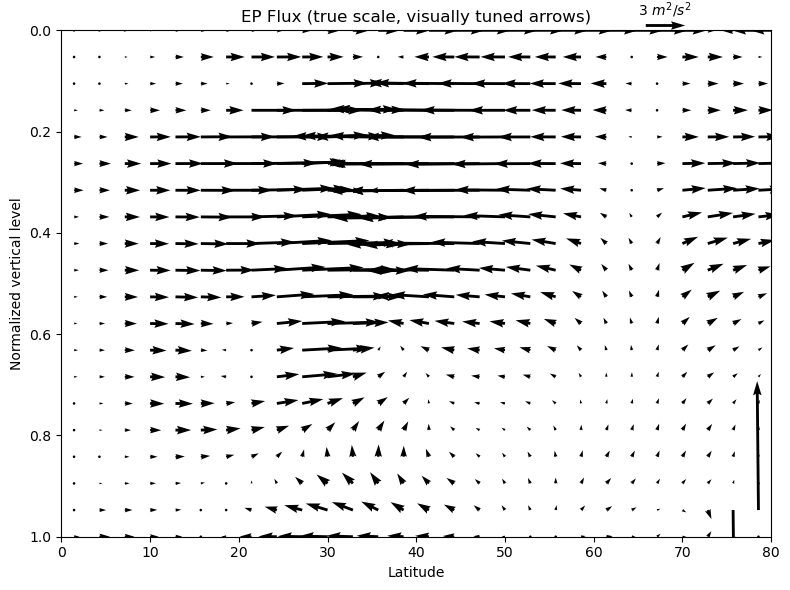

In [20]:
# 1. 根據 EP flux 的 magnitude 決定箭頭代表的單位
magnitude = np.sqrt((test_j-(Fj_pos-Fj_neg))**2 + (test_k - (Fk_pos-Fk_neg))**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)  # 第90百分位箭頭作為參考箭頭

# 2. quiver scale 控制「箭頭畫多長」
quiver_scale = 18 * ref_arrow_size  # 調這個會改箭頭長度（越大箭越短）

# 3. Plot
y = np.linspace(-90,90,64)
z_nor = np.linspace(0,1,20)
yy, zz = np.meshgrid(y, z_nor)

fig, ax = plt.subplots(1, figsize=(8, 6), dpi=100)
wind_plt = ax.quiver(
    yy[::, ::], zz[::, ::],
    (test_j-(Fj_pos-Fj_neg))[::, ::], (test_k - (Fk_pos-Fk_neg))[::, ::],
    color="black", width=4e-3, scale=quiver_scale
)

# 4. Quiver key，只是圖例，不改數值
ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.0f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

# ax.set_ylim([1, 0])
plt.xlim([0,80])
plt.ylim([1,0])

# plt.gca().invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
plt.title("EP Flux (true scale, visually tuned arrows)")
plt.tight_layout()
plt.show()


In [17]:
test_j = (Fj_pos-Fj_neg)
test_k = (Fk_pos-Fk_neg)


In [227]:
dy

<xarray.DataArray 'level' (level: 20)>
array([-0.07107058, -0.01776764, -0.01052896, -0.00749572, -0.0058221 ,
       -0.00476028, -0.00402635, -0.00348864, -0.0030777 , -0.00275342,
       -0.00249098, -0.00227423, -0.00209219, -0.00193714, -0.00180349,
       -0.00168709, -0.00158481, -0.00149423, -0.00141344, -0.00134093])
Coordinates:
  * level    (level) float32 18.43 73.71 124.4 174.7 ... 826.4 876.5 926.6 976.7

In [226]:
Fk_PR0.shape

(20, 64)

In [232]:
test = np.zeros(Fk_PR0.shape)
for i in range(64):
    test[:,i] = Fk_PR0[:,i] * dy

In [265]:
def PlotEPfluxArrows_outside(x,y,ep1,ep2,fig,ax,xlim=None,ylim=None,xscale='linear',yscale='linear',invert_y=True, newax=False, pivot='tail',scale=None):
	"""Correctly scales the Eliassen-Palm flux vectors for plotting on a latitude-pressure or latitude-height axis.
		x,y,ep1,ep2 assumed to be xarray.DataArrays.

	INPUTS:
		x       : horizontal coordinate, assumed in degrees (latitude) [degrees]
		y       : vertical coordinate, any units, but usually this is pressure or height
		ep1     : horizontal Eliassen-Palm flux component, in [m2/s2]. Typically, this is ep1_cart from
		           ComputeEPfluxDiv()
		ep2     : vertical Eliassen-Palm flux component, in [U.m/s2], where U is the unit of y.
			       Typically, this is ep2_cart from ComputeEPfluxDiv(), in [hPa.m/s2] and y is pressure [hPa].
		fig     : a matplotlib figure object. This figure contains the axes ax.
		ax      : a matplotlib axes object. This is where the arrows will be plotted onto.
		xlim    : axes limits in x-direction. If None, use [min(x),max(x)]. [None]
		ylim    : axes limits in y-direction. If None, use [min(y),max(y)]. [None]
		xscale  : x-axis scaling. currently only 'linear' is supported. ['linear']
		yscale  : y-axis scaling. 'linear' or 'log' ['linear']
		invert_y: invert y-axis (for pressure coordinates). [True]
		newax   : plot on second y-axis. [False]
		pivot   : keyword argument for quiver() ['tail']
		scale   : keyword argument for quiver() [None]

	OUTPUTS:
	   Fphi*dx : x-component of properly scaled arrows. Units of [m3.inches]
	   Fp*dy   : y-component of properly scaled arrows. Units of [m3.inches]
	   ax   : secondary y-axis if newax == True
	"""
	import numpy as np
	import matplotlib.pyplot as plt
	#
	def Deltas(z,zlim):
		if zlim is None:
			return np.max(z)-np.min(z)
		else:
			return zlim[1]-zlim[0]
	# Scale EP vector components as in Edmon, Hoskins & McIntyre JAS 1980:
	cosphi = np.cos(np.deg2rad(x))
	a0 = 6376000.0 # Earth radius [m]
	grav = 9.81
	# first scaling: Edmon et al (1980), Eqs. 3.1 & 3.13
	Fphi = 2*np.pi/grav*cosphi**2*a0**2*ep1 # [m3.rad]
	Fp   = 2*np.pi/grav*cosphi**2*a0**3*ep2 # [m3.hPa]
	#
	# Now comes what Edmon et al call "distances occupied by 1 radian of
	#  latitude and 1 [hecto]pascal of pressure on the diagram."
	# These distances depend on figure aspect ratio and axis scale
	#
	# first, get the axis width and height for
	#  correct aspect ratio
	width,height = GetAxSize(fig,ax)
	# we use min(),max(), but note that if the actual axis limits
	#  are different, this will be slightly wrong.
	delta_x = Deltas(x,xlim)
	delta_y = Deltas(y,ylim)
	#
	#scale the x-axis:
	if xscale == 'linear':
		dx = width/delta_x/np.pi*180
	else:
		raise ValueError('ONLY LINEAR X-AXIS IS SUPPORTED AT THE MOMENT')
	#scale the y-axis:
	if invert_y:
		y_sign = -1
	else:
		y_sign = 1
	if yscale == 'linear':
		dy = y_sign*height/delta_y
	elif yscale == 'log':
		dy = y_sign*height/y/np.log(np.max(y)/np.min(y))
	#
	# plot the arrows onto axis
	quivArgs = {'angles':'uv','scale_units':'inches','pivot':pivot}
	if scale is not None:
		quivArgs['scale'] = scale
	if newax:
		ax = ax.twinx()
		ax.set_ylabel('pressure [hPa]')
	try:
		ax.quiver(x,y,Fphi*dx,Fp*dy,**quivArgs)
	except:
		ax.quiver(x,y,Fphi.transpose()*dx,Fp.transpose()*dy,**quivArgs)
	if invert_y:
		ax.invert_yaxis()
	if xlim is not None:
		ax.set_xlim(xlim)
	if ylim is not None:
		ax.set_ylim(ylim)
	ax.set_yscale(yscale)
	ax.set_xscale(xscale)
	#
	if newax:
		return Fphi*dx,Fp*dy,ax
	else:
		return Fphi*dx,Fp*dy, #dx, dy, delta_x, delta_y, Fphi, Fp

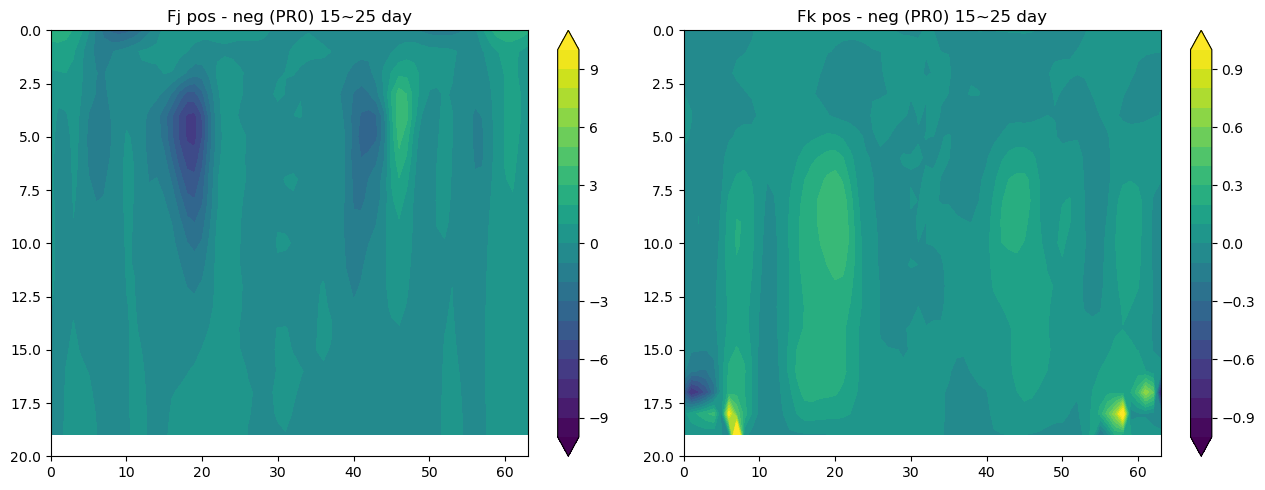

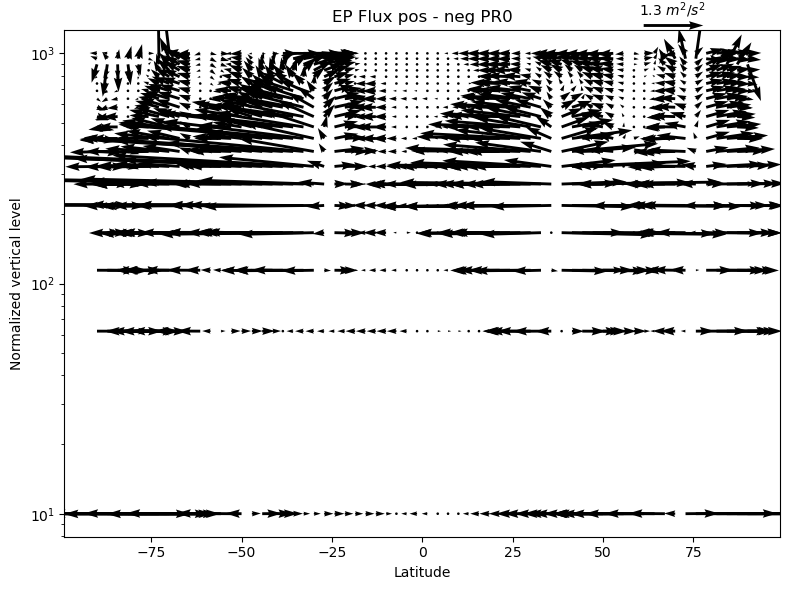

===== exp difference =====
Fj pos min and max: -17.44832 16.741796
Fk pos min and max: -9.327721 5.3974447


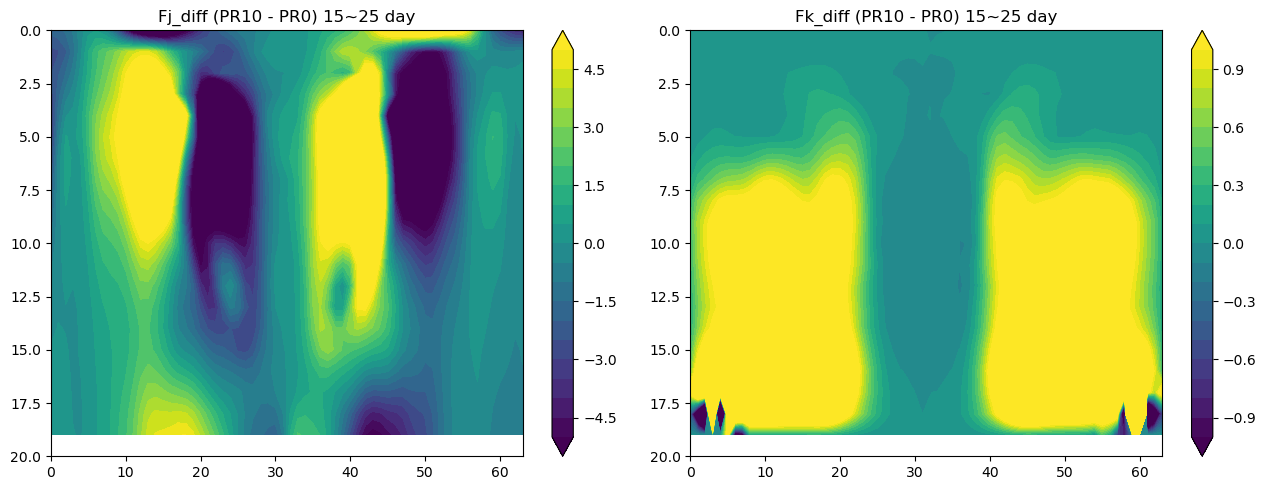

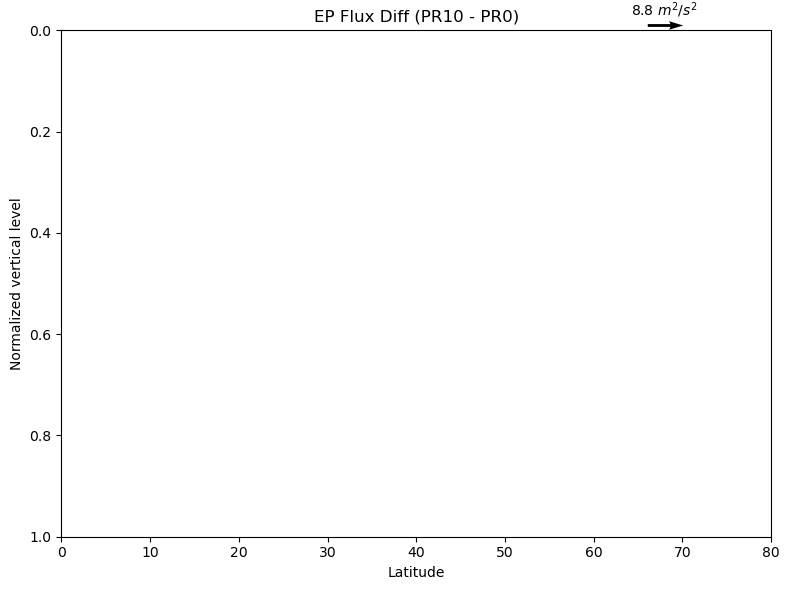

Fj pos min and max: -39.848305 34.232452
Fk pos min and max: -19.782885 20.486563


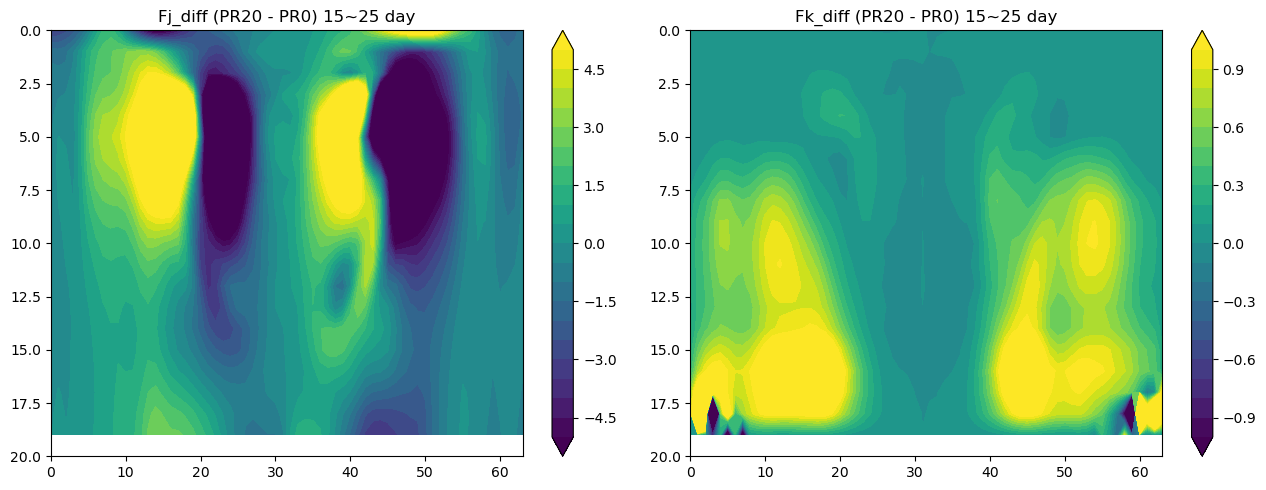

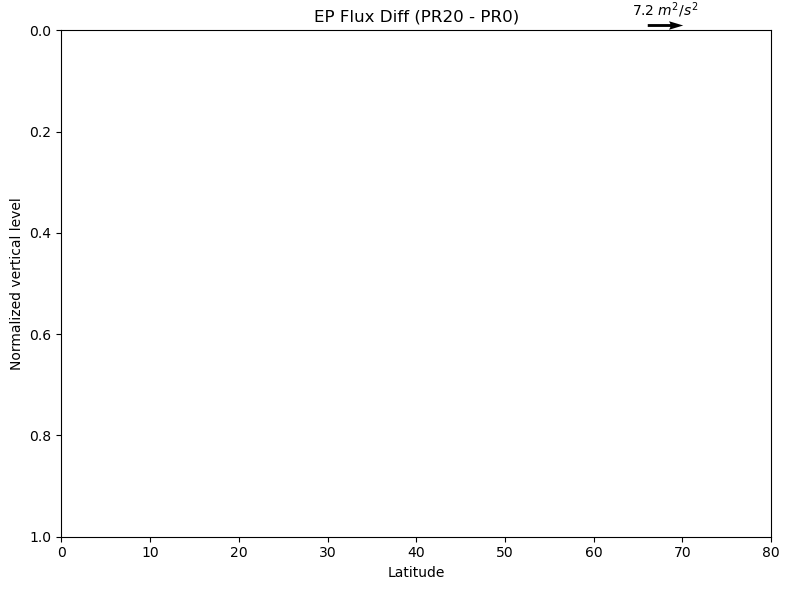

Fj pos min and max: -3.7201385 3.825983
Fk pos min and max: -0.28725976 0.89866775


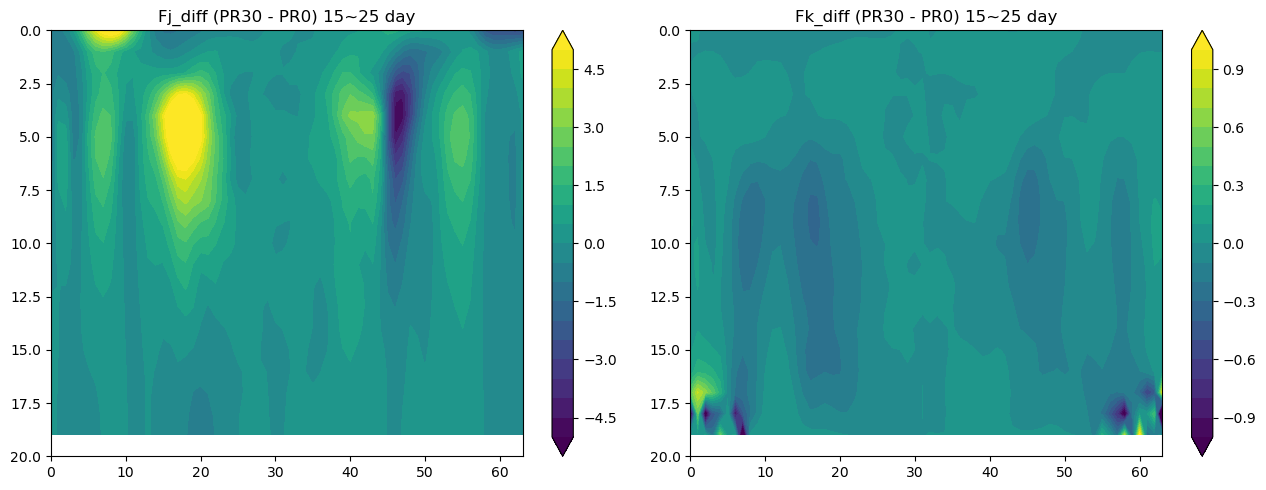

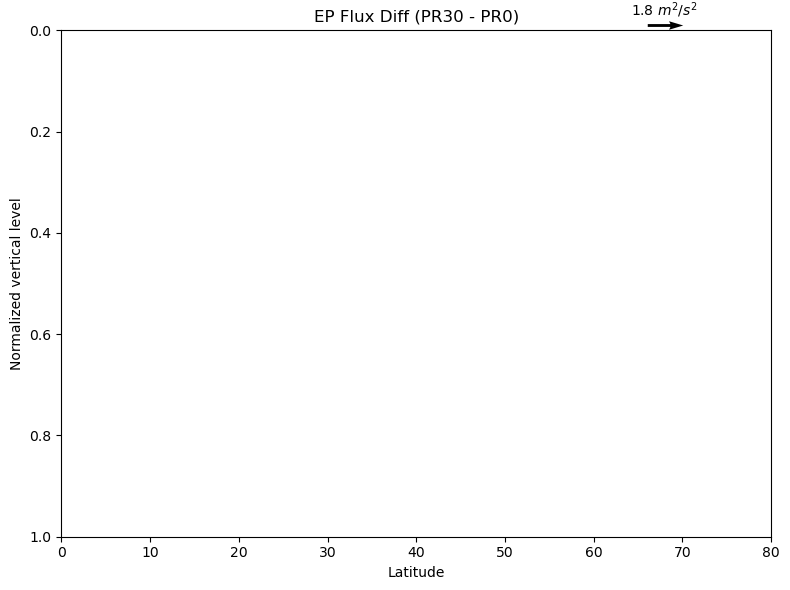

Fj pos min and max: -2.6493282 2.9550848
Fk pos min and max: -4.3472695 0.28078756


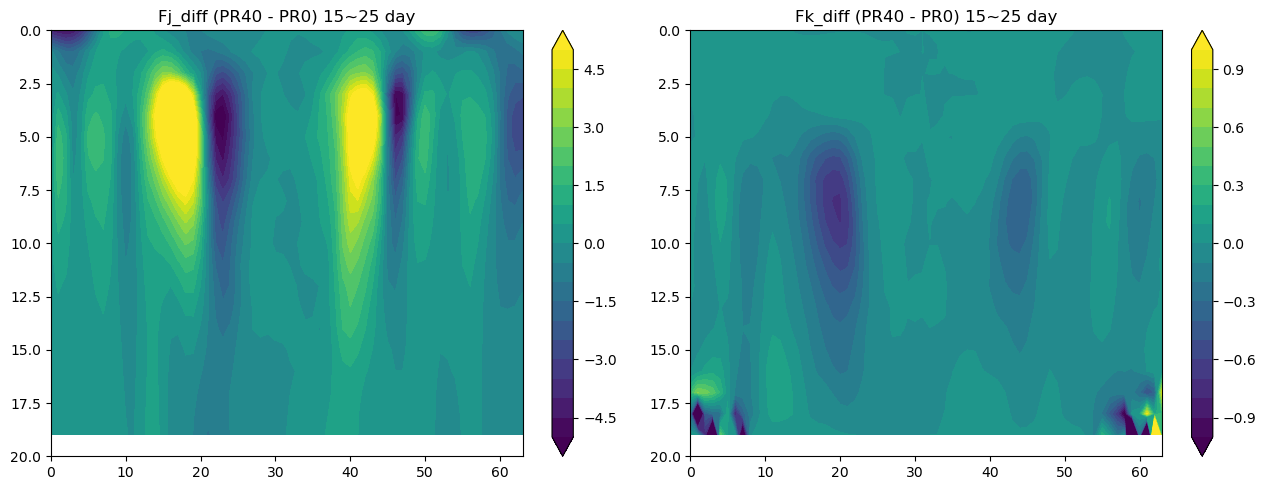

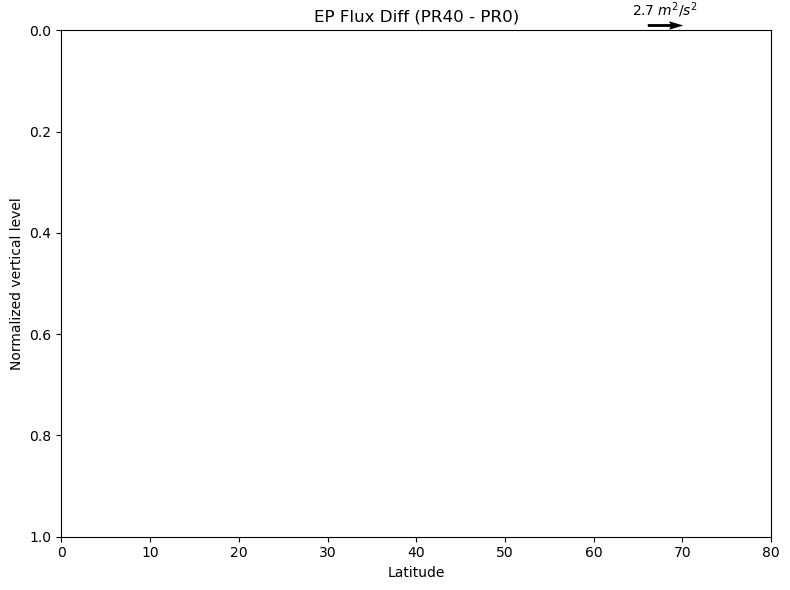

Fj pos min and max: -82.43361 85.72406
Fk pos min and max: -5.282256 1.0950242


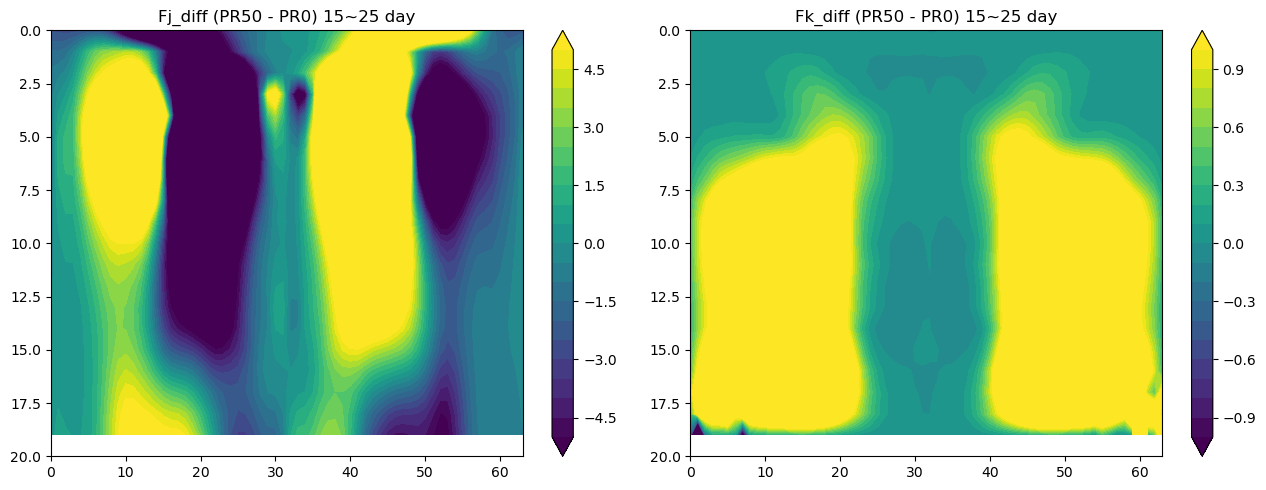

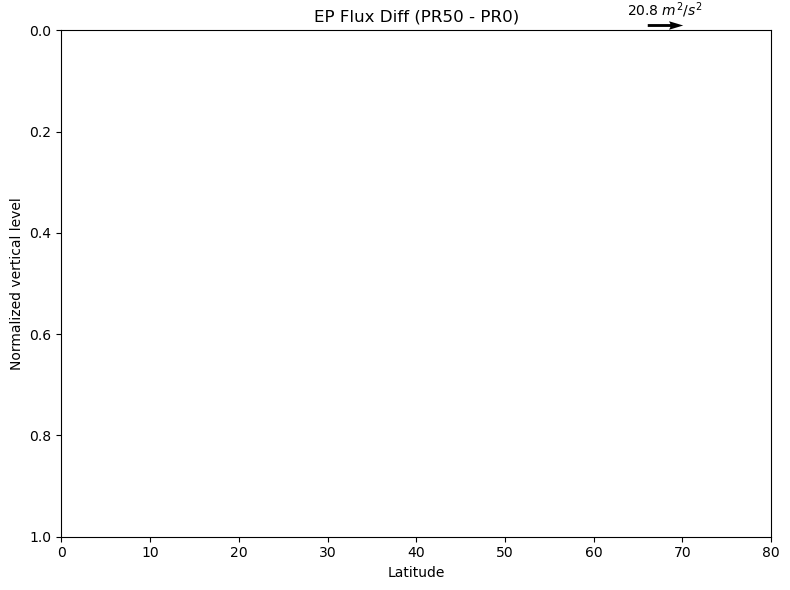

In [14]:
import numpy as np
import matplotlib.pyplot as plt

lat = np.linspace(-90, 90, 64)
# z_nor = np.linspace(0, 1, 20)
z_nor = np.linspace(10, 1000, 20)

yy, zz = np.meshgrid(lat, z_nor)

# 載入 PR=0 參考場
Fj_ref_pos = np.load("EPflux_positive_lag15_25_PR0.npz")["Fj"]
Fj_ref_neg = np.load("EPflux_negative_lag15_25_PR0.npz")["Fj"]
Fj_ref_all = np.load("EPflux_alltime_PR0.npz")["Fj"]

Fk_ref_pos = np.load("EPflux_positive_lag15_25_PR0.npz")["Fk"]
Fk_ref_neg = np.load("EPflux_negative_lag15_25_PR0.npz")["Fk"]
Fk_ref_all = np.load("EPflux_alltime_PR0.npz")["Fk"]

# plot PR0 EP flux 
Fj_PR0 = (Fj_ref_pos - Fj_ref_neg) - Fj_ref_all
Fk_PR0 = (Fk_ref_pos - Fk_ref_neg) - Fk_ref_all

# Fj_PR0_far = (Fj_ref_pos_far - Fj_ref_neg_far)
# Fk_PR0_far = (Fk_ref_pos_far - Fk_ref_neg_far)

# ========== 1. contour 圖 ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
cs1 = ax1.contourf(Fj_PR0, levels=np.linspace(-10,10,21), extend="both")
plt.colorbar(cs1, ax=ax1)
ax1.set_ylim([20, 0])
ax1.set_title(f"Fj pos - neg (PR0) 15~25 day")

cs2 = ax2.contourf(Fk_PR0, levels=np.linspace(-1, 1, 21), extend="both")
plt.colorbar(cs2, ax=ax2)
ax2.set_ylim([20, 0])
ax2.set_title(f"Fk pos - neg (PR0) 15~25 day")

plt.tight_layout()
plt.show()

# ========== 2. Quiver 向量圖 ==========
magnitude = np.sqrt((Fj_PR0)**2 + (Fk_PR0)**2)
ref_arrow_size = np.nanpercentile(magnitude, 90)
quiver_scale = 12 * ref_arrow_size

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_yscale("log")

wind_plt = ax.quiver(
    yy, zz,
    (Fj_PR0), (Fk_PR0),
    color="black", width=4e-3, scale=quiver_scale
)
# PlotEPfluxArrows_outside(yy,zz,
#                         (Fj_ref_all), (Fk_ref_all),
#                         fig, ax, yscale="log")

ax.quiverkey(
    wind_plt, X=0.85, Y=1.01,
    U=ref_arrow_size,
    label=f"{ref_arrow_size:.1f} $m^2/s^2$",
    labelpos='N', labelsep=0.05, color='black'
)

# ax.set_xlim([0, 80])
# ax.invert_yaxis() 
# ax.set_ylim([1, 0.15])
ax.set_xlabel("Latitude")
ax.set_ylabel("Normalized vertical level")
ax.set_title(f"EP Flux pos - neg PR0")
plt.tight_layout()
plt.show()

# 你想比較的 PR list
PR_list = [10, 20, 30, 40, 50]
# PR_list = [10,]

print("===== exp difference =====")
for PR in PR_list:
    Fj_test_pos = np.load(f"EPflux_positive_lag15_25_PR{PR}.npz")["Fj"]
    Fj_test_neg = np.load(f"EPflux_negative_lag15_25_PR{PR}.npz")["Fj"]
    Fj_test_all = np.load(f"EPflux_alltime_PR{PR}.npz")["Fj"]
    # Fj_test_neg_far = np.load(f"EPflux_negative_lag90_100_PR{PR}.npz")["Fj"]
    print("Fj pos min and max:", Fj_test_pos.min(), Fj_test_pos.max())

    Fk_test_pos = np.load(f"EPflux_positive_lag15_25_PR{PR}.npz")["Fk"]
    Fk_test_neg = np.load(f"EPflux_negative_lag15_25_PR{PR}.npz")["Fk"]
    Fk_test_all = np.load(f"EPflux_alltime_PR{PR}.npz")["Fk"]
    print("Fk pos min and max:", Fk_test_pos.min(), Fk_test_pos.max())
    
    # 計算差值場
    dFj = (Fj_test_pos - Fj_test_neg) - Fj_test_all - Fj_PR0 #- ((Fj_test_pos_far - Fj_test_neg_far) - (Fj_ref_pos_far - Fj_ref_neg_far))
    dFk = (Fk_test_pos - Fk_test_neg) - Fk_test_all - Fk_PR0 #- ((Fk_test_pos_far - Fk_test_neg_far) - (Fk_ref_pos_far - Fk_ref_neg_far))

    # dFj_far = ((Fj_test_pos_far - Fj_test_neg_far) - (Fj_ref_pos_far - Fj_ref_neg_far))
    # dFk_far = ((Fk_test_pos_far - Fk_test_neg_far) - (Fk_ref_pos_far - Fk_ref_neg_far))    
    # ========== 1. contour 圖 ==========
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
    cs1 = ax1.contourf(dFj, levels=np.linspace(-5,5,21), extend="both")
    plt.colorbar(cs1, ax=ax1)
    ax1.set_ylim([20, 0])
    ax1.set_title(f"Fj_diff (PR{PR} - PR0) 15~25 day")

    cs2 = ax2.contourf(dFk, levels=np.linspace(-1, 1, 21), extend="both")
    plt.colorbar(cs2, ax=ax2)
    ax2.set_ylim([20, 0])
    ax2.set_title(f"Fk_diff (PR{PR} - PR0) 15~25 day")

    plt.tight_layout()
    plt.show()

    # ========== 3. Quiver 向量圖 ==========
    magnitude = np.sqrt(dFj**2 + dFk**2)
    ref_arrow_size = np.nanpercentile(magnitude, 90)
    quiver_scale = 20 * ref_arrow_size

    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    EOF1_PRs = np.load(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PC1_results/EOF1_PR_{PR}.npy")
    ax.contourf(yy[:,32:], zz[:,32:], -EOF1_PRs, cmap='coolwarm')
    
    wind_plt = ax.quiver(
        yy, zz,
        dFj, dFk,
        color="black", width=4e-3, scale=quiver_scale
    )

    ax.quiverkey(
        wind_plt, X=0.85, Y=1.01,
        U=ref_arrow_size,
        label=f"{ref_arrow_size:.1f} $m^2/s^2$",
        labelpos='N', labelsep=0.05, color='black'
    )

    ax.set_xlim([0, 80])
    ax.set_ylim([1, 0])
    ax.set_xlabel("Latitude")
    ax.set_ylabel("Normalized vertical level")
    ax.set_title(f"EP Flux Diff (PR{PR} - PR0)")
    plt.tight_layout()
    plt.show()


In [28]:
def set_size(w,h, ax=None):
	""" w, h: width, height in inches """
	if not ax: ax=plt.gca()
	l = ax.figure.subplotpars.left
	r = ax.figure.subplotpars.right
	t = ax.figure.subplotpars.top
	b = ax.figure.subplotpars.bottom
	figw = float(w)/(r-l)
	figh = float(h)/(t-b)
	ax.figure.set_size_inches(figw, figh)

In [ ]:
array([   1,    2,    3,    5,    7,   10,   20,   30,   50,   70,  100,  125,
        150,  175,  200,  225,  250,  300,  350,  400,  450,  500,  550,  600,
        650,  700,  750,  775,  800,  825,  850,  875,  900,  925,  950,  975,
       1000], dtype=int32)

In [159]:
level

array([ 18.428064,  73.71226 , 124.389114, 174.76202 , 225.07178 ,
       275.16132 , 325.25848 , 375.61874 , 425.43405 , 475.8721  ,
       525.82214 , 575.92175 , 626.0489  , 676.0595  , 726.5415  ,
       776.6981  , 826.4571  , 876.28015 , 926.67236 , 977.1867  ],
      dtype=float32)

In [160]:
Fj_xr

<xarray.DataArray (level: 20, latitude: 64)>
array([[ 2.5255718 ,  2.4751937 ,  2.311039  , ...,  2.7557483 ,
         2.5574307 ,  2.2502112 ],
       [ 1.4754416 ,  1.6266983 ,  1.5805962 , ...,  1.2482477 ,
         0.9114368 ,  0.52169144],
       [ 0.90833324,  0.93560445,  0.9965471 , ...,  1.1742327 ,
         0.8759222 ,  0.47325596],
       ...,
       [-0.12143365, -0.10414738,  0.01933907, ...,  0.3358497 ,
         0.32238927,  0.30256107],
       [-0.14912856, -0.11394069,  0.03441248, ...,  0.34074053,
         0.3304295 ,  0.3060788 ],
       [-0.165296  , -0.11818364,  0.04427578, ...,  0.3497597 ,
         0.33878565,  0.31103507]], dtype=float32)
Coordinates:
  * level     (level) float32 18.43 73.71 124.4 174.8 ... 876.3 926.7 977.2
  * latitude  (latitude) float64 -90.0 -87.14 -84.29 -81.43 ... 84.29 87.14 90.0

In [171]:
Fj_xr.sel(latitude=lat,method='nearest').level
np.log(np.max(level) / np.min(level))

3.970803

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import sys
import importlib

# Import Jucker (2020) tools
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux_Jucker2020/")
import aostools_functions as ac
importlib.reload(ac)  # 若你有改動 ac 檔案

# === 資料維度與坐標 ===
# level = np.array([10, 50, 70, 100, 150, 200, 225, 250, 300, 350, 400,
                  # 500, 550, 600, 650, 700, 800, 825, 900, 1000])
lev = p.mean(axis=(0,2,3)) / 100 # np.linspace(10,1000,20)
lat = np.linspace(-90,90, 64)  # 根據 dFj 橫向維度決定

Fj_xr = xr.DataArray(Fj_PR0[:,:], dims=["level", "latitude"], coords={"level": lev, "latitude": lat})
Fk_xr = xr.DataArray(Fk_PR0[:,:]/100, dims=["level", "latitude"], coords={"level": lev, "latitude": lat})

# 準備 2D grid
X, Y = np.meshgrid(lat, lev)  # shape (lev, lat)

fig, ax = plt.subplots()
set_size(5.2, 5.2, ax)

# 插值後的新 level 和 latitude
# target_levs = np.array([10,   20,   30,   50,   70,  100,  125,
#         150,  175,  200,  225,  250,  300,  350,  400,  450,  500,  550,  600,
#         650,  700,  750,  775,  800,  825,  850,  875,  900,  925,  950,  975,
#        1000])

lat = Fj_xr.latitude.values

# Fj_interp = Fj_xr.interp(level=target_levs)
# Fk_interp = Fk_xr.interp(level=target_levs)

# 重新建立 X, Y 座標，與插值後 shape 一致
# X, Y = np.meshgrid(lat, target_levs)  # shape: (13, 64)


F_phi, F_p = ac.PlotEPfluxArrows(
    x=X,
    y=Y,
    ep1=Fj_ref_all,
    ep2=-Fk_ref_all/100,
    fig=fig,
    ax=ax,
    xlim=[0, 80], ylim=[1000, 50], yscale='log',
    scale=12e14
)

ax.set_title(f"EP Flux Difference — PR={pr}")
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure [hPa]")
ax.yaxis.set_major_formatter(plt.ScalarFormatter())
plt.tight_layout()
plt.show()



NameError: name 'p' is not defined

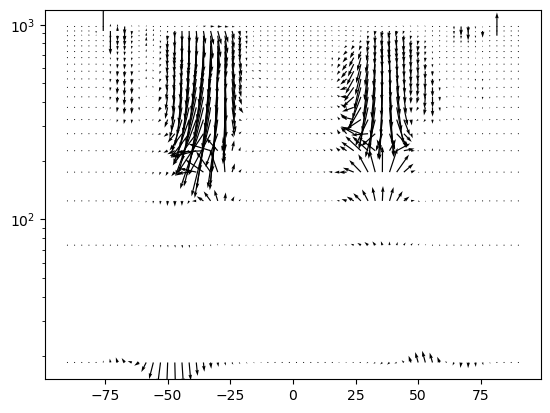

In [218]:
fig, ax = plt.subplots()
plt.quiver(X,Y, F_phi, F_p)
ax.set_yscale('log')


In [123]:
print(Fj_PR0.min(), Fj_PR0.max())
print(Fk_PR0.min(), Fk_PR0.max())


-6.336636 3.8458707
-84.9976 2.1532786


In [89]:
grav  = 9.81
cosphi = np.cos(np.deg2rad(lat))
a0 = 6371E3

Fphi = 2*np.pi/grav*cosphi**2*a0**2*dFj
Fp   = 2*np.pi/grav*cosphi**2*a0**3*dFk
print("Fphi range", np.nanmin(Fphi), np.nanmax(Fphi))
print("Fp range", np.nanmin(Fp), np.nanmax(Fp))
# print("dx, dy", dx, dy)
# print("Fphi*dx range", np.nanmin(Fphi*dx), np.nanmax(Fphi*dx))


Fphi range -468381229153037.8 499493141469614.4
Fp range -6.10238154540475e+19 3.58105989848506e+20


In [87]:
print("dFj range", np.nanmin(dFj), np.nanmax(dFj))
print("dFk range", np.nanmin(dFk), np.nanmax(dFk))

dFj range -22.137743 23.65887
dFk range -9.384139 85.73934


In [49]:
dFj.min(), dFj.max(), dFj.mean()

(-22.137743, 23.65887, 0.3376303)

In [50]:
dFk.min(), dFk.max(), dFk.mean()


(-9.384139, 85.73934, 0.8380555)